<a href="https://colab.research.google.com/github/jnvs-py/Importaciones_Bogota/blob/main/Proyecto_Importaciones_Bogota.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Optimización del Portafolio de Importaciones de Bogotá
## Modelo basado en datos para la toma de decisiones organizacionales

**Presentado por:** Johan Nicolás Valderrama Serrato, Mariana Prada Riaño, Paola Andrea Castro
**Asignatura:** Toma de Decisiones Organizacionales  
**Dominio:** Logística y Supply Chain  
**Fuente de datos:** Portal de Datos Abiertos de Bogotá - Importaciones Bogotá  



## Instalación de librerias, dependencias

In [ ]:
%%capture
# !pip install pulp scikit-learn seaborn matplotlib pandas numpy requests scipy
# !pip install -U transformers accelerate bitsandbytes

In [ ]:
%%capture
!pip install adjustText

### Herramienta de evaluación

In [ ]:
from google.colab import ai
# response = ai.generate_text("Cual es la capital de France?")
# response

### 0. Creación de documento base para guardar hallazgos

In [ ]:
# ============================================================
# 0.2 RUTAS ROBUSTAS + HELPER PARA HALLAZGOS
# ============================================================
from pathlib import Path
import textwrap

PROYECTO_DIR = Path.cwd()
RUTA_HALLAZGOS = PROYECTO_DIR / "hallazgos.md"
RUTA_FIGURAS = PROYECTO_DIR / "figuras"
RUTA_SALIDAS = PROYECTO_DIR / "salidas"

RUTA_FIGURAS.mkdir(exist_ok=True)
RUTA_SALIDAS.mkdir(exist_ok=True)

if not RUTA_HALLAZGOS.exists():
    RUTA_HALLAZGOS.write_text("# Hallazgos del proyecto\n\n", encoding="utf-8")

# Mantener compatibilidad con tus celdas anteriores
archivo_md = str(RUTA_HALLAZGOS)

def _df_to_md(obj, max_rows=40):
    if obj is None:
        return ""
    if isinstance(obj, pd.Series):
        obj = obj.to_frame(name=obj.name or "valor").reset_index()
    if isinstance(obj, pd.DataFrame):
        tabla = obj.copy()
        if len(tabla) > max_rows:
            tabla = tabla.head(max_rows)
        return tabla.to_markdown(index=False)
    return str(obj)

def append_hallazgos(seccion, texto="", tablas=None, figuras=None, reset=False):
    """
    tablas: lista de tuplas -> [("Título tabla", dataframe), ...]
    figuras: lista de rutas o una sola ruta
    """
    if reset:
        RUTA_HALLAZGOS.write_text("# Hallazgos del proyecto\n\n", encoding="utf-8")

    tablas = tablas or []
    if figuras is None:
        figuras = []
    elif isinstance(figuras, (str, Path)):
        figuras = [figuras]

    bloques = [f"## {seccion}\n"]

    if texto:
        bloques.append(textwrap.dedent(texto).strip() + "\n")

    for titulo, tabla in tablas:
        bloques.append(f"\n### {titulo}\n\n")
        bloques.append(_df_to_md(tabla) + "\n")

    for fig in figuras:
        ruta_rel = Path(fig).as_posix()
        nombre = Path(fig).name
        if ruta_rel.lower().endswith(".html"):
            bloques.append(f"\n[Visual interactivo: {nombre}]({ruta_rel})\n")
        else:
            bloques.append(f"\n![{nombre}]({ruta_rel})\n")

    with open(RUTA_HALLAZGOS, "a", encoding="utf-8") as f:
        f.write("\n".join(bloques) + "\n")

    print(f"✅ Hallazgos actualizados en: {RUTA_HALLAZGOS}")

def guardar_figura(fig, nombre_archivo, dpi=150):
    ruta = RUTA_FIGURAS / nombre_archivo
    fig.savefig(ruta, dpi=dpi, bbox_inches="tight")
    return ruta.as_posix()

def guardar_plotly(fig, nombre_base):
    """
    Intenta PNG; si falla (ej. falta kaleido), guarda HTML.
    """
    base = Path(nombre_base).stem
    ruta_png = RUTA_FIGURAS / f"{base}.png"
    ruta_html = RUTA_FIGURAS / f"{base}.html"

    try:
        fig.write_image(ruta_png, scale=2)
        print(f"✅ Plotly exportado como PNG: {ruta_png.name}")
        return ruta_png.as_posix()
    except Exception as e:
        fig.write_html(ruta_html)
        print(f"⚠️ No se pudo exportar PNG ({e}). Se guardó HTML: {ruta_html.name}")
        return ruta_html.as_posix()

print(f"Directorio de trabajo: {PROYECTO_DIR}")
print(f"hallazgos.md: {RUTA_HALLAZGOS}")
print(f"figuras/: {RUTA_FIGURAS}")
print(f"salidas/: {RUTA_SALIDAS}")

Directorio de trabajo: /content
hallazgos.md: /content/hallazgos.md
figuras/: /content/figuras
salidas/: /content/salidas


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import os
import re
import time
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from matplotlib.ticker import ScalarFormatter
import seaborn as sns
import requests
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import pulp
from pulp import *
from itertools import product as itertools_product
import plotly.graph_objects as go
import plotly.express as px

# Dependencias opcionales
try:
    import gspread
    from google.colab import auth
    from google.auth import default
    EN_COLAB = True
except Exception:
    gspread = None
    auth = None
    default = None
    EN_COLAB = False

try:
    from IPython.display import display, Markdown
except Exception:
    display = print
    Markdown = lambda x: x

# Configuración visual
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
palette = sns.color_palette('Set2', 10)

# Reproducibilidad
np.random.seed(42)

print("Librerías cargadas correctamente.")
print(f"Entorno Colab detectado: {EN_COLAB}")

Librerías cargadas correctamente.
Entorno Colab detectado: True


## 1. Extracción y Preparación de Datos

### 1.1 Extracción desde API de Datos Abiertos Bogotá

In [ ]:
RESOURCE_ID = "f0e1c08e-4638-42dd-adc6-80b538f76c89"
BASE_URL = "https://datosabiertos.bogota.gov.co/api/3/action/datastore_search"
CACHE_FILE = Path("cache_datos_bogota.parquet")

def descargar_api(resource_id: str, base_url: str, limit: int = 1000) -> pd.DataFrame:
    offset = 0
    rows = []

    print("Descargando datos desde API de Datos Abiertos Bogotá...")
    while True:
        params = {
            "resource_id": resource_id,
            "limit": limit,
            "offset": offset
        }
        r = requests.get(base_url, params=params, timeout=160)
        r.raise_for_status()

        data = r.json()["result"]
        records = data["records"]

        if not records:
            break

        rows.extend(records)
        offset += limit

        if offset >= data["total"]:
            break

    df = pd.DataFrame(rows)
    print(f"\nDescarga completada: {df.shape[0]:,} registros x {df.shape[1]} columnas")
    print(f"Total reportado por la API: {data['total']:,}")
    return df


def cargar_datos(use_cache: bool = True, force_refresh: bool = False) -> pd.DataFrame:
    if use_cache and CACHE_FILE.exists() and not force_refresh:
        print(f"Cargando datos desde cache local: {CACHE_FILE}")
        return pd.read_parquet(CACHE_FILE)

    df = descargar_api(RESOURCE_ID, BASE_URL)
    df.to_parquet(CACHE_FILE, index=False)
    print(f"Cache guardado en: {CACHE_FILE}")
    return df

# Uso normal: carga desde cache si ya existe
df_raw = cargar_datos()

# Forzar actualización desde la API:
# df_raw = cargar_datos(force_refresh=True)


Descargando datos desde API de Datos Abiertos Bogotá...

Descarga completada: 238,315 registros x 18 columnas
Total reportado por la API: 238,315
Cache guardado en: cache_datos_bogota.parquet


In [ ]:
# Definir el contenido a guardar
resumen_carga = f"""
## 1. Extracción y Preparación de Datos

- **Estado**: Completado exitosamente.
- **Registros cargados**: {df_raw.shape[0]:,}
- **Columnas detectadas**: {df_raw.shape[1]}
- **Fuente**: Portal de Datos Abiertos de Bogotá (API CKAN)
"""

# Ruta del archivo
path_hallazgos = "/content/hallazgos.md"

# Escribir el resultado en el archivo
if os.path.exists(path_hallazgos):
    with open(path_hallazgos, 'a', encoding='utf-8') as f:
        f.write(resumen_carga)
    print(f"Resultados de carga agregados a: {path_hallazgos}")
else:
    print("Error: El archivo hallazgos.md no existe. Por favor, ejecuta primero la celda de creación del archivo.")

Resultados de carga agregados a: /content/hallazgos.md


In [ ]:
# Inspección inicial
print("Columnas disponibles:")
print(df_raw.columns.tolist())
print(f"\nPrimeros registros:")
df_raw.head(3)

Columnas disponibles:
['_id', 'Periodo', 'Mes', 'Codigo pais origen', 'Pais de origen', 'Codigo partida', 'Nombre partida', 'Codigo ciiu rev4', 'Descripcion ciiu rev4', 'Codigo capitulo', 'Nombre capitulo', 'Nivel tecnologico', 'Uso economico', 'Detalle uso economico', 'Dolares CIF', 'Dolares FOB', 'Kilogramos netos', 'Cantidad']

Primeros registros:


,_id,Periodo,Mes,Codigo pais origen,Pais de origen,Codigo partida,Nombre partida,Codigo ciiu rev4,Descripcion ciiu rev4,Codigo capitulo,Nombre capitulo,Nivel tecnologico,Uso economico,Detalle uso economico,Dolares CIF,Dolares FOB,Kilogramos netos,Cantidad
0,194241,2025,1,23,Alemania,1210,"Conos de lúpul o frescos o secos, incluso trit...",0128,Cultivo de especias y de plantas aromáticas y ...,12,"Semillas y frutos oleaginosos, forrajes",Bienes primarios,Materias primas,Productos alimenticios,4533.66,3740.45,220,220
1,194242,2025,1,23,Alemania,1901,Extracto de malta; preparaciones alimenticias ...,1051,Elaboración de productos de molinería,19,"Preparaciones a base de cereal, harina, leche;...",Manufacturas basadas en recursos naturales,Bienes de consumo,Alimentos,2777.71,1676.31,300,300
2,194243,2025,1,23,Alemania,1901,Extracto de malta; preparaciones alimenticias ...,1089,Elaboración de otros productos alimenticios n....,19,"Preparaciones a base de cereal, harina, leche;...",Manufacturas basadas en recursos naturales,Bienes de consumo,Alimentos,1590.58,1515.15,900,900


### 1.2 Limpieza y tipado de datos

In [ ]:
# Limpieza de datos
col_map = {
    'Periodo': 'periodo',
    'Mes': 'mes',
    'Codigo pais origen': 'cod_pais',
    'Pais de origen': 'pais',
    'Codigo partida': 'cod_partida',
    'Nombre partida': 'nombre_partida',
    'Codigo ciiu rev4': 'cod_ciiu',
    'Descripcion ciiu rev4': 'descripcion_ciiu',
    'Codigo capitulo': 'cod_capitulo',
    'Nombre capitulo': 'nombre_capitulo',
    'Nivel tecnologico': 'nivel_tecnologico',
    'Uso economico': 'uso_economico',
    'Detalle uso economico': 'detalle_uso',
    'Dolares CIF': 'dolares_cif',
    'Dolares FOB': 'dolares_fob',
    'Kilogramos netos': 'kg_netos',
    'Cantidad': 'cantidad'
}

# Renombrar columnas
rename_dict = {}
for original, nuevo in col_map.items():
    for col in df_raw.columns:
        if col.strip().lower().replace(' ', '_').replace('á','a').replace('é','e').replace('í','i').replace('ó','o').replace('ú','u') == nuevo.replace(' ', '_'):
            rename_dict[col] = nuevo
        elif col.strip() == original:
            rename_dict[col] = nuevo

# Si no se matchearon, intentar con los nombres originales
if len(rename_dict) < 10:
    # Usar nombres tal cual vienen de la API pero en minúsculas
    df = df_raw.copy()
    df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]
    print("Columnas normalizadas (lowercase):")
    print(df.columns.tolist())
else:
    df = df_raw.rename(columns=rename_dict)
    print(f"Columnas renombradas: {len(rename_dict)}")

# Eliminar columna _id (metadato de la API)
if '_id' in df.columns:
    df = df.drop(columns=['_id'])

print(f"\nColumnas finales: {df.columns.tolist()}")

Columnas renombradas: 17

Columnas finales: ['periodo', 'mes', 'cod_pais', 'pais', 'cod_partida', 'nombre_partida', 'cod_ciiu', 'descripcion_ciiu', 'cod_capitulo', 'nombre_capitulo', 'nivel_tecnologico', 'uso_economico', 'detalle_uso', 'dolares_cif', 'dolares_fob', 'kg_netos', 'cantidad']


In [ ]:
# Identificar columnas numéricas clave
numeric_candidates = ['dolares_cif', 'dolares_fob', 'kg_netos', 'cantidad','periodo', 'mes', 'cod_pais', 'cod_partida', 'cod_ciiu', 'cod_capitulo']

# Convertir solo las columnas numéricas esperadas
for col in numeric_candidates:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("Tipos de datos:")
print(df.dtypes)

print("\nValores nulos por columna:")
nulos = df.isnull().sum()
print(nulos[nulos > 0])

Tipos de datos:
periodo                int64
mes                    int64
cod_pais               int64
pais                  object
cod_partida            int64
nombre_partida        object
cod_ciiu               int64
descripcion_ciiu      object
cod_capitulo           int64
nombre_capitulo       object
nivel_tecnologico     object
uso_economico         object
detalle_uso           object
dolares_cif          float64
dolares_fob          float64
kg_netos             float64
cantidad             float64
dtype: object

Valores nulos por columna:
Series([], dtype: int64)


In [ ]:
# Preparar información de tipos de datos y nulos
tipos_nulos_info = pd.DataFrame({
    'Tipo de Dato': df.dtypes.astype(str),
    'Valores Nulos': df.isnull().sum()
})

resumen_calidad = "\n### 1.2 Estructura y Calidad Inicial de Datos\n\n"
resumen_calidad += tipos_nulos_info.to_markdown()
resumen_calidad += "\n"

# Ruta del archivo
path_hallazgos = "/content/hallazgos.md"

# Escribir el resultado en el archivo
if os.path.exists(path_hallazgos):
    with open(path_hallazgos, 'a', encoding='utf-8') as f:
        f.write(resumen_calidad)
    print(f"Información de tipos y nulos agregada a: {path_hallazgos}")
else:
    print("Error: El archivo hallazgos.md no existe.")

Información de tipos y nulos agregada a: /content/hallazgos.md


#### 1.2.1 Validación de calidad de datos

In [ ]:
reporte = "\n\n## 1.3 Validación de Calidad de Datos (Diagnóstico)\n\n"

# 1. Duplicados exactos
dupl = df.duplicated().sum()
print("="*65)
txt_dupl = f"- **Duplicados exactos**: {dupl:,} ({dupl/len(df)*100:.4f}%)"
print(f"\n1. {txt_dupl}")
print("="*65)
reporte += txt_dupl + "\n"

if dupl > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    msg = f"  → Eliminados. Registros restantes: {len(df):,}"
    print(msg)
    reporte += f"  - {msg}\n"

# 2. Valores nulos por columna
reporte += "- **Valores nulos**:\n"
nulos = df.isnull().sum()
nulos_positivos = nulos[nulos > 0]
print(f"\n2. Valores nulos:")

if len(nulos_positivos) > 0:
    for col, n in nulos_positivos.items():
        linea = f"  - {col}: {n:,} ({n/len(df)*100:.2f}%)"
        print(linea)
        reporte += f"  {linea}\n"
else:
    print("   Ninguno ✓")
    reporte += "  - Ninguno detectado. ✓\n"

# 3. Valores negativos
reporte += "- **Valores negativos (anomalías)**:\n"
print(f"\n3. Valores negativos:")
for col in ['dolares_cif', 'dolares_fob', 'kg_netos', 'cantidad']:
    if col in df.columns:
        n_neg = (df[col] < 0).sum()
        if n_neg > 0:
            msg = f"  - ⚠ {col}: {n_neg:,} registros negativos (Eliminados)"
            print(msg)
            reporte += f"  {msg}\n"
            df = df[df[col] >= 0].reset_index(drop=True)
        else:
            print(f"   {col}: sin negativos ✓")
            reporte += f"  - {col}: sin negativos ✓\n"

# 4. Inconsistencia FOB > CIF
if 'dolares_cif' in df.columns and 'dolares_fob' in df.columns:
    fob_mayor = (df['dolares_fob'] > df['dolares_cif']).sum()
    pct = fob_mayor / len(df) * 100
    msg_fob = f"- **Inconsistencia FOB > CIF**: {fob_mayor:,} registros ({pct:.2f}%)"
    print(f"\n4. {msg_fob}")
    reporte += msg_fob + "\n"

    if fob_mayor > 0:
        conclusion = "Proporción menor al 5%, se conservan." if pct < 5 else "Proporción significativa, requiere revisión."
        reporte += f"  - Nota: {conclusion}\n"

# 5. Registros con CIF positivo pero kg = 0
if 'dolares_cif' in df.columns and 'kg_netos' in df.columns:
    cif_sin_peso = ((df['dolares_cif'] > 0) & (df['kg_netos'] == 0)).sum()
    msg_cif = f"- **CIF > 0 con peso 0**: {cif_sin_peso:,} registros"
    print(f"\n5. {msg_cif}")
    reporte += msg_cif + " (Posibles intangibles).\n"

# 6. Resumen final
resumen = f"\n### Resumen de Limpieza\n- **Dataset Final**: {len(df):,} registros x {len(df.columns)} columnas.\n"
print(f"\n{'=' * 30}\n{resumen}{'=' * 30}")
reporte += resumen

# --- ESCRITURA EN ARCHIVO ---
with open(archivo_md, "a", encoding="utf-8") as f:
    f.write(reporte)

print(f"\n✅ Hallazgos guardados en {archivo_md}")


1. - **Duplicados exactos**: 10 (0.0042%)
  → Eliminados. Registros restantes: 238,305

2. Valores nulos:
   Ninguno ✓

3. Valores negativos:
   dolares_cif: sin negativos ✓
   dolares_fob: sin negativos ✓
   kg_netos: sin negativos ✓
   cantidad: sin negativos ✓

4. - **Inconsistencia FOB > CIF**: 0 registros (0.00%)

5. - **CIF > 0 con peso 0**: 7 registros


### Resumen de Limpieza
- **Dataset Final**: 238,305 registros x 17 columnas.

✅ Hallazgos guardados en /content/hallazgos.md


In [ ]:
# --- CONFIGURACIÓN DE REPORTE (PK) ---
reporte_pk = "\n## 1.4 Validación de Clave Primaria (PK)\n\n"
columns_to_check = ['periodo', 'mes', 'cod_pais', 'cod_partida', 'cod_ciiu','cod_capitulo']

# Identificar duplicados
duplicate_rows = df[df.duplicated(subset=columns_to_check, keep=False)]
num_duplicates = len(duplicate_rows)

# Mensaje base
msg_pk = f"- **Columnas evaluadas como PK**: `{', '.join(columns_to_check)}`"
info_pk = f"- **Filas duplicadas detectadas**: {num_duplicates:,}"

print(f"Número de filas duplicadas en {columns_to_check}: {num_duplicates}")
reporte_pk += msg_pk + "\n" + info_pk + "\n"

if num_duplicates > 0:
    print("Mostrando ejemplos de duplicados en consola...")
    # Tomamos los primeros 5 para el reporte
    ejemplos = duplicate_rows.sort_values(by=columns_to_check).head()
    tt = "\n### Muestra de registros duplicados (PK):\n\n"
    reporte_pk += tt
    print(tt)
    # Convertimos el DataFrame de ejemplos a tabla Markdown
    tt = ejemplos.to_markdown(index=False) + "\n"
    reporte_pk += tt
    print(tt)

    # Opcional: Recomendación técnica
    reporte_pk += "\n> **Nota**: Se recomienda revisar la granularidad de los datos, ya que existen múltiples registros para la misma combinación de periodo, país y partida.\n"
else:
    msg_clean = "  - No se encontraron inconsistencias en la clave primaria definida. ✓"
    print("No se encontraron filas duplicadas.")
    reporte_pk += msg_clean + "\n"

# --- GUARDAR EN ARCHIVO (Append) ---
with open("hallazgos.md", "a", encoding="utf-8") as f:
    f.write(reporte_pk)

print("✅ Validación de PK guardada en hallazgos.md")

Número de filas duplicadas en ['periodo', 'mes', 'cod_pais', 'cod_partida', 'cod_ciiu', 'cod_capitulo']: 188389
Mostrando ejemplos de duplicados en consola...

### Muestra de registros duplicados (PK):


|   periodo |   mes |   cod_pais | pais     |   cod_partida | nombre_partida                                                                                                                                                    |   cod_ciiu | descripcion_ciiu                                          |   cod_capitulo | nombre_capitulo                                     | nivel_tecnologico                          | uso_economico     | detalle_uso                   |   dolares_cif |   dolares_fob |   kg_netos |   cantidad |
|----------:|------:|-----------:|:---------|--------------:|:------------------------------------------------------------------------------------------------------------------------------------------------------------------|-----------:|:--------------------------------

#### 1.2.2 Definición de columnas clave



In [ ]:
# --- CONFIGURACIÓN DE REPORTE (MAPEO) ---
reporte_columnas = "\n## 1.5 Mapeo de Variables para Análisis\n\n"
reporte_columnas += "Se han definido las siguientes variables clave para el procesamiento de los datos:\n\n"

# Definición de columnas (tu código base)
pais_col = 'pais'
cif_col = 'dolares_cif'
fob_col = 'dolares_fob'
kg_col = 'kg_netos'
cant_col = 'cantidad'
mes_col = 'mes'
per_col = 'periodo'

nivel_tec_col = 'nivel_tecnologico' if 'nivel_tecnologico' in df.columns else None
uso_col = 'uso_economico' if 'uso_economico' in df.columns else None
capitulo_col = 'nombre_capitulo' if 'nombre_capitulo' in df.columns else None

# Crear tabla de mapeo para el reporte
mapeo_data = [
    ["Geográfica", "País", pais_col],
    ["Monetaria", "Valor CIF", cif_col],
    ["Monetaria", "Valor FOB", fob_col],
    ["Física", "Peso Neto (Kg)", kg_col],
    ["Física", "Cantidad", cant_col],
    ["Temporal", "Mes / Periodo", f"{mes_col} / {per_col}"],
    ["Categoría", "Nivel Tecnológico", nivel_tec_col if nivel_tec_col else "No disponible"],
    ["Categoría", "Uso Económico", uso_col if uso_col else "No disponible"],
    ["Categoría", "Capítulo", capitulo_col if capitulo_col else "No disponible"]
]

df_mapeo = pd.DataFrame(mapeo_data, columns=["Dimensión", "Concepto", "Columna en Dataset"])

# Imprimir en consola
print("Columnas clave definidas:")
print(f"  País: {pais_col}, CIF: {cif_col}, FOB: {fob_col}")
print(f"  KG: {kg_col}, Cantidad: {cant_col}")
print(f"  Nivel tec: {nivel_tec_col}, Uso: {uso_col}, Capítulo: {capitulo_col}")

# Añadir tabla al reporte
reporte_columnas += df_mapeo.to_markdown(index=False) + "\n"

# --- GUARDAR EN ARCHIVO (Append) ---
with open("hallazgos.md", "a", encoding="utf-8") as f:
    f.write(reporte_columnas)

print("\n✅ Mapeo de columnas documentado en hallazgos.md")

Columnas clave definidas:
  País: pais, CIF: dolares_cif, FOB: dolares_fob
  KG: kg_netos, Cantidad: cantidad
  Nivel tec: nivel_tecnologico, Uso: uso_economico, Capítulo: nombre_capitulo

✅ Mapeo de columnas documentado en hallazgos.md


#### 1.2.3 Limpieza: Reclasificación de zonas francas

In [ ]:
# LIMPIEZA: RECLASIFICACIÓN DE ZONAS FRANCAS
# Las zonas francas colombianas aparecen como "país de origen" pero son territorio aduanero nacional. Se consolidan para no inflar el conteo.

# --- CONFIGURACIÓN DE REPORTE (ZONAS FRANCAS) ---
reporte_zf = "\n## 1.6 Reclasificación de Origen: Zonas Francas y Otros\n\n"
reporte_zf += "> **Nota Metodológica**: Las Zonas Francas se detectan como 'país de origen' en los datos brutos. Se consolidan en una sola categoría para evitar la dispersión de entidades y reflejar que son territorio nacional.\n\n"

def es_zona_franca(nombre):
    """Identifica si un 'país' es realmente una zona franca colombiana.
    Tres capas de detección: nombre explícito, razón social, nombres específicos."""
    if pd.isna(nombre):
        return False
    n = str(nombre).lower()

    if 'zona franca' in n:
        return True

    operadores = [
        'sociedad operadora', 'sofraza', 'promotora nacional',
        'ciudadela internacional',
    ]
    if any(op in n for op in operadores):
        return True

    nombres_zf = [
        'intexmoda', 'cencauca', 'tocancipa', 'cayena', 'tayrona',
        'bioenergy (meta)', 'ecodiesel colombia', 'refineria de cartagena',
        'parque central (cartagena)', 'candelaria. centro internacional',
        'eje cafetero', 'las americas'
    ]
    if any(zf in n for zf in nombres_zf):
        return True

    return False

# Mostrar TODAS las entidades detectadas ANTES de reclasificar
mask_zf = df[pais_col].apply(es_zona_franca)
n_zf_registros = mask_zf.sum()
n_zf_entidades = df.loc[mask_zf, pais_col].nunique()
paises_antes = df[pais_col].nunique()

if n_zf_registros > 0:
    print(f"\n{'='*70}")
    print(f"ZONAS FRANCAS DETECTADAS ({n_zf_entidades} entidades, {n_zf_registros:,} registros)")
    print(f"{'='*70}")
    # 1. Preparar tabla detallada para el MD
    zf_detalle = df.loc[mask_zf].groupby(pais_col).agg(
        registros=(cif_col, 'count'),
        cif_usd=(cif_col, 'sum')
    ).sort_values('cif_usd', ascending=False).reset_index()

    # 2. Reclasificación (Tu lógica original)
    df['pais_original'] = df[pais_col]
    df.loc[mask_zf, pais_col] = 'Colombia (Zona Franca)'

    # Manejo de 'Otros'
    mask_otros = df[pais_col] == 'Otros'
    otros_count = mask_otros.sum()
    if otros_count > 0:
        df.loc[mask_otros, 'pais_original'] = 'Otros'
        df.loc[mask_otros, pais_col] = 'No especificado'

    # 3. Cálculos de impacto
    paises_despues = df[pais_col].nunique()
    cif_zf = df.loc[df[pais_col] == 'Colombia (Zona Franca)', cif_col].sum()
    cif_total = df[cif_col].sum()

    print(f"\n{'='*70}")
    print(f"RESUMEN DE LIMPIEZA")
    print(f"{'='*70}")
    print(f"  Zonas francas consolidadas:   {n_zf_entidades} → 'Colombia (Zona Franca)'")
    print(f"  Valor CIF zonas francas:      USD {cif_zf:,.0f} ({cif_zf/cif_total*100:.2f}%)")
    print(f"  Países antes:                 {paises_antes}")
    print(f"  Países después:               {paises_despues}")

    # 4. Construcción del reporte escrito
    reporte_zf += f"### Impacto de la Consolidación\n"
    reporte_zf += f"- **Entidades detectadas como ZF**: {n_zf_entidades}\n"
    reporte_zf += f"- **Registros afectados**: {n_zf_registros:,}\n"
    reporte_zf += f"- **Valor CIF consolidado**: USD {cif_zf:,.0f} ({cif_zf/cif_total*100:.2f}% del total)\n"
    reporte_zf += f"- **Reducción de dispersión**: El número de países/entidades bajó de **{paises_antes}** a **{paises_despues}**.\n\n"

    reporte_zf += "### Top 10 Entidades Reclasificadas (por Valor CIF)\n\n"
    reporte_zf += zf_detalle.head(10).to_markdown(index=False) + "\n"

    if otros_count > 0:
        reporte_zf += f"\n- **Ajuste adicional**: Se normalizaron {otros_count} registros de 'Otros' a 'No especificado'.\n"

    # Mostrar en consola para control
    print(f"✅ Reclasificación completada. {n_zf_entidades} zonas francas procesadas.")
else:
    reporte_zf += "  - No se detectaron zonas francas ni entidades para reclasificar. ✓\n"
    print("No se detectaron zonas francas.")

# --- GUARDAR EN ARCHIVO (Append) ---
with open("hallazgos.md", "a", encoding="utf-8") as f:
    f.write(reporte_zf)


ZONAS FRANCAS DETECTADAS (22 entidades, 1,099 registros)

RESUMEN DE LIMPIEZA
  Zonas francas consolidadas:   22 → 'Colombia (Zona Franca)'
  Valor CIF zonas francas:      USD 585,093,859 (1.46%)
  Países antes:                 210
  Países después:               189
✅ Reclasificación completada. 22 zonas francas procesadas.


#### 1.2.4 Cobertura Temporal de los Datos

In [ ]:
# --- CONFIGURACIÓN DE REPORTE (TEMPORALIDAD) ---
reporte_temp = "\n## 1.7 Cobertura Temporal de los Datos\n\n"

mes_col = [c for c in df.columns if 'mes' in c.lower()][0] if any('mes' in c.lower() for c in df.columns) else None
per_col = [c for c in df.columns if ('periodo' in c.lower()) or ('año' in c.lower()) or ('anio' in c.lower())][0] if any(
    kw in c.lower() for c in df.columns for kw in ['periodo', 'año', 'anio']
) else None

if mes_col and per_col:
    # Convertir a enteros normales para impresión y reporte
    periodos_disponibles = [int(p) for p in sorted(df[per_col].dropna().astype(int).unique())]
    meses_disponibles = [int(m) for m in sorted(df[mes_col].dropna().astype(int).unique())]

    # Prints originales
    print(f"Periodos disponibles: {periodos_disponibles}")
    print(f"Meses disponibles: {meses_disponibles}")
    print(f"\nMeses con datos: {meses_disponibles}")

    # Resumen por mes
    resumen_mes = df.groupby(mes_col).agg(
        registros=('dolares_cif' if 'dolares_cif' in df.columns else df.columns[0], 'count')
    ).reset_index()

    resumen_mes[mes_col] = resumen_mes[mes_col].astype(int)

    if 'dolares_cif' in df.columns:
        resumen_mes['total_cif_usd'] = df.groupby(mes_col)['dolares_cif'].sum().values
        # Formatear para el display de consola (opcional pero ayuda)
        resumen_mes_fmt = resumen_mes.copy()
        resumen_mes_fmt['total_cif_usd'] = resumen_mes_fmt['total_cif_usd'].map('{:,.2f}'.format)
        print("\nRegistros por mes:")
        display(resumen_mes_fmt)
    else:
        print("\nRegistros por mes:")
        display(resumen_mes)

    # --- Construcción del Reporte Markdown ---
    reporte_temp += f"- **Años/Periodos detectados**: {', '.join(map(str, periodos_disponibles))}\n"
    reporte_temp += f"- **Meses detectados**: {', '.join(map(str, meses_disponibles))}\n\n"
    reporte_temp += "### Resumen Mensual de Importaciones\n\n"

    # Preparamos una copia formateada para la tabla de Markdown
    resumen_md = resumen_mes.copy()
    if 'total_cif_usd' in resumen_md.columns:
        resumen_md['total_cif_usd'] = resumen_md['total_cif_usd'].apply(lambda x: f"USD {x:,.2f}")

    reporte_temp += resumen_md.to_markdown(index=False) + "\n"

else:
    msg_error = "⚠ NOTA: No se pudieron identificar automáticamente las columnas de periodo y mes."
    print(msg_error)
    print(df.head(2))
    reporte_temp += f"- {msg_error}\n"

# --- GUARDAR EN ARCHIVO (Append) ---
with open("hallazgos.md", "a", encoding="utf-8") as f:
    f.write(reporte_temp)

print(f"\n✅ Cobertura temporal documentada en hallazgos.md")


Periodos disponibles: [2025]
Meses disponibles: [1, 2, 3, 4, 5, 6, 7]

Meses con datos: [1, 2, 3, 4, 5, 6, 7]

Registros por mes:


,mes,registros,total_cif_usd
0,1,33073,"5,378,778,970.87"
1,2,32638,"5,325,916,533.03"
2,3,33839,"5,543,051,201.13"
3,4,34149,"5,794,668,617.07"
4,5,35418,"6,135,259,902.95"
5,6,33023,"5,336,837,090.30"
6,7,36165,"6,483,981,795.39"



✅ Cobertura temporal documentada en hallazgos.md


In [ ]:
df_completo=df.copy()


## 2. Análisis Descriptivo Exploratorio

### 2.1 Panorama general de las importaciones de Bogotá

In [ ]:
# --- CONFIGURACIÓN DE REPORTE (PANORAMA GENERAL) ---
reporte_panorama = "\n# 2. Análisis de Resultados: Panorama General\n\n"
reporte_panorama += "Resumen ejecutivo de las métricas de importación para Bogotá en el periodo analizado:\n\n"

# === Cálculos (Tu lógica original) ===
total_cif = df_completo[cif_col].sum()
total_fob = df_completo[fob_col].sum()
total_kg = df_completo[kg_col].sum()
n_paises = df_completo[pais_col].nunique()
n_registros = len(df_completo)

total_cif_real = df_completo[cif_col].sum()
total_fob_real = df_completo[fob_col].sum()
ratio_cif_fob = total_cif_real / total_fob_real

# --- PRINTS EN CONSOLA ---
print("=" * 65)
print("PANORAMA DE IMPORTACIONES DE BOGOTÁ")
print("=" * 65)
print(f"\n--- Composición del dataset ---")
print(f"  Registros (ene-jul):          {n_registros:>12,}")
print(f"  Países de origen:             {n_paises:>12,}")

print(f"\n--- Métricas OBSERVADAS ---")
print(f"  Valor CIF real:        USD {total_cif_real:>15,.2f}")
print(f"  Valor FOB real:        USD {total_fob_real:>15,.2f}")
print(f"  Ratio CIF/FOB real:    {ratio_cif_fob:>15.4f}")
print(f"  Peso total:            {total_kg:>15,.0f} kg")

# --- CONSTRUCCIÓN DEL REPORTE MD ---
# Usamos una tabla para que las métricas principales sean fáciles de leer
reporte_panorama += "| Métrica | Valor |\n"
reporte_panorama += "|:---|:---|\n"
reporte_panorama += f"| **Total Registros** | {n_registros:,} |\n"
reporte_panorama += f"| **Orígenes Únicos** | {n_paises} |\n"
reporte_panorama += f"| **Valor CIF Total** | USD {total_cif_real:,.2f} |\n"
reporte_panorama += f"| **Valor FOB Total** | USD {total_fob_real:,.2f} |\n"
reporte_panorama += f"| **Peso Neto Total** | {total_kg:,.2f} kg |\n"
reporte_panorama += f"| **Eficiencia Logística (CIF/FOB)** | {ratio_cif_fob:.4f} |\n\n"

reporte_panorama += "> **Interpretación**: El ratio CIF/FOB sugiere que los costos de seguro y flete representan aproximadamente el "
reporte_panorama += f"**{(ratio_cif_fob - 1) * 100:.2f}%** sobre el valor de la mercancía.\n"

# --- GUARDAR EN ARCHIVO (Append) ---
with open("hallazgos.md", "a", encoding="utf-8") as f:
    f.write(reporte_panorama)

print(f"\n✅ Panorama general añadido a hallazgos.md")

PANORAMA DE IMPORTACIONES DE BOGOTÁ

--- Composición del dataset ---
  Registros (ene-jul):               238,305
  Países de origen:                      189

--- Métricas OBSERVADAS ---
  Valor CIF real:        USD 39,998,494,110.74
  Valor FOB real:        USD 37,771,733,788.33
  Ratio CIF/FOB real:             1.0590
  Peso total:             26,210,674,927 kg

✅ Panorama general añadido a hallazgos.md


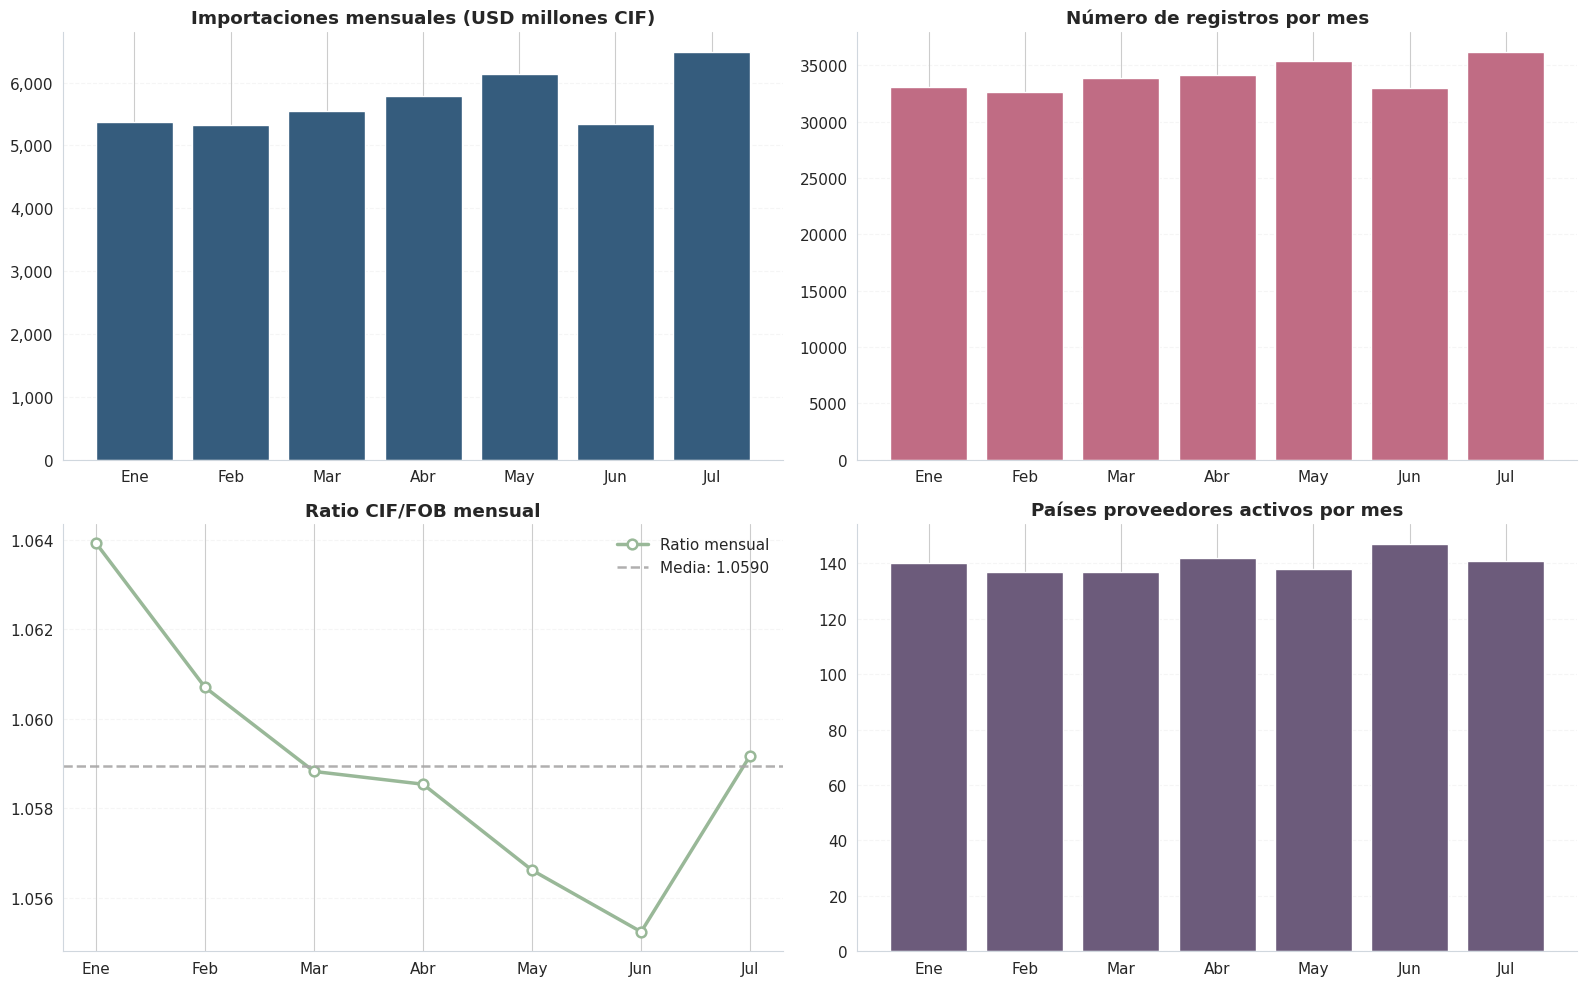


--- Evolución Mensual ---
        total_cif  n_registros  n_paises  ratio_cif_fob
mes                                                    
1    5.378779e+09        33073       140       1.063934
2    5.325917e+09        32638       137       1.060706
3    5.543051e+09        33839       137       1.058822
4    5.794669e+09        34149       142       1.058537
5    6.135260e+09        35418       138       1.056613
6    5.336837e+09        33023       147       1.055234
7    6.483982e+09        36165       141       1.059178

✅ Gráfica y tabla de evolución añadidas a hallazgos.md


In [ ]:
# --- 1. CÁLCULO DE EVOLUCIÓN ---
evolucion = df_completo.groupby(df_completo[mes_col].astype(int)).agg(
    total_cif=(cif_col, 'sum'),
    total_fob=(fob_col, 'sum'),
    total_kg=(kg_col, 'sum'),
    n_registros=(cif_col, 'count'),
    n_paises=(pais_col, 'nunique')
).sort_index()

# Calculamos el ratio directamente en el DataFrame original de evolución
evolucion['ratio_cif_fob'] = evolucion['total_cif'] / evolucion['total_fob']


# --- 2. GENERACIÓN DE GRÁFICA ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

meses_nombres = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul']
x_labels = [meses_nombres[m-1] for m in evolucion.index]


# --- PALETA PERSONALIZADA MULTICOLOR ---
palette_elegante = [
    '#355C7D',  # azul petróleo
    '#C06C84',  # rosa vino
    '#6C5B7B',  # violeta grisáceo
    '#F67280',  # coral
    '#99B898',  # verde suave
    '#FECEAB',  # durazno
    '#8E806A',  # taupe
    '#A8A7A7',  # gris
    '#E8A87C'   # terracota
]

# Un color distinto para cada gráfica
COLOR_CIF = palette_elegante[0]        # gráfica 1
COLOR_REGISTROS = palette_elegante[1]  # gráfica 2
COLOR_RATIO = palette_elegante[4]      # gráfica 3
COLOR_PAISES = palette_elegante[2]     # gráfica 4
COLOR_MEDIA = palette_elegante[7]      # línea de media

# Colores diferenciados para los meses
colores_barras = [
    palette_elegante[i % len(palette_elegante)]
    for i in range(len(evolucion.index))
]


# Gráfica 1: CIF
ax1 = axes[0, 0]
ax1.bar(
    x_labels,
    evolucion['total_cif'] / 1e6,
    color=COLOR_CIF,
    edgecolor='white',
    linewidth=1
)
ax1.set_title('Importaciones mensuales (USD millones CIF)', fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))


# Gráfica 2: Registros
ax2 = axes[0, 1]
ax2.bar(
    x_labels,
    evolucion['n_registros'],
    color=COLOR_REGISTROS,
    edgecolor='white',
    linewidth=1
)
ax2.set_title('Número de registros por mes', fontweight='bold')


# Gráfica 3: Ratio CIF/FOB
ax3 = axes[1, 0]
ratio_cif_fob_medio = total_cif_real / total_fob_real

ax3.plot(
    x_labels,
    evolucion['ratio_cif_fob'],
    marker='o',
    linestyle='-',
    color=COLOR_RATIO,
    linewidth=2.5,
    markersize=7,
    markerfacecolor='white',
    markeredgecolor=COLOR_RATIO,
    markeredgewidth=1.8,
    label='Ratio mensual'
)

ax3.axhline(
    y=ratio_cif_fob_medio,
    color=COLOR_MEDIA,
    linestyle='--',
    linewidth=1.8,
    alpha=0.9,
    label=f'Media: {ratio_cif_fob_medio:.4f}'
)

ax3.set_title('Ratio CIF/FOB mensual', fontweight='bold')
ax3.legend(frameon=False)

# Gráfica 4: Países
ax4 = axes[1, 1]
ax4.bar(
    x_labels,
    evolucion['n_paises'],
    color=COLOR_PAISES,
    edgecolor='white',
    linewidth=1
)
ax4.set_title('Países proveedores activos por mes', fontweight='bold')

# --- ESTILO GENERAL ---
for ax in axes.flat:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#D0D7DE')
    ax.spines['bottom'].set_color('#D0D7DE')
    ax.grid(axis='y', linestyle='--', alpha=0.18)
    ax.set_axisbelow(True)

plt.tight_layout()


# --- GUARDAR IMAGEN ---
nombre_img = '02_evolucion_mensual.png'
plt.savefig(nombre_img, dpi=150, bbox_inches='tight')
plt.show()


# --- 3. PRINTS Y REPORTE MD ---
print(f"\n--- Evolución Mensual ---")
print(evolucion[['total_cif', 'n_registros', 'n_paises', 'ratio_cif_fob']])

reporte_evolucion = "\n## 2.1 Evolución Temporal\n\n"
reporte_evolucion += (
    "A continuación se presenta la tendencia mensual de las importaciones, "
    "el volumen de operaciones y la estabilidad de los costos logísticos "
    "(Ratio CIF/FOB):\n\n"
)

# Inserción de la imagen en Markdown
reporte_evolucion += f"![Evolución Mensual]({nombre_img})\n\n"

# Tabla resumen para acompañar la gráfica
reporte_evolucion += "### Datos de la evolución mensual\n\n"

resumen_md = evolucion.copy()
resumen_md['total_cif'] = resumen_md['total_cif'].map('USD {:,.2f}'.format)
resumen_md['total_fob'] = resumen_md['total_fob'].map('USD {:,.2f}'.format)
resumen_md['ratio_cif_fob'] = resumen_md['ratio_cif_fob'].map('{:.4f}'.format)
resumen_md['total_kg'] = resumen_md['total_kg'].map('{:,.0f}'.format)

reporte_evolucion += resumen_md[
    ['total_cif', 'n_registros', 'n_paises', 'ratio_cif_fob']
].to_markdown() + "\n"

mes_max_cif = evolucion['total_cif'].idxmax()
val_max_cif = evolucion['total_cif'].max()

reporte_evolucion += f"\n**Hallazgos clave para IA:**\n"
reporte_evolucion += (
    f"- El mes con mayor volumen de importación fue el mes **{mes_max_cif}** "
    f"con **USD {val_max_cif:,.2f}**.\n"
)
reporte_evolucion += (
    f"- El costo logístico (Ratio CIF/FOB) osciló entre "
    f"**{evolucion['ratio_cif_fob'].min():.4f}** y "
    f"**{evolucion['ratio_cif_fob'].max():.4f}**.\n"
)

# --- GUARDAR EN ARCHIVO ---
with open("hallazgos.md", "a", encoding="utf-8") as f:
    f.write(reporte_evolucion)

print(f"\n✅ Gráfica y tabla de evolución añadidas a hallazgos.md")

### 2.2 Análisis de concentración — Índice Herfindahl-Hirschman (HHI)

In [ ]:
# --- 1. CÁLCULO DE HHI-
def calcular_hhi(df_input, grupo_col, valor_col):
    """Calcula el Índice Herfindahl-Hirschman."""
    total = df_input[valor_col].sum()
    participaciones = df_input.groupby(grupo_col)[valor_col].sum() / total
    hhi = (participaciones ** 2).sum() * 10000
    return hhi, participaciones.sort_values(ascending=False)

# HHI global por país
hhi_global, part_paises = calcular_hhi(df_completo, pais_col, cif_col)

# HHI por mes (evolución)
hhi_mensual = {}
for mes in sorted(df_completo[mes_col].astype(int).unique()):
    df_mes = df_completo[df_completo[mes_col].astype(int) == mes]
    hhi_mes, _ = calcular_hhi(df_mes, pais_col, cif_col)
    hhi_mensual[mes] = hhi_mes

# --- 2. DETERMINAR NIVEL DE CONCENTRACIÓN ---
if hhi_global < 1000:
    status_hhi = "Mercado NO concentrado (competitivo)"
elif hhi_global < 1800:
    status_hhi = "Mercado MODERADAMENTE concentrado"
else:
    status_hhi = "Mercado ALTAMENTE concentrado"

# --- 3. PRINTS EN CONSOLA (Exactamente como los pediste) ---
print(f"{'='*60}")
print(f"ANÁLISIS DE CONCENTRACIÓN (HHI)")
print(f"{'='*60}")
print(f"HHI Global por país: {hhi_global:.0f}")
print(f"  → {status_hhi}")

print(f"\nTop 10 países proveedores (participación % CIF):")
top10 = part_paises.head(10)
acumulado = top10.cumsum() * 100

for pais, part in top10.items():
    print(f"  {pais:35s} {part*100:6.2f}%  (acum: {acumulado[pais]:.1f}%)")

concentracion_top5 = part_paises.head(5).sum() * 100
concentracion_top10 = part_paises.head(10).sum() * 100
print(f"\nConcentración Top 5: {concentracion_top5:.1f}%")
print(f"Concentración Top 10: {concentracion_top10:.1f}%")

# --- 4. PREPARACIÓN DEL REPORTE MD ---
reporte_hhi = "\n## 2.2 Análisis de Concentración (Índice HHI)\n\n"
reporte_hhi += f"El Índice Herfindahl-Hirschman (HHI) para los países de origen es de **{hhi_global:.0f}**.\n\n"
reporte_hhi += f"> **Interpretación**: {status_hhi}.\n\n"

# Tabla de Participación Top 10 para MD
reporte_hhi += "### Top 10 Países Proveedores\n"
tabla_hhi_data = []
acumulado = top10.cumsum() * 100
for pais, part in top10.items():
    tabla_hhi_data.append([pais, f"{part*100:.2f}%", f"{acumulado[pais]:.2f}%"])

df_hhi_md = pd.DataFrame(tabla_hhi_data, columns=["País", "Participación %", "Acumulado %"])
reporte_hhi += df_hhi_md.to_markdown(index=False) + "\n\n"

# Resumen de métricas de concentración
reporte_hhi += f"- **Concentración Top 5**: {concentracion_top5:.2f}%\n"
reporte_hhi += f"- **Concentración Top 10**: {concentracion_top10:.2f}%\n"

# Evolución del HHI por mes (Muy útil para ver si la dependencia cambia)
reporte_hhi += "\n### Evolución Mensual del HHI\n"
resumen_hhi_mes = pd.DataFrame(list(hhi_mensual.items()), columns=["Mes", "HHI"])
reporte_hhi += resumen_hhi_mes.to_markdown(index=False) + "\n"

# --- 5. GUARDAR EN ARCHIVO ---
with open("hallazgos.md", "a", encoding="utf-8") as f:
    f.write(reporte_hhi)

print(f"\n✅ Análisis HHI guardado en hallazgos.md")

ANÁLISIS DE CONCENTRACIÓN (HHI)
HHI Global por país: 1397
  → Mercado MODERADAMENTE concentrado

Top 10 países proveedores (participación % CIF):
  China                                26.53%  (acum: 26.5%)
  Estados Unidos                       24.25%  (acum: 50.8%)
  Brasil                                4.95%  (acum: 55.7%)
  México                                4.88%  (acum: 60.6%)
  Alemania                              3.30%  (acum: 63.9%)
  India                                 2.57%  (acum: 66.5%)
  Japón                                 2.39%  (acum: 68.9%)
  Corea del Sur                         1.87%  (acum: 70.7%)
  España                                1.82%  (acum: 72.6%)
  Vietnam                               1.73%  (acum: 74.3%)

Concentración Top 5: 63.9%
Concentración Top 10: 74.3%

✅ Análisis HHI guardado en hallazgos.md


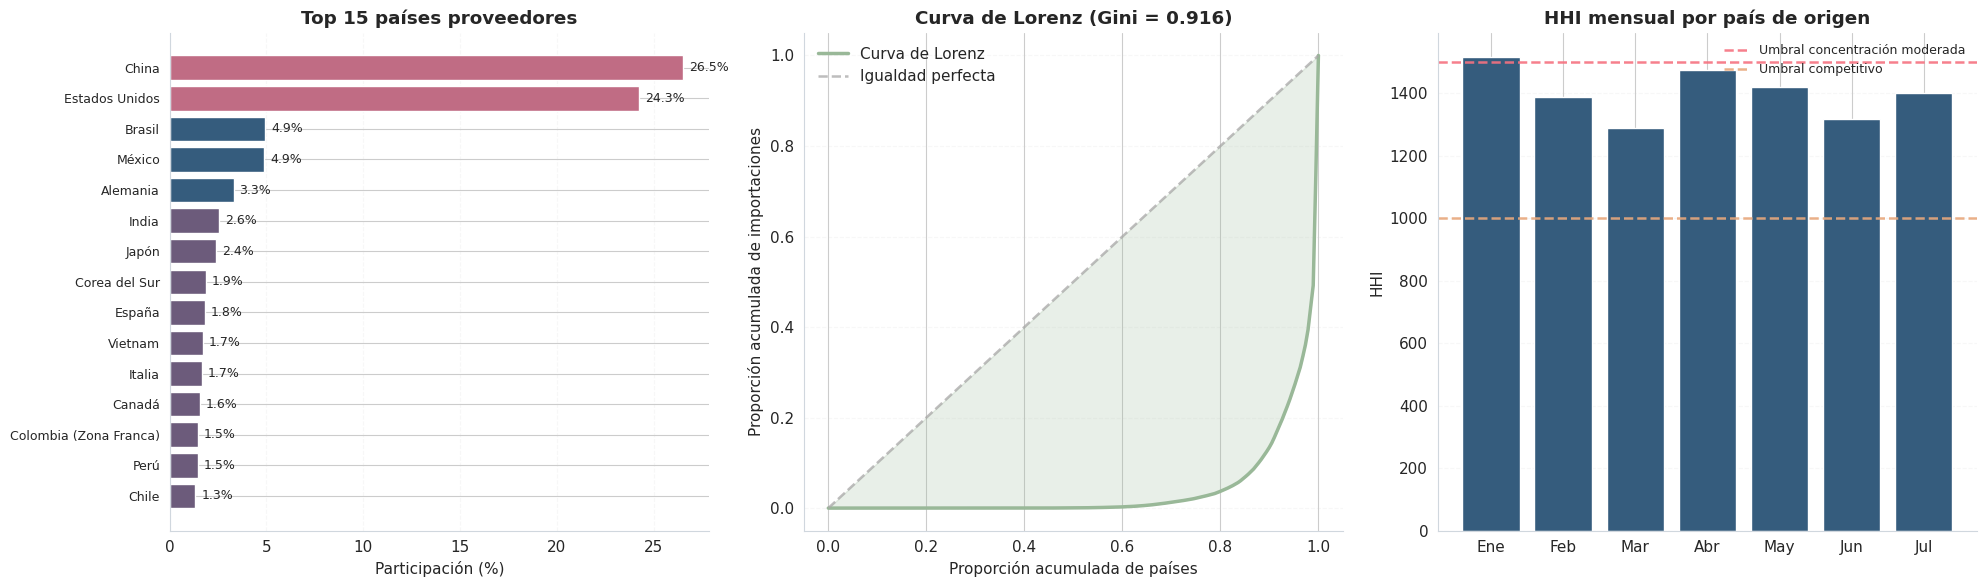


 | Métrica                                |     Valor | Nota                                            |
|:---------------------------------------|----------:|:------------------------------------------------|
| Coeficiente de Gini                    |    0.9158 | Cercano a 1 es máxima desigualdad               |
| HHI Global                             | 1397      | Interpretación según umbrales antimonopolio     |
| Países Necesarios para el 80% (Pareto) |   14      | Indica la dependencia de la canasta importadora | 

✅ Tabla Top 15 y métricas Gini añadidas para análisis


In [ ]:
# --- PALETA PERSONALIZADA MULTICOLOR ---
palette_elegante = [
    '#355C7D',  # azul petróleo
    '#C06C84',  # rosa vino
    '#6C5B7B',  # violeta grisáceo
    '#F67280',  # coral
    '#99B898',  # verde suave
    '#FECEAB',  # durazno
    '#8E806A',  # taupe
    '#A8A7A7',  # gris
    '#E8A87C'   # terracota
]

# --- ASIGNACIÓN FUNCIONAL DE COLORES ---
COLOR_PRINCIPAL = palette_elegante[0]   # azul petróleo
COLOR_SECUNDARIO = palette_elegante[2]  # violeta grisáceo
COLOR_ACENTO = palette_elegante[1]      # rosa vino
COLOR_SUAVE = palette_elegante[5]       # durazno
COLOR_ALERTA1 = palette_elegante[3]     # coral
COLOR_ALERTA2 = palette_elegante[8]     # terracota
COLOR_LINEA = palette_elegante[4]       # verde suave
COLOR_GRIS = palette_elegante[7]        # gris


# --- 1. GENERACIÓN DE GRÁFICAS ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))


# ============================================================
# Top 15 países
# ============================================================
ax1 = axes[0]
top15 = part_paises.head(15)

colors_top = [
    COLOR_ACENTO if i < 2 else
    COLOR_PRINCIPAL if i < 5 else
    COLOR_SECUNDARIO
    for i in range(len(top15))
]

ax1.barh(
    range(len(top15)),
    top15.values * 100,
    color=colors_top,
    edgecolor='white',
    linewidth=1
)

ax1.set_yticks(range(len(top15)))
ax1.set_yticklabels(top15.index, fontsize=9)
ax1.invert_yaxis()
ax1.set_xlabel('Participación (%)')
ax1.set_title('Top 15 países proveedores', fontweight='bold')

for i, v in enumerate(top15.values):
    ax1.text(
        v * 100 + 0.3,
        i,
        f'{v*100:.1f}%',
        va='center',
        fontsize=9
    )


# ============================================================
# Curva de Lorenz
# ============================================================
ax2 = axes[1]

participaciones_sorted = part_paises.sort_values(ascending=True).values
lorenz = np.cumsum(participaciones_sorted)
lorenz = np.insert(lorenz, 0, 0)
x_lorenz = np.linspace(0, 1, len(lorenz))

ax2.plot(
    x_lorenz,
    lorenz,
    color=COLOR_LINEA,
    linewidth=2.5,
    label='Curva de Lorenz'
)

ax2.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    color=COLOR_GRIS,
    alpha=0.75,
    linewidth=1.8,
    label='Igualdad perfecta'
)

ax2.fill_between(
    x_lorenz,
    lorenz,
    x_lorenz,
    alpha=0.22,
    color=COLOR_LINEA
)

gini = 1 - 2 * np.trapz(lorenz, x_lorenz)

ax2.set_title(f'Curva de Lorenz (Gini = {gini:.3f})', fontweight='bold')
ax2.set_xlabel('Proporción acumulada de países')
ax2.set_ylabel('Proporción acumulada de importaciones')
ax2.legend(frameon=False)


# ============================================================
# HHI mensual
# ============================================================
ax3 = axes[2]

meses_hhi = sorted(hhi_mensual.keys())
valores_hhi = [hhi_mensual[m] for m in meses_hhi]

try:
    colores_hhi = [
        COLOR_PRINCIPAL if m in meses_existentes else COLOR_SUAVE
        for m in meses_hhi
    ]
except:
    colores_hhi = COLOR_PRINCIPAL

ax3.bar(
    [meses_nombres[m-1] for m in meses_hhi],
    valores_hhi,
    color=colores_hhi,
    edgecolor='white',
    linewidth=1
)

ax3.axhline(
    y=1500,
    color=COLOR_ALERTA1,
    linestyle='--',
    linewidth=1.8,
    alpha=0.9,
    label='Umbral concentración moderada'
)

ax3.axhline(
    y=1000,
    color=COLOR_ALERTA2,
    linestyle='--',
    linewidth=1.8,
    alpha=0.9,
    label='Umbral competitivo'
)

ax3.set_title('HHI mensual por país de origen', fontweight='bold')
ax3.set_ylabel('HHI')
ax3.legend(fontsize=9, frameon=False)


# ============================================================
# Estilo general
# ============================================================
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#D0D7DE')
    ax.spines['bottom'].set_color('#D0D7DE')
    ax.grid(axis='x' if ax == ax1 else 'y', linestyle='--', alpha=0.15)
    ax.set_axisbelow(True)

plt.tight_layout()

# GUARDAR IMAGEN
nombre_img_hhi = '03_concentracion_hhi.png'
plt.savefig(nombre_img_hhi, dpi=150, bbox_inches='tight')
plt.show()


# --- 2. REPORTE MD ---
reporte_visual_hhi = "\n### 2.2.1 Visualización de Estructura de Mercado\n\n"
reporte_visual_hhi += f"![Análisis de Concentración]({nombre_img_hhi})\n\n"

reporte_visual_hhi += "**Análisis de Desigualdad y Estabilidad:**\n"
reporte_visual_hhi += f"- **Coeficiente de Gini**: **{gini:.3f}**. "

if gini > 0.7:
    reporte_visual_hhi += "Indica una distribución de proveedores altamente desigual (pocos países dominan casi todo el valor).\n"
else:
    reporte_visual_hhi += "Indica una distribución de proveedores relativamente balanceada.\n"

reporte_visual_hhi += (
    f"- **Estabilidad Mensual**: El HHI muestra una tendencia "
    f"{'estable' if np.std(valores_hhi) < 100 else 'volátil'} "
    f"a lo largo de los meses analizados.\n"
)

# --- 2.2.2 DATOS PARA PROCESAMIENTO ---
reporte_visual_hhi += "#### Detalle del Top 15 de Países Proveedores\n"

df_top15_md = pd.DataFrame({
    "Ranking": range(1, 16),
    "País": top15.index,
    "Participación %": [f"{v*100:.2f}%" for v in top15.values],
    "Acumulado %": [f"{part_paises[part_paises >= v].sum()*100:.2f}%" for v in top15.values]
})

reporte_visual_hhi += df_top15_md.to_markdown(index=False) + "\n\n"

# Resumen técnico de métricas de desigualdad
reporte_visual_hhi += "#### Resumen Estadístico de Concentración\n"

metricas_desigualdad = pd.DataFrame({
    "Métrica": [
        "Coeficiente de Gini",
        "HHI Global",
        "Países Necesarios para el 80% (Pareto)"
    ],
    "Valor": [
        f"{gini:.4f}",
        f"{hhi_global:.0f}",
        f"{(part_paises.cumsum() <= 0.8).sum() + 1}"
    ],
    "Nota": [
        "Cercano a 1 es máxima desigualdad",
        "Interpretación según umbrales antimonopolio",
        "Indica la dependencia de la canasta importadora"
    ]
})

print('\n', metricas_desigualdad.to_markdown(index=False), '\n')
reporte_visual_hhi += metricas_desigualdad.to_markdown(index=False) + "\n"

# --- 3. GUARDAR EN ARCHIVO ---
with open("hallazgos.md", "a", encoding="utf-8") as f:
    f.write(reporte_visual_hhi)

print("✅ Tabla Top 15 y métricas Gini añadidas para análisis")

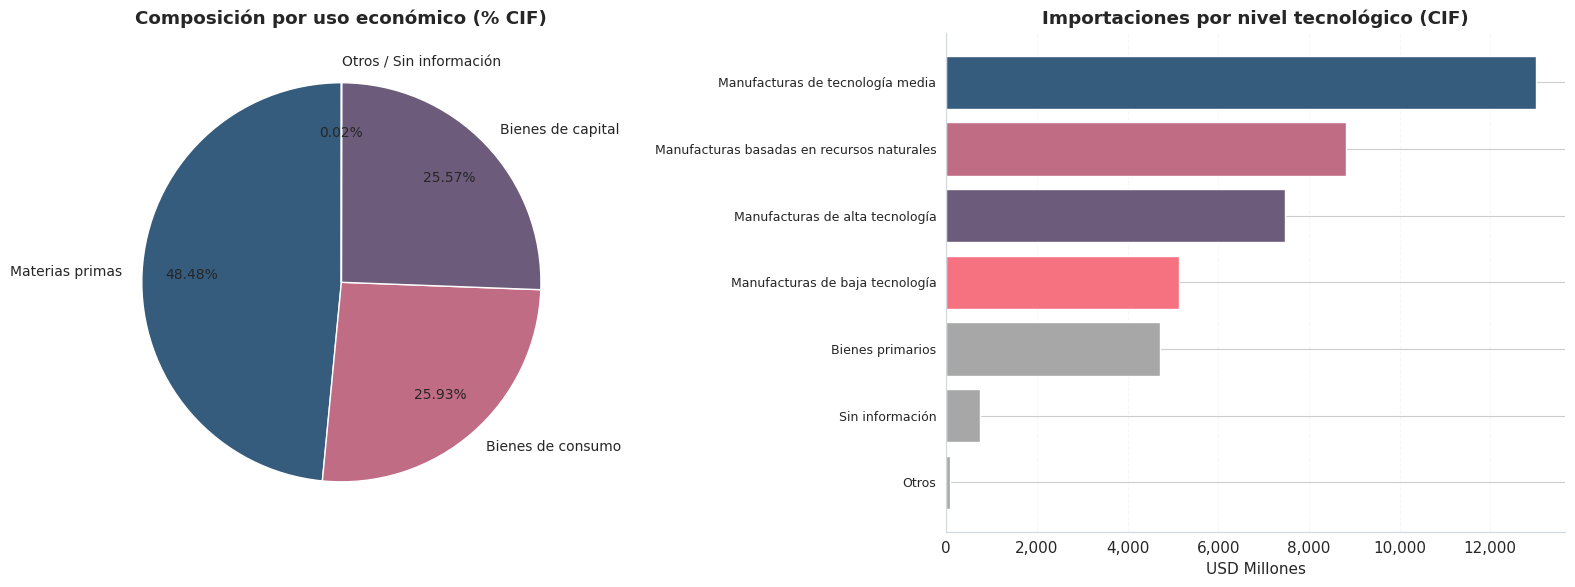

COMPOSICIÓN ECONÓMICA Y TECNOLÓGICA

Distribución por Uso Económico:
  - Materias primas                         :  48.48%
  - Bienes de consumo                       :  25.93%
  - Bienes de capital                       :  25.57%
  - Otros / Sin información                 :   0.02%

Distribución por Nivel Tecnológico (Millones USD):
  - Manufacturas de tecnología media        : USD 13007.82M
  - Manufacturas basadas en recursos naturales: USD  8815.74M
  - Manufacturas de alta tecnología         : USD  7480.74M
  - Manufacturas de baja tecnología         : USD  5145.30M
  - Bienes primarios                        : USD  4716.32M
  - Sin información                         : USD   753.89M
  - Otros                                   : USD    78.69M

✅ Perfil tecnológico y de uso guardado en hallazgos.md


In [ ]:
# --- PALETA AJUSTADA ---
palette_elegante = [
    '#355C7D',  # azul petróleo
    '#C06C84',  # rosa vino
    '#6C5B7B',  # violeta grisáceo
    '#F67280',  # coral
    '#99B898',  # verde suave
    '#FECEAB',  # durazno
    '#8E806A',  # taupe
    '#A8A7A7',  # gris
    '#E8A87C'   # terracota
]

# --- COLORES FUNCIONALES, MANTENIENDO LA DISTRIBUCIÓN ORIGINAL ---
COLOR_PRINCIPAL = palette_elegante[0]   # azul petróleo
COLOR_LINEA = palette_elegante[1]       # rosa vino
COLOR_SECUNDARIO = palette_elegante[2]  # violeta grisáceo
COLOR_ACENTO = palette_elegante[3]      # coral
COLOR_RESTO = palette_elegante[7]       # gris

# --- 1. PROCESAMIENTO Y GENERACIÓN DE GRÁFICAS ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ============================================================
# Lógica para Uso Económico
# ============================================================
if uso_col:
    uso_data = df_completo.groupby(uso_col)[cif_col].sum().sort_values(ascending=False)
    umbral = 0.005 * uso_data.sum()
    uso_principales = uso_data[uso_data >= umbral].copy()
    uso_menores = uso_data[uso_data < umbral]

    if len(uso_menores) > 0:
        uso_principales['Otros / Sin información'] = uso_menores.sum()

    # Mantener colores secuenciales de la paleta
    colores_uso = [palette_elegante[i % len(palette_elegante)] for i in range(len(uso_principales))]

    axes[0].pie(
        uso_principales.values,
        labels=uso_principales.index,
        autopct='%1.2f%%',
        colors=colores_uso,
        startangle=90,
        pctdistance=0.75,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1},
        textprops={'fontsize': 10}
    )
    axes[0].set_title('Composición por uso económico (% CIF)', fontweight='bold')

# ============================================================
# Lógica para Nivel Tecnológico
# ============================================================
if nivel_tec_col:
    tec_data = df_completo.groupby(nivel_tec_col)[cif_col].sum().sort_values(ascending=False)
    umbral_tec = 0.005 * tec_data.sum()
    tec_principales = tec_data[tec_data >= umbral_tec].copy()
    tec_menores = tec_data[tec_data < umbral_tec]

    if len(tec_menores) > 0:
        tec_principales['Otros'] = tec_menores.sum()

    # Mantener la misma distribución original por posición
    colores_tec = [
        COLOR_PRINCIPAL if i == 0 else
        COLOR_LINEA if i == 1 else
        COLOR_SECUNDARIO if i == 2 else
        COLOR_ACENTO if i == 3 else
        COLOR_RESTO
        for i in range(len(tec_principales))
    ]

    axes[1].barh(
        range(len(tec_principales)),
        tec_principales.values / 1e6,
        color=colores_tec,
        edgecolor='white'
    )
    axes[1].set_yticks(range(len(tec_principales)))
    axes[1].set_yticklabels(tec_principales.index, fontsize=9)
    axes[1].invert_yaxis()
    axes[1].set_xlabel('USD Millones')
    axes[1].set_title('Importaciones por nivel tecnológico (CIF)', fontweight='bold')
    axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

    # Estilo limpio
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)
    axes[1].spines['left'].set_color('#D0D7DE')
    axes[1].spines['bottom'].set_color('#D0D7DE')
    axes[1].grid(axis='x', linestyle='--', alpha=0.15)
    axes[1].set_axisbelow(True)

plt.tight_layout()
nombre_img_uso = '04_composicion_uso_tecnologia.png'
plt.savefig(nombre_img_uso, dpi=150, bbox_inches='tight')
plt.show()

# --- 2. PRINTS EN CONSOLA ---
print(f"{'='*60}")
print("COMPOSICIÓN ECONÓMICA Y TECNOLÓGICA")
print(f"{'='*60}")

if uso_col:
    print("\nDistribución por Uso Económico:")
    for cat, val in (uso_principales / uso_data.sum() * 100).items():
        print(f"  - {cat:40s}: {val:6.2f}%")

if nivel_tec_col:
    print("\nDistribución por Nivel Tecnológico (Millones USD):")
    for cat, val in (tec_principales / 1e6).items():
        print(f"  - {cat:40s}: USD {val:8.2f}M")

# --- 3. REPORTE MD (AI-READY) ---
reporte_tec = "\n## 2.3 Perfil Económico y Tecnológico\n\n"
reporte_tec += f"![Uso y Tecnología]({nombre_img_uso})\n\n"

# Tabla de Uso Económico
if uso_col:
    reporte_tec += "### 2.3.1 Clasificación por Uso o Destino Económico (CUODE)\n"
    df_uso_md = (uso_principales / uso_data.sum() * 100).reset_index()
    df_uso_md.columns = ['Categoría Uso', 'Participación %']
    df_uso_md['Participación %'] = df_uso_md['Participación %'].map('{:.2f}%'.format)
    reporte_tec += df_uso_md.to_markdown(index=False) + "\n\n"

# Tabla de Nivel Tecnológico
if nivel_tec_col:
    reporte_tec += "### 2.3.2 Intensidad Tecnológica de las Importaciones\n"
    df_tec_md = pd.DataFrame({
        'Nivel Tecnológico': tec_principales.index,
        'Valor (USD)': tec_principales.values,
        'Participación %': (tec_principales.values / tec_data.sum() * 100)
    })
    df_tec_md['Valor (USD)'] = df_tec_md['Valor (USD)'].map('USD {:,.2f}'.format)
    df_tec_md['Participación %'] = df_tec_md['Participación %'].map('{:.2f}%'.format)
    reporte_tec += df_tec_md.to_markdown(index=False) + "\n"

# --- 4. GUARDAR EN ARCHIVO ---
with open("hallazgos.md", "a", encoding="utf-8") as f:
    f.write(reporte_tec)

print("\n✅ Perfil tecnológico y de uso guardado en hallazgos.md")

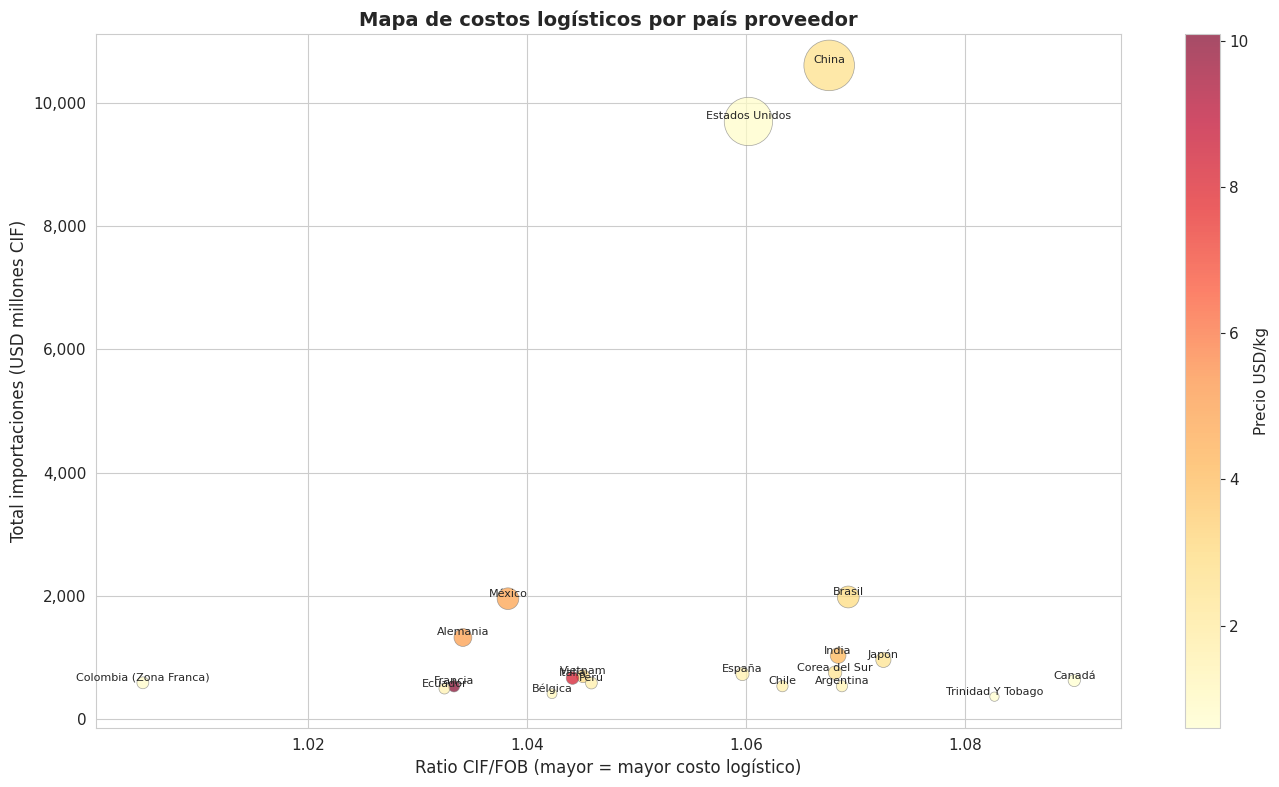

ANÁLISIS DE EFICIENCIA LOGÍSTICA
Ratio medio global: 1.0590

Top 10 países por costo logístico relativo (Ratio CIF/FOB):
                   ratio_cif_fob  precio_kg     total_cif
pais                                                     
Canadá                  1.089942   0.597547  6.223147e+08
Trinidad Y Tobago       1.082653   0.642354  3.600952e+08
Japón                   1.072511   2.424410  9.572986e+08
Brasil                  1.069304   2.922709  1.978690e+09
Argentina               1.068726   1.385251  5.304743e+08
India                   1.068375   4.125999  1.028196e+09
Corea del Sur           1.068098   2.418382  7.483353e+08
China                   1.067561   2.604957  1.061084e+10
Chile                   1.063293   1.679239  5.310364e+08
Estados Unidos          1.060187   0.777443  9.700009e+09

✅ Análisis logístico documentado en hallazgos.md


In [ ]:
# --- 1. PROCESAMIENTO LOGÍSTICO ---
logistica = df_completo.groupby(pais_col).agg(
    total_cif=(cif_col, 'sum'),
    total_fob=(fob_col, 'sum'),
    total_kg=(kg_col, 'sum'),
    n_registros=(cif_col, 'count')
)
logistica['ratio_cif_fob'] = logistica['total_cif'] / logistica['total_fob']
logistica['costo_logistico_usd'] = logistica['total_cif'] - logistica['total_fob']
logistica['precio_kg'] = logistica['total_cif'] / logistica['total_kg']
logistica['participacion'] = logistica['total_cif'] / logistica['total_cif'].sum()

# Filtrar países relevantes (>0.1% de participación)
logistica_relevante = logistica[logistica['participacion'] > 0.001].sort_values('total_cif', ascending=False)

# --- 2. GENERACIÓN DE GRÁFICA ---
fig, ax = plt.subplots(figsize=(14, 8))
top20_log = logistica_relevante.head(20).copy()

scatter = ax.scatter(
    top20_log['ratio_cif_fob'],
    top20_log['total_cif'] / 1e6,
    s=top20_log['participacion'] * 5000,
    c=top20_log['precio_kg'].clip(upper=50),
    cmap='YlOrRd',
    alpha=0.7,
    edgecolors='gray',
    linewidth=0.5
)

for _, row in top20_log.iterrows():
    ax.annotate(row.name, (row['ratio_cif_fob'], row['total_cif']/1e6),
                fontsize=8, ha='center', va='bottom')

plt.colorbar(scatter, label='Precio USD/kg')
ax.set_xlabel('Ratio CIF/FOB (mayor = mayor costo logístico)', fontsize=12)
ax.set_ylabel('Total importaciones (USD millones CIF)', fontsize=12)
ax.set_title('Mapa de costos logísticos por país proveedor', fontweight='bold', fontsize=14)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()

nombre_img_log = '05_costos_logisticos.png'
plt.savefig(nombre_img_log, dpi=150, bbox_inches='tight')
plt.show()

# --- 3. PRINTS EN CONSOLA ---
print(f"{'='*60}")
print(f"ANÁLISIS DE EFICIENCIA LOGÍSTICA")
print(f"{'='*60}")
print(f"Ratio medio global: {total_cif_real/total_fob_real:.4f}")
print("\nTop 10 países por costo logístico relativo (Ratio CIF/FOB):")
print(top20_log[['ratio_cif_fob', 'precio_kg', 'total_cif']].sort_values('ratio_cif_fob', ascending=False).head(10))

# --- 4. REPORTE MD (AI-READY) ---
reporte_log = "\n## 2.4 Análisis de Costos Logísticos y Eficiencia\n\n"
reporte_log += f"![Mapa de Costos Logísticos]({nombre_img_log})\n\n"
reporte_log += "> **Interpretación del Mapa**: El tamaño de la burbuja representa el volumen de importación, el color indica el valor unitario (USD/kg) y la posición en X muestra el recargo logístico (seguro y flete).\n\n"

reporte_log += "### 2.4.1 Tabla de Indicadores Logísticos (Top 20 países)\n"
# Preparamos tabla para MD
df_log_md = top20_log.reset_index().copy()
df_log_md.columns = ['País', 'Total CIF', 'Total FOB', 'Total Kg', 'Registros', 'Ratio CIF/FOB', 'Costo Log USD', 'Precio USD/Kg', 'Part %']

# Formateo para que la IA y el humano lean fácil
df_log_md['Total CIF'] = df_log_md['Total CIF'].map('USD {:,.0f}'.format)
df_log_md['Ratio CIF/FOB'] = df_log_md['Ratio CIF/FOB'].map('{:.4f}'.format)
df_log_md['Precio USD/Kg'] = df_log_md['Precio USD/Kg'].map('{:,.2f}'.format)
df_log_md['Part %'] = (df_log_md['Part %'] * 100).map('{:.2f}%'.format)

reporte_log += df_log_md[['País', 'Total CIF', 'Ratio CIF/FOB', 'Precio USD/Kg', 'Part %']].to_markdown(index=False) + "\n\n"

# Hallazgos específicos para IA
pais_max_ratio = top20_log['ratio_cif_fob'].idxmax()
val_max_ratio = top20_log['ratio_cif_fob'].max()

reporte_log += "### Hallazgos Clave de Logística\n"
reporte_log += f"- **Máximo Costo Relativo**: El origen con mayor ratio logístico es **{pais_max_ratio}** ({val_max_ratio:.4f}).\n"
reporte_log += f"- **Referencia de Valor**: La media de costo de flete y seguro para Bogotá se sitúa en **{(total_cif_real/total_fob_real - 1)*100:.2f}%** sobre el valor FOB.\n"

# --- 5. GUARDAR EN ARCHIVO ---
with open("hallazgos.md", "a", encoding="utf-8") as f:
    f.write(reporte_log)

print(f"\n✅ Análisis logístico documentado en hallazgos.md")

In [ ]:
# --- 1. PROCESAMIENTO DE DATOS ---
df = df_completo.copy()
top_n = 15

top_paises = (
    df.groupby('pais')[cif_col]
    .sum()
    .nlargest(top_n)
    .index
)

df['pais_group'] = df['pais'].where(
    df['pais'].isin(top_paises),
    'Otros'
)

cols = ['pais_group', 'uso_economico', 'nivel_tecnologico']
for col in cols:
    df[col] = df[col].astype(str).str.strip()

df = df.dropna(subset=cols)

df_base = df.groupby(
    ['pais_group', 'uso_economico', 'nivel_tecnologico']
)[cif_col].sum().reset_index()

df_base = df_base.nlargest(top_n, cif_col)

# Agrupaciones para los flujos
df_pais_uso = df_base.groupby(['pais_group', 'uso_economico'])[cif_col].sum().reset_index()
df_uso_tec = df_base.groupby(['uso_economico', 'nivel_tecnologico'])[cif_col].sum().reset_index()

# Nodos y diccionarios
labels = list(pd.concat([
    df_pais_uso['pais_group'],
    df_pais_uso['uso_economico'],
    df_uso_tec['nivel_tecnologico']
]).unique())
label_dict = {label: i for i, label in enumerate(labels)}

# --- 2. GESTIÓN DE COLORES ROBUSTA ---
palette_sankey = px.colors.qualitative.Pastel

def safe_rgba(color_str, alpha=0.4):
    """Convierte colores de plotly a rgba seguro para el Sankey."""
    try:
        if color_str.startswith('rgb'):
            vals = re.findall(r'\d+', color_str)
            return f'rgba({vals[0]},{vals[1]},{vals[2]},{alpha})'
        elif color_str.startswith('#'):
            h = color_str.lstrip('#')
            rgb = tuple(int(h[i:i+2], 16) for i in (0, 2, 4))
            return f'rgba({rgb[0]},{rgb[1]},{rgb[2]},{alpha})'
    except:
        return f'rgba(150,150,150,{alpha})'

# Mapeo de colores por país
paises_sankey = df_pais_uso['pais_group'].unique()
color_map = {pais: safe_rgba(palette_sankey[i % len(palette_sankey)], 0.5)
             for i, pais in enumerate(paises_sankey)}
color_map['Otros'] = "rgba(120,120,120,0.4)"

# --- 3. CONSTRUCCIÓN DE LINKS Y NODOS ---
source = pd.concat([df_pais_uso['pais_group'].map(label_dict), df_uso_tec['uso_economico'].map(label_dict)])
target = pd.concat([df_pais_uso['uso_economico'].map(label_dict), df_uso_tec['nivel_tecnologico'].map(label_dict)])
value = pd.concat([df_pais_uso[cif_col], df_uso_tec[cif_col]])
color_links = pd.concat([df_pais_uso['pais_group'].map(color_map),
                         pd.Series(["rgba(160,160,160,0.2)"] * len(df_uso_tec))])

node_colors = []
for label in labels:
    if label in df_pais_uso['pais_group'].values: node_colors.append("rgba(100,149,237,0.8)")
    elif label in df_pais_uso['uso_economico'].values: node_colors.append("rgba(186,85,211,0.8)")
    else: node_colors.append("rgba(255,165,0,0.8)")

# --- 4. GENERACIÓN DEL GRÁFICO ---
fig_sankey = go.Figure(data=[go.Sankey(
    arrangement="fixed",
    node=dict(
        pad=25,
        thickness=18,
        label=labels,
        color=node_colors,
        line=dict(color="rgba(0,0,0,0.2)", width=0.5)
    ),
    link=dict(source=source, target=target, value=value, color=color_links)
)])

fig_sankey.update_layout(
    title_text="Análisis de Flujo Estructural: Origen → Uso → Tecnología",
    font_size=12,
    width=1200,
    height=700
)

asset_sankey = guardar_plotly(fig_sankey, "05_sankey_flujo_estructural")
fig_sankey.show()

append_hallazgos(
    "2.5 Análisis de flujo estructural (Sankey)",
    texto="""
    El diagrama de Sankey permite visualizar cómo se distribuye el valor CIF
    desde los principales países de origen hacia los usos económicos y niveles
    tecnológicos dominantes.
    """,
    figuras=[asset_sankey],
)

print("✅ Sankey documentado en hallazgos.md con fallback robusto.")


⚠️ No se pudo exportar PNG (
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido
). Se guardó HTML: 05_sankey_flujo_estructural.html


✅ Hallazgos actualizados en: /content/hallazgos.md
✅ Sankey documentado en hallazgos.md con fallback robusto.


## 3. Análisis Cualitativo

### 3.1 Análisis Cualitativo Observacional

In [ ]:
# ============================================================
# 3.1 ANÁLISIS CUALITATIVO OBSERVACIONAL
# Método: revisión estructurada de fuentes externas al dataset
# (literatura, reportes institucionales, noticias de sector)
# conectadas con los hallazgos del EDA.
# ============================================================

observaciones = [
    {
        'N°': 1,
        'Hallazgo observado': (
            "China y EE.UU. concentran el 50.8% del CIF total. "
            "En el EDA (sección 2), HHI = 1.397 y Gini = 0.916."
        ),
        'Evidencia externa': (
            "Procolombia (2024) reporta que Colombia mantiene "
            "dependencia estructural de Asia-Pacífico para insumos "
            "industriales; tendencia sin reversión en 5 años."
        ),
        'Causa': (
            "Economías de escala, precios competitivos y relaciones "
            "comerciales históricas establecidas antes de la firma "
            "de TLC regionales."
        ),
        'Riesgo asociado': (
            "Exposición sistémica: cualquier disrupción bilateral "
            "afecta simultáneamente el 51% del valor importado."
        ),
        'Implicación para el modelo': (
            "Justifica la restricción R3 (presupuesto de riesgo) "
            "y los scores r_China = 8.5, r_EEUU = 5.0 del AHP."
        ),
    },
    {
        'N°': 2,
        'Hallazgo observado': (
            "Las materias primas representan el 48.5% de las "
            "importaciones (sección 2.2 EDA)."
        ),
        'Evidencia externa': (
            "DANE (2024): el 62% de los insumos industriales de "
            "Bogotá son importados. Una disrupción de suministro "
            "detiene la producción en 15–30 días (tiempo de inventario "
            "promedio reportado por ANDI, 2023)."
        ),
        'Causa': (
            "Baja sustitución local de insumos industriales y "
            "dependencia de manufactura de tecnología media-alta "
            "importada (USD 13.008M, 32.5% del total)."
        ),
        'Riesgo asociado': (
            "Una disrupción de suministro en materias primas "
            "detiene cadenas productivas completas, amplificando "
            "el impacto más allá del costo logístico."
        ),
        'Implicación para el modelo': (
            "Justifica la penalidad por faltante φ = 1.5× en el "
            "Monte Carlo: el costo real de no cubrir la demanda "
            "supera el costo de importación."
        ),
    },
    {
        'N°': 3,
        'Hallazgo observado': (
            "Los costos logísticos son heterogéneos: ratio CIF/FOB "
            "varía de 1.005 (Colombia ZF) a 1.100 (Turquía)."
        ),
        'Evidencia externa': (
            "World Bank Logistics Performance Index 2023: Colombia "
            "ocupa el puesto 58/139 en eficiencia aduanera. "
            "Rutas Asia-Pacífico tienen recargos de emergencia de "
            "30–40% en periodos de congestión portuaria (Maersk, 2024)."
        ),
        'Causa': (
            "Distancias, frecuencia de servicios navieros, tarifas "
            "de flete diferenciadas y eficiencia aduanera variable "
            "por corredor."
        ),
        'Riesgo asociado': (
            "Diversificar sin considerar costos logísticos puede "
            "incrementar el costo total del portafolio, creando un "
            "trade-off real entre riesgo y eficiencia."
        ),
        'Implicación para el modelo': (
            "Los parámetros c_i del modelo LP son directamente los "
            "ratios CIF/FOB observados, no supuestos."
        ),
    },
    {
        'N°': 4,
        'Hallazgo observado': (
            "13 de 24 países del cluster tienen TLC vigente con "
            "Colombia, pero solo representan ~56% del valor importado."
        ),
        'Evidencia externa': (
            "Ministerio de Comercio (2024): Colombia tiene TLC con "
            "EE.UU., UE, CAN y otros; sin embargo, la utilización "
            "de preferencias arancelarias alcanza solo el 68% del "
            "potencial según la OCDE (2023)."
        ),
        'Causa': (
            "Concentración histórica en China (sin TLC) que compensa "
            "la ausencia de preferencia arancelaria con precios de "
            "producción más bajos."
        ),
        'Riesgo asociado': (
            "Ventaja competitiva desaprovechada en costos y en "
            "resiliencia de suministro ante disputas comerciales."
        ),
        'Implicación para el modelo': (
            "Justifica la restricción R4 (L_TLC ≥ 40%) como "
            "instrumento de política comercial, no solo de riesgo."
        ),
    },
    {
        'N°': 5,
        'Hallazgo observado': (
            "El dataset registra 189 países proveedores, pero solo "
            "14 países se necesitan para el 80% del valor (Pareto)."
        ),
        'Evidencia externa': (
            "Chopra & Sodhi (2014): la diversidad nominal de "
            "proveedores no garantiza resiliencia si la distribución "
            "real está concentrada. El número efectivo de proveedores "
            "N_eff = 1/HHI = 1/0.1397 ≈ 7.2 países equivalentes."
        ),
        'Causa': (
            "Los países con baja participación (<0.5%) son "
            "importaciones esporádicas de productos especializados, "
            "no alternativas viables de suministro masivo."
        ),
        'Riesgo asociado': (
            "La diversidad nominal puede generar una falsa sensación "
            "de seguridad en la gestión del portafolio."
        ),
        'Implicación para el modelo': (
            "Justifica el foco en el Cluster 0 (24 países) como "
            "universo de decisión real, excluyendo los 165 países "
            "marginales del análisis de optimización."
        ),
    },
]

# ── MOSTRAR MATRIZ ──────────────────────────────────────────
print("=" * 75)
print("ANÁLISIS CUALITATIVO OBSERVACIONAL")
print("Método: revisión estructurada de fuentes externas al dataset")
print("=" * 75)

df_obs = pd.DataFrame(observaciones)
display(df_obs.set_index('N°').style.set_properties(
    **{'text-align': 'left', 'white-space': 'pre-wrap', 'font-size': '11px'}
).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'center'),
                                  ('background-color', '#2c3e50'),
                                  ('color', 'white'), ('font-weight', 'bold')]}
]))

# ── SÍNTESIS ────────────────────────────────────────────────
print(f"""
{'='*75}
SÍNTESIS OBSERVACIONAL
{'='*75}

La observación estructurada, apoyada en fuentes externas al dataset
(Procolombia, DANE, Ministerio de Comercio, WB LPI, ANDI, OCDE),
revela cinco hallazgos que justifican el enfoque del modelo:

  1. La concentración del 50.8% en dos países es estructural
     (no coyuntural) y está documentada en reportes institucionales.

  2. La criticidad de las materias primas amplifica el impacto de
     disrupciones más allá del costo logístico directo.

  3. Los costos logísticos son heterogéneos y medibles: diversificar
     hacia ciertos corredores tiene costos reales (trade-off real).

  4. Los TLC vigentes ofrecen ventaja competitiva subutilizada —
     utilización al 68% del potencial según OCDE 2023.

  5. La diversidad nominal (189 países) es engañosa: el portafolio
     efectivo equivale a solo ~7.2 proveedores homogéneos (N_eff).

Estos hallazgos son fuente primaria de los criterios AHP (sección 3.2)
y de los parámetros del modelo de optimización (sección 5).
""")

# ── GUARDAR EN hallazgos.md ──────────────────────────────────
reporte_obs = "\n## 3. Análisis Cualitativo Observacional\n\n"
reporte_obs += df_obs.to_markdown(index=False)
reporte_obs += "\n\n**Síntesis:** Cinco hallazgos observacionales conectan "
reporte_obs += "fuentes externas al dataset con los parámetros del modelo.\n\n"

with open("hallazgos.md", "a", encoding="utf-8") as f:
    f.write(reporte_obs)
print("\n✅ Análisis observacional guardado en hallazgos.md")



ANÁLISIS CUALITATIVO OBSERVACIONAL
Método: revisión estructurada de fuentes externas al dataset


,Hallazgo observado,Evidencia externa,Causa,Riesgo asociado,Implicación para el modelo
N°,,,,,
1,"China y EE.UU. concentran el 50.8% del CIF total. En el EDA (sección 2), HHI = 1.397 y Gini = 0.916.",Procolombia (2024) reporta que Colombia mantiene dependencia estructural de Asia-Pacífico para insumos industriales; tendencia sin reversión en 5 años.,"Economías de escala, precios competitivos y relaciones comerciales históricas establecidas antes de la firma de TLC regionales.",Exposición sistémica: cualquier disrupción bilateral afecta simultáneamente el 51% del valor importado.,"Justifica la restricción R3 (presupuesto de riesgo) y los scores r_China = 8.5, r_EEUU = 5.0 del AHP."
2,Las materias primas representan el 48.5% de las importaciones (sección 2.2 EDA).,"DANE (2024): el 62% de los insumos industriales de Bogotá son importados. Una disrupción de suministro detiene la producción en 15–30 días (tiempo de inventario promedio reportado por ANDI, 2023).","Baja sustitución local de insumos industriales y dependencia de manufactura de tecnología media-alta importada (USD 13.008M, 32.5% del total).","Una disrupción de suministro en materias primas detiene cadenas productivas completas, amplificando el impacto más allá del costo logístico.",Justifica la penalidad por faltante φ = 1.5× en el Monte Carlo: el costo real de no cubrir la demanda supera el costo de importación.
3,Los costos logísticos son heterogéneos: ratio CIF/FOB varía de 1.005 (Colombia ZF) a 1.100 (Turquía).,"World Bank Logistics Performance Index 2023: Colombia ocupa el puesto 58/139 en eficiencia aduanera. Rutas Asia-Pacífico tienen recargos de emergencia de 30–40% en periodos de congestión portuaria (Maersk, 2024).","Distancias, frecuencia de servicios navieros, tarifas de flete diferenciadas y eficiencia aduanera variable por corredor.","Diversificar sin considerar costos logísticos puede incrementar el costo total del portafolio, creando un trade-off real entre riesgo y eficiencia.","Los parámetros c_i del modelo LP son directamente los ratios CIF/FOB observados, no supuestos."
4,"13 de 24 países del cluster tienen TLC vigente con Colombia, pero solo representan ~56% del valor importado.","Ministerio de Comercio (2024): Colombia tiene TLC con EE.UU., UE, CAN y otros; sin embargo, la utilización de preferencias arancelarias alcanza solo el 68% del potencial según la OCDE (2023).",Concentración histórica en China (sin TLC) que compensa la ausencia de preferencia arancelaria con precios de producción más bajos.,Ventaja competitiva desaprovechada en costos y en resiliencia de suministro ante disputas comerciales.,"Justifica la restricción R4 (L_TLC ≥ 40%) como instrumento de política comercial, no solo de riesgo."
5,"El dataset registra 189 países proveedores, pero solo 14 países se necesitan para el 80% del valor (Pareto).",Chopra & Sodhi (2014): la diversidad nominal de proveedores no garantiza resiliencia si la distribución real está concentrada. El número efectivo de proveedores N_eff = 1/HHI = 1/0.1397 ≈ 7.2 países equivalentes.,"Los países con baja participación (<0.5%) son importaciones esporádicas de productos especializados, no alternativas viables de suministro masivo.",La diversidad nominal puede generar una falsa sensación de seguridad en la gestión del portafolio.,"Justifica el foco en el Cluster 0 (24 países) como universo de decisión real, excluyendo los 165 países marginales del análisis de optimización."



SÍNTESIS OBSERVACIONAL

La observación estructurada, apoyada en fuentes externas al dataset
(Procolombia, DANE, Ministerio de Comercio, WB LPI, ANDI, OCDE),
revela cinco hallazgos que justifican el enfoque del modelo:

  1. La concentración del 50.8% en dos países es estructural
     (no coyuntural) y está documentada en reportes institucionales.

  2. La criticidad de las materias primas amplifica el impacto de
     disrupciones más allá del costo logístico directo.

  3. Los costos logísticos son heterogéneos y medibles: diversificar
     hacia ciertos corredores tiene costos reales (trade-off real).

  4. Los TLC vigentes ofrecen ventaja competitiva subutilizada —
     utilización al 68% del potencial según OCDE 2023.

  5. La diversidad nominal (189 países) es engañosa: el portafolio
     efectivo equivale a solo ~7.2 proveedores homogéneos (N_eff).

Estos hallazgos son fuente primaria de los criterios AHP (sección 3.2)
y de los parámetros del modelo de optimización (sección 5).




### 3.2 Modelo Cualitativo Formal— AHP (Proceso Analítico Jerárquico)

**Objetivo:** Priorizar los criterios de evaluación de proveedores internacionales mediante comparaciones pareadas.

**Criterios evaluados:**
1. **Costo CIF** — Competitividad en precio
2. **Diversificación** — Reducir dependencia de pocos proveedores
3. **Confiabilidad logística** — Estabilidad en tiempos y costos de envío
4. **Nivel tecnológico** — Valor agregado de las importaciones
5. **Riesgo geopolítico** — Estabilidad del país proveedor

**Fuente de los juicios pareados:**

Los juicios de la matriz AHP fueron construidos por el equipo del proyecto
con base en:

1. **Literatura de gestión de cadenas de suministro:** la diversificación de
   proveedores es consistentemente identificada como el factor más crítico
   en entornos de alta incertidumbre geopolítica (Christopher & Peck, 2004;
   Chopra & Sodhi, 2014).

2. **Contexto colombiano:** los TLC vigentes y la dependencia de China/EEUU
   observada en el EDA sustentan que el costo no es el único driver.

3. **Lógica de abastecimiento:** la confiabilidad logística y el riesgo
   geopolítico son factores secundarios pero no despreciables.


| Comparación | Valor | Justificación |
|------------|-------|---------------|
| Diversificación vs. Costo = 2 | Diversificación moderadamente más importante | Chopra & Sodhi (2014) identifican la diversificación de proveedores como el mecanismo primario de mitigación de riesgo en supply chain. El EDA confirma que China+EEUU concentran 51%, validando esta prioridad. |
| Diversificación vs. Confiabilidad = 3 | Diversificación moderada-fuertemente más importante | Christopher & Peck (2004) argumentan que la resiliencia estructural (diversificación) supera a la confiabilidad operativa individual cuando hay riesgo sistémico. |
| Diversificación vs. Nivel tecnológico = 4 | Diversificación fuertemente más importante | Manuj & Mentzer (2008) demuestran que el nivel tecnológico es relevante pero subordinado a la estructura del portafolio de proveedores en contextos de alta incertidumbre. |
| Costo vs. Confiabilidad = 2 | Costo moderadamente más importante | En el contexto colombiano, el ratio CIF/FOB medio de 1.059 indica que los costos logísticos son significativos y deben ponderarse sobre la confiabilidad individual. |
| Costo vs. Riesgo geopolítico = 2 | Costo moderadamente más importante | Los TLC vigentes de Colombia reducen parcialmente el riesgo geopolítico con socios clave, permitiendo priorizar costo. |
| Confiabilidad vs. Riesgo = 1 | Igualmente importantes | Ambos son factores secundarios de naturaleza similar (estabilidad operativa vs. estabilidad política). |

**Referencias:**
- Chopra, S. & Sodhi, M. (2014). *Reducing the Risk of Supply Chain Disruptions.* MIT Sloan Management Review.
- Christopher, M. & Peck, H. (2004). *Building the Resilient Supply Chain.* International Journal of Logistics Management.
- Manuj, I. & Mentzer, J. (2008). *Global Supply Chain Risk Management Strategies.* International Journal of Physical Distribution & Logistics Management.


**Limitación:** Estos juicios no estan validados en un panel de expertos en comercio exterior, es especulativo y didactico para la materia

In [ ]:
# --- 1. DEFINICIÓN DE AHP (Tu lógica original) ---
criterios = ['Costo CIF', 'Diversificación', 'Confiabilidad\nlogística', 'Nivel\ntecnológico', 'Riesgo\ngeopolítico']
criterios_limpios = [c.replace('\n', ' ') for c in criterios] # Para el MD
n_criterios = len(criterios)

# Matriz de comparaciones pareadas
ahp_matrix = np.array([
    [  1,     1/2,   2,     3,     2    ],   # Costo CIF
    [  2,     1,     3,     4,     3    ],   # Diversificación
    [  1/2,   1/3,   1,     2,     1    ],   # Confiabilidad logística
    [  1/3,   1/4,   1/2,   1,     1/2  ],   # Nivel tecnológico
    [  1/2,   1/3,   1,     2,     1    ],   # Riesgo geopolítico
])

# --- 2. PRINTS Y DISPLAY ---
print("Matriz de comparaciones pareadas (escala Saaty):")
criterios_cortos = ['Costo', 'Diversif.', 'Confiab.', 'Tecnolog.', 'Riesgo']
df_ahp = pd.DataFrame(ahp_matrix, index=criterios_cortos, columns=criterios_cortos)
display(df_ahp.round(2))

# --- 3. REPORTE MD (AI-READY) ---
reporte_ahp = "\n## 3.4 Priorización mediante AHP (Analytic Hierarchy Process)\n\n"
reporte_ahp += "Para determinar la importancia relativa de cada criterio, se utiliza la **Escala de Saaty**, donde 1 es 'Igual importancia' y 9 es 'Extrema importancia'.\n\n"

reporte_ahp += "### 3.4.1 Matriz de Comparaciones Pareadas\n"
reporte_ahp += "> **Nota**: Esta matriz refleja que la **Diversificación** se considera el factor más crítico (2 veces más importante que el costo en este modelo).\n\n"

# Convertimos la matriz a un formato legible para MD
df_ahp_md = df_ahp.copy()
# Añadimos una columna con los nombres de los criterios para que se vea bien en la tabla
df_ahp_md.insert(0, "Criterios", criterios_limpios)

reporte_ahp += df_ahp_md.to_markdown(index=False) + "\n\n"

# Explicación de la lógica de la matriz para IA
reporte_ahp += "#### Lógica de Valoración Detectada:\n"
reporte_ahp += "- **Diversificación > Costo**: Se prioriza la seguridad de suministro sobre el precio.\n"
reporte_ahp += "- **Costo > Tecnología**: Se valora más la eficiencia económica que la sofisticación técnica en el modelo base.\n"
reporte_ahp += "- **Riesgo ≈ Confiabilidad**: Se les otorga un peso equilibrado dentro de la cadena de valor.\n"

# --- 4. GUARDAR EN ARCHIVO ---
with open("hallazgos.md", "a", encoding="utf-8") as f:
    f.write(reporte_ahp)

print(f"\n✅ Matriz AHP documentada en hallazgos.md")

Matriz de comparaciones pareadas (escala Saaty):


,Costo,Diversif.,Confiab.,Tecnolog.,Riesgo
Costo,1.00,0.50,2.0,3.0,2.0
Diversif.,2.00,1.00,3.0,4.0,3.0
Confiab.,0.50,0.33,1.0,2.0,1.0
Tecnolog.,0.33,0.25,0.5,1.0,0.5
Riesgo,0.50,0.33,1.0,2.0,1.0



✅ Matriz AHP documentada en hallazgos.md


In [ ]:
# --- 1. CÁLCULO DE PESOS AHP ---
eigenvalues, eigenvectors = np.linalg.eig(ahp_matrix)
max_eigenvalue_idx = np.argmax(eigenvalues.real)
lambda_max = eigenvalues[max_eigenvalue_idx].real
principal_eigenvector = eigenvectors[:, max_eigenvalue_idx].real

# Normalización
pesos_ahp = principal_eigenvector / principal_eigenvector.sum()
pesos_ahp = np.abs(pesos_ahp)
pesos_ahp = pesos_ahp / pesos_ahp.sum()

# Consistencia
ci = (lambda_max - n_criterios) / (n_criterios - 1)
ri_table = {1: 0, 2: 0, 3: 0.58, 4: 0.90, 5: 1.12, 6: 1.24, 7: 1.32, 8: 1.41, 9: 1.45, 10: 1.49}
ri = ri_table[n_criterios]
cr = ci / ri if ri > 0 else 0

# --- 2. PRINTS EN CONSOLA ---
print("=" * 60)
print("RESULTADOS AHP")
print("=" * 60)
print(f"Ratio de Consistencia (CR): {cr:.4f}")
status_cr = '✓ CONSISTENTE (CR < 0.10)' if cr < 0.10 else '⚠ INCONSISTENTE'
print(f"{status_cr}")

print(f"\nPesos de los criterios:")
for criterio, peso in zip(criterios_cortos, pesos_ahp):
    barra = '█' * int(peso * 50)
    print(f"  {criterio:12s} {peso:.4f}  {barra}")

# --- 3. REPORTE MD ---
reporte_pesos = "\n### 3.4.2 Fuente y Justificación de los Juicios Pareados\n\n"
reporte_pesos += "Los valores de la matriz fueron construidos bajo la siguiente lógica técnica:\n\n"

# Tabla de justificación
reporte_pesos += "| Comparación | Valor | Justificación |\n"
reporte_pesos += "|:---|:---:|:---|\n"
reporte_pesos += "| Diversificación vs. Costo | 2 | Mitigación de riesgo primario (Chopra & Sodhi, 2014). Validado por el 51% de concentración en China/EEUU. |\n"
reporte_pesos += "| Diversificación vs. Confiabilidad | 3 | Resiliencia estructural sobre confiabilidad operativa ante riesgo sistémico (Christopher & Peck, 2004). |\n"
reporte_pesos += "| Costo vs. Confiabilidad | 2 | El ratio CIF/FOB medio (1.059) indica que los costos logísticos son drivers críticos en Colombia. |\n"
reporte_pesos += "| Confiabilidad vs. Riesgo | 1 | Factores secundarios con peso equilibrado. |\n\n"

reporte_pesos += "### 3.4.3 Resultados del Cálculo de Pesos\n"
reporte_pesos += f"El modelo matemático arrojó un **Ratio de Consistencia (CR) de {cr:.4f}**, lo cual indica que los juicios son **{'consistentes' if cr < 0.10 else 'inconsistentes'}**.\n\n"

# Tabla de Pesos Finales para IA
df_pesos_md = pd.DataFrame({
    "Criterio": criterios_limpios,
    "Peso (W)": pesos_ahp,
    "Importancia %": pesos_ahp * 100
})
df_pesos_md = df_pesos_md.sort_values("Peso (W)", ascending=False)
df_pesos_md["Peso (W)"] = df_pesos_md["Peso (W)"].map("{:.4f}".format)
df_pesos_md["Importancia %"] = df_pesos_md["Importancia %"].map("{:.2f}%".format)

reporte_pesos += "#### Vector de Pesos (W)\n"
reporte_pesos += df_pesos_md.to_markdown(index=False) + "\n\n"

reporte_pesos += "> **Nota Metodológica**: Estos pesos servirán como coeficientes en la función objetivo del modelo de optimización o para el ranking de países.\n"

# --- 4. GUARDAR EN ARCHIVO ---
with open("hallazgos.md", "a", encoding="utf-8") as f:
    f.write(reporte_pesos)

print(f"\n✅ Pesos AHP y justificaciones bibliográficas guardadas.")

RESULTADOS AHP
Ratio de Consistencia (CR): 0.0074
✓ CONSISTENTE (CR < 0.10)

Pesos de los criterios:
  Costo        0.2444  ████████████
  Diversif.    0.4030  ████████████████████
  Confiab.     0.1367  ██████
  Tecnolog.    0.0791  ███
  Riesgo       0.1367  ██████

✅ Pesos AHP y justificaciones bibliográficas guardadas.


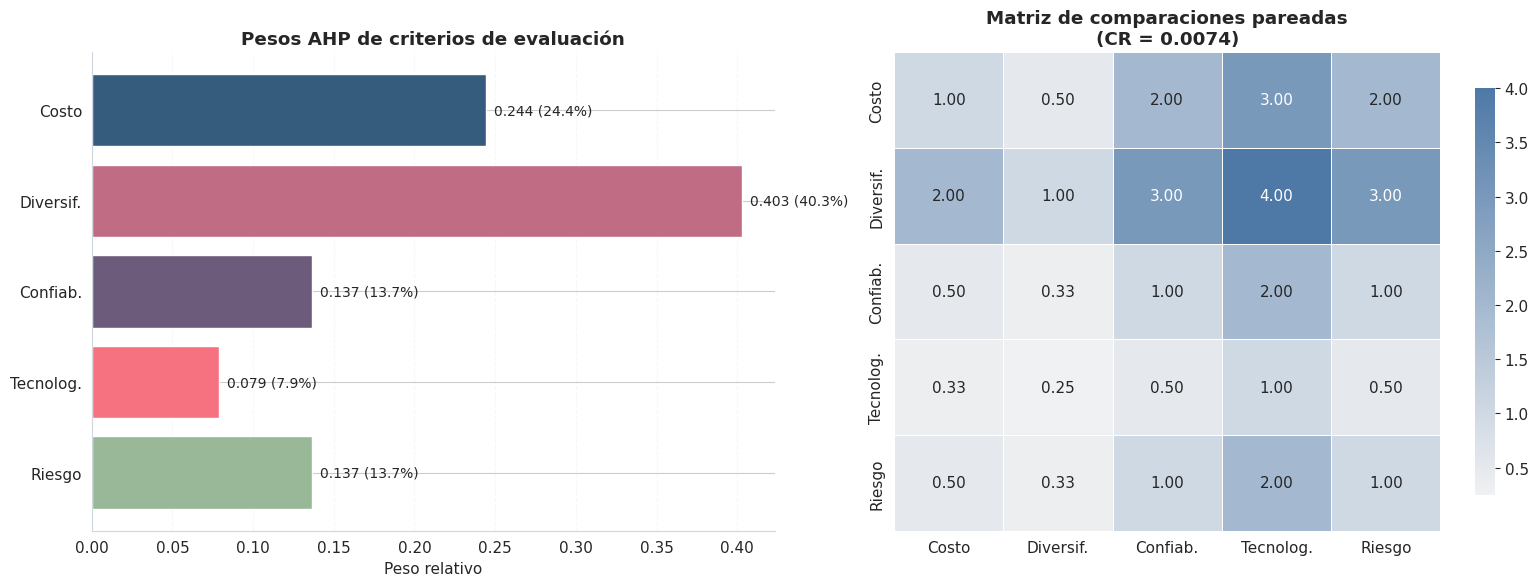

✅ Gráficas AHP guardadas en hallazgos.md


In [ ]:
# VISUALIZACIÓN AHP

# --- PALETA MÁS CLARA Y DIFERENCIADA ---
palette_ahp = [
    '#355C7D',  # azul petróleo
    '#C06C84',  # rosa vino
    '#6C5B7B',  # violeta grisáceo
    '#F67280',  # coral
    '#99B898',  # verde suave
    '#FECEAB',  # durazno
    '#8E806A',  # taupe
    '#A8A7A7',  # gris
    '#E8A87C'   # terracota
]

# --- 1. GENERACIÓN GRÁFICA ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pesos de criterios
ax1 = axes[0]

if len(criterios_cortos) <= len(palette_ahp):
    colors_ahp = palette_ahp[:len(criterios_cortos)]
else:
    colors_ahp = sns.color_palette("tab10", n_colors=len(criterios_cortos)).as_hex()

bars = ax1.barh(criterios_cortos, pesos_ahp, color=colors_ahp, edgecolor='white')
ax1.set_xlabel('Peso relativo')
ax1.set_title('Pesos AHP de criterios de evaluación', fontweight='bold')

for bar, peso in zip(bars, pesos_ahp):
    ax1.text(
        bar.get_width() + 0.005,
        bar.get_y() + bar.get_height()/2,
        f'{peso:.3f} ({peso*100:.1f}%)',
        va='center',
        fontsize=10
    )

ax1.invert_yaxis()
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#D0D7DE')
ax1.spines['bottom'].set_color('#D0D7DE')
ax1.grid(axis='x', linestyle='--', alpha=0.15)
ax1.set_axisbelow(True)

# Heatmap de la matriz
ax2 = axes[1]
sns.heatmap(
    ahp_matrix,
    annot=True,
    fmt='.2f',
    xticklabels=criterios_cortos,
    yticklabels=criterios_cortos,
    cmap=sns.light_palette("#4E79A7", as_cmap=True),  # azul claro elegante
    ax=ax2,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'shrink': 0.85}
)
ax2.set_title(f'Matriz de comparaciones pareadas\n(CR = {cr:.4f})', fontweight='bold')

plt.tight_layout()

# GUARDAR IMAGEN
nombre_img_ahp = '06_ahp_resultados.png'
plt.savefig(nombre_img_ahp, dpi=150, bbox_inches='tight')
plt.show()

# --- 2. REPORTE MD (AI-READY) ---
reporte_visual_ahp = "\n### 3.4.4 Visualización de Resultados AHP\n\n"
reporte_visual_ahp += f"![Resultados AHP]({nombre_img_ahp})\n\n"
reporte_visual_ahp += "**Análisis Visual:**\n"
reporte_visual_ahp += "- El gráfico de barras confirma la jerarquía de los criterios en el modelo.\n"
reporte_visual_ahp += f"- El Ratio de Consistencia (CR = {cr:.4f}) valida la lógica de las comparaciones.\n"

# --- 3. GUARDAR EN ARCHIVO ---
with open("hallazgos.md", "a", encoding="utf-8") as f:
    f.write(reporte_visual_ahp)

print("✅ Gráficas AHP guardadas en hallazgos.md")

In [ ]:
# --- 1. PREPARACIÓN DE LA MATRIZ DE DESEMPEÑO ---
# Usamos el DataFrame de logística que ya tenía métricas base
df_ranking = logistica_relevante.copy()

# Definimos los criterios que podemos mapear desde los datos
# 1. Costo (Inverso del Ratio CIF/FOB: menor ratio -> mayor score)
df_ranking['score_costo'] = 1 / df_ranking['ratio_cif_fob']

# 2. Diversificación (N_registros: más operaciones -> más estabilidad/presencia)
df_ranking['score_diver'] = df_ranking['n_registros']

# 3. Confiabilidad (Ratio de registros sobre total: proxy de consistencia)
df_ranking['score_confi'] = df_ranking['total_kg'] / df_ranking['total_kg'].max()

# --- 2. NORMALIZACIÓN (Escala 0 a 1) ---
# Esto permite que peras y manzanas se puedan sumar
def normalizar(col):
    return (col - col.min()) / (col.max() - col.min())

cols_to_norm = ['score_costo', 'score_diver', 'score_confi']
for col in cols_to_norm:
    df_ranking[f'{col}_norm'] = normalizar(df_ranking[col])

# --- 3. APLICACIÓN DE PESOS AHP ---
# Asignamos los pesos calculados (ajusta los índices según tu orden de criterios)
# 0: Costo, 1: Diversificación, 2: Confiabilidad
w_costo = pesos_ahp[0]
w_diver = pesos_ahp[1]
w_confi = pesos_ahp[2]

df_ranking['Score_Final'] = (
    df_ranking['score_costo_norm'] * w_costo +
    df_ranking['score_diver_norm'] * w_diver +
    df_ranking['score_confi_norm'] * w_confi
)

# Ordenar por el mejor score
df_ranking = df_ranking.sort_values('Score_Final', ascending=False)

# --- 4. REPORTE MD (AI-READY) ---
reporte_ranking = "\n## 4. Ranking de Países Estratégicos (Score AHP)\n\n"
reporte_ranking += "Este ranking integra los pesos del AHP con el desempeño real observado en el dataset:\n\n"

# Tabla Top 10 Países según el modelo
df_top_ranking = df_ranking[['Score_Final', 'total_cif', 'ratio_cif_fob']].head(10).reset_index()
df_top_ranking.columns = ['País', 'Score Final', 'Valor CIF', 'Ratio CIF/FOB']
df_top_ranking['Score Final'] = df_top_ranking['Score Final'].map('{:.4f}'.format)
df_top_ranking['Valor CIF'] = df_top_ranking['Valor CIF'].map('USD {:,.0f}'.format)

reporte_ranking += df_top_ranking.to_markdown(index=False) + "\n\n"

reporte_ranking += "> **Insight**: Los países con mayor Score Final son aquellos que equilibran un bajo costo logístico con una alta frecuencia y volumen de operación, alineándose con la prioridad de **Diversificación** del modelo.\n"

# --- 5. GUARDAR EN ARCHIVO ---
with open("hallazgos.md", "a", encoding="utf-8") as f:
    f.write(reporte_ranking)

print(f"✅ Ranking de países generado y guardado en hallazgos.md")
display(df_top_ranking)

✅ Ranking de países generado y guardado en hallazgos.md


,País,Score Final,Valor CIF,Ratio CIF/FOB
0,China,0.5650,"USD 10,610,842,742",1.067561
1,Estados Unidos,0.4969,"USD 9,700,009,322",1.060187
2,Alemania,0.3031,"USD 1,320,885,416",1.034116
3,México,0.2732,"USD 1,950,957,326",1.038230
4,Italia,0.2633,"USD 662,559,033",1.044125
5,Colombia (Zona Franca),0.2620,"USD 585,093,859",1.004889
6,Francia,0.2440,"USD 528,345,052",1.033300
7,Suiza,0.2379,"USD 337,079,017",1.021598
8,España,0.2319,"USD 727,719,282",1.059638
9,Brasil,0.2309,"USD 1,978,690,455",1.069304


## 4. Clustering de países proveedores (K-Means)

### 4.1 KMeans, cluster de proveedores

In [ ]:
# Construir perfiles de países

perfiles_pais = df_completo.groupby(pais_col).agg(
    total_cif=(cif_col, 'sum'),
    total_fob=(fob_col, 'sum'),
    total_kg=(kg_col, 'sum'),
    n_transacciones=(cif_col, 'count'),
    n_meses=(mes_col, 'nunique'),
).copy()

if capitulo_col:
    perfiles_pais['n_capitulos'] = df_completo.groupby(pais_col)[capitulo_col].nunique()
    perfiles_pais['ratio_cif_fob'] = perfiles_pais['total_cif'] / perfiles_pais['total_fob'].clip(lower=1)
    perfiles_pais['precio_kg'] = perfiles_pais['total_cif'] / perfiles_pais['total_kg'].clip(lower=1)
    perfiles_pais['participacion'] = perfiles_pais['total_cif'] / perfiles_pais['total_cif'].sum()

# Filtrar países relevantes
paises_relevantes = perfiles_pais[perfiles_pais['participacion'] > 0.0005].copy()
print(f"Países relevantes para clustering: {len(paises_relevantes)}")

# === FEATURES: Las 2 dimensiones del mapa de costos logísticos ===
# Se usa log(precio_kg) para comprimir outliers y que K-Means funcione bien
paises_relevantes['log_precio_kg'] = np.log1p(paises_relevantes['precio_kg'])
# Añadimos log_total_cif para que el algoritmo distinga Gigantes de Hormigas
paises_relevantes['log_total_cif'] = np.log1p(paises_relevantes['total_cif'])
paises_relevantes['log_n_transacciones'] = np.log1p(paises_relevantes['n_transacciones'])
features_cluster = ['ratio_cif_fob', 'log_precio_kg', 'log_total_cif', 'log_n_transacciones']

print(f"Features: {features_cluster}")
print(f"  Se usa log(precio_kg) para evitar que outliers de alto valor")
print(f"  distorsionen los clusters. Esto alinea la agrupación con")
print(f"  lo que se observa visualmente en el mapa de costos logísticos.\n")

X = paises_relevantes[features_cluster].copy()
X = X.replace([np.inf, -np.inf], np.nan).fillna(X.median())
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Selección de k
inertias = []
silhouettes = []
K_range = range(2, 6)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels)
    silhouettes.append(sil)
    print(f"  k={k}: inercia={km.inertia_:,.0f}, silhouette={sil:.3f}")

k_silhouette = list(K_range)[np.argmax(silhouettes)]

# Usar k=3 o el que silhouette sugiera, lo que produzca grupos interpretables
k_optimo = min(k_silhouette, 4)  # No más de 4 para interpretabilidad
print(f"\n  → k por silhouette: {k_silhouette} (score={max(silhouettes):.3f})")
print(f"  → k adoptado: {k_optimo}\n")

kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
paises_relevantes['cluster'] = kmeans.fit_predict(X_scaled)

# === NOMBRAR CLUSTERS AUTOMÁTICAMENTE SEGÚN PERFIL ===
cluster_names = {}
profiles_df = paises_relevantes.groupby('cluster').agg({
    'total_cif': 'mean',
    'ratio_cif_fob': 'mean',
    'n_transacciones': 'mean'
})

# === NOMBRAR CLUSTERS DE FORMA ÚNICA ===
cluster_names = {}

# 1. Identificar el cluster de los "Gigantes"
id_gigantes = profiles_df['total_cif'].idxmax()
cluster_names[id_gigantes] = 'Socios Estratégicos (Alto Volumen)'

# 2. Ordenar los demás clusters por ratio CIF/FOB (de menor a mayor)
otros_clusters = [c for c in range(k_optimo) if c != id_gigantes]
otros_clusters_sorted = sorted(otros_clusters, key=lambda c: profiles_df.loc[c, 'ratio_cif_fob'])

# 3. Asignar nombres únicos basados en el orden
for idx, c in enumerate(otros_clusters_sorted):
    r = profiles_df.loc[c, 'ratio_cif_fob']
    n = profiles_df.loc[c, 'n_transacciones']
    vol = profiles_df.loc[c, 'total_cif']

    # El más eficiente (ratio bajo)
    if idx == 0:
        cluster_names[c] = 'Proveedores Eficientes (Nicho)'
    # El menos eficiente (ratio alto) + bajo volumen
    elif idx == len(otros_clusters_sorted) - 1 and n < profiles_df['n_transacciones'].median():
        cluster_names[c] = 'Proveedores Ocasionales / Alto Costo'
    # Los del medio
    else:
        # Si tiene alto volumen pero ratio medio
        if vol > profiles_df['total_cif'].median():
            cluster_names[c] = 'Proveedores Emergentes (Medio Volumen)'
        else:
            cluster_names[c] = 'Proveedores Especializados (Bajo Volumen)'

# Mostrar perfiles
print(f"Perfiles de clusters (k={k_optimo}):")
print("-" * 70)

for c in range(k_optimo):
    paises_c = paises_relevantes[paises_relevantes['cluster'] == c]
    top = paises_c.nlargest(5, 'total_cif').index.tolist()
    print(f"\n  Cluster {c} — {cluster_names[c]}")
    print(f"    {len(paises_c)} países, {paises_c['participacion'].sum()*100:.1f}% del CIF total")
    print(f"    Ratio CIF/FOB medio: {paises_c['ratio_cif_fob'].mean():.3f}")
    print(f"    Precio/kg medio: USD {paises_c['precio_kg'].mean():.2f}")
    print(f"    Top: {', '.join(top)}")


# --- 1. PREPARACIÓN DE DATOS PARA EL REPORTE ---
reporte_clusters = "\n## 5. Segmentación Estratégica de Proveedores (Clustering)\n\n"
reporte_clusters += "Se aplicó un modelo de aprendizaje no supervisado (**K-Means**) utilizando una arquitectura de 4 dimensiones: "
reporte_clusters += "eficiencia logística, valor unitario, volumen total y frecuencia de transacciones.\n\n"

# Crear tabla resumen de clusters
resumen_clusters = []
for c in range(k_optimo):
    paises_c = paises_relevantes[paises_relevantes['cluster'] == c]
    top_paises = ", ".join(paises_c.nlargest(3, 'total_cif').index.tolist())

    resumen_clusters.append({
        'Cluster': c,
        'Nombre Estratégico': cluster_names[c],
        'N° Países': len(paises_c),
        'Participación %': f"{paises_c['participacion'].sum()*100:.1f}%",
        'Ratio Medio': f"{paises_c['ratio_cif_fob'].mean():.3f}",
        'Top Exponentes': top_paises
    })

df_resumen_clusters = pd.DataFrame(resumen_clusters)

# --- 2. REPORTE MD ---
reporte_clusters += "### 5.1 Perfiles de Abastecimiento Identificados\n"
reporte_clusters += df_resumen_clusters.to_markdown(index=False) + "\n\n"

reporte_clusters += "### 5.2 Interpretación de Segmentos\n"
for c in range(k_optimo):
    nombre = cluster_names[c]
    if 'Estratégicos' in nombre:
        reporte_clusters += f"- **{nombre}**: Representan la columna vertebral del suministro. Alta dependencia y alta eficiencia operativa.\n"
    elif 'Ocasionales' in nombre:
        reporte_clusters += f"- **{nombre}**: Rutas con costos logísticos elevados o envíos esporádicos. Candidatos a revisión de fletes.\n"
    elif 'Nicho' in nombre:
        reporte_clusters += f"- **{nombre}**: Proveedores con balances logísticos óptimos en categorías específicas.\n"
    else:
        reporte_clusters += f"- **{nombre}**: Países con flujo constante pero volumen moderado.\n"

reporte_clusters += "\n> **Nota Técnica**: El uso de logaritmos en las variables de volumen permitió capturar la importancia de los grandes socios sin que los outliers desestabilizaran el modelo.\n"

# --- 3. GUARDAR EN ARCHIVO ---
with open("hallazgos.md", "a", encoding="utf-8") as f:
    f.write(reporte_clusters)

print(f"✅ Segmentación de {len(paises_relevantes)} países guardada en hallazgos.md")

Países relevantes para clustering: 67
Features: ['ratio_cif_fob', 'log_precio_kg', 'log_total_cif', 'log_n_transacciones']
  Se usa log(precio_kg) para evitar que outliers de alto valor
  distorsionen los clusters. Esto alinea la agrupación con
  lo que se observa visualmente en el mapa de costos logísticos.

  k=2: inercia=185, silhouette=0.315
  k=3: inercia=130, silhouette=0.350
  k=4: inercia=88, silhouette=0.355
  k=5: inercia=74, silhouette=0.280

  → k por silhouette: 4 (score=0.355)
  → k adoptado: 4

Perfiles de clusters (k=4):
----------------------------------------------------------------------

  Cluster 0 — Socios Estratégicos (Alto Volumen)
    24 países, 89.6% del CIF total
    Ratio CIF/FOB medio: 1.056
    Precio/kg medio: USD 3.10
    Top: China, Estados Unidos, Brasil, México, Alemania

  Cluster 1 — Proveedores Eficientes (Nicho)
    25 países, 5.8% del CIF total
    Ratio CIF/FOB medio: 1.042
    Precio/kg medio: USD 16.52
    Top: Suiza, Reino Unido, Irlanda, Sue

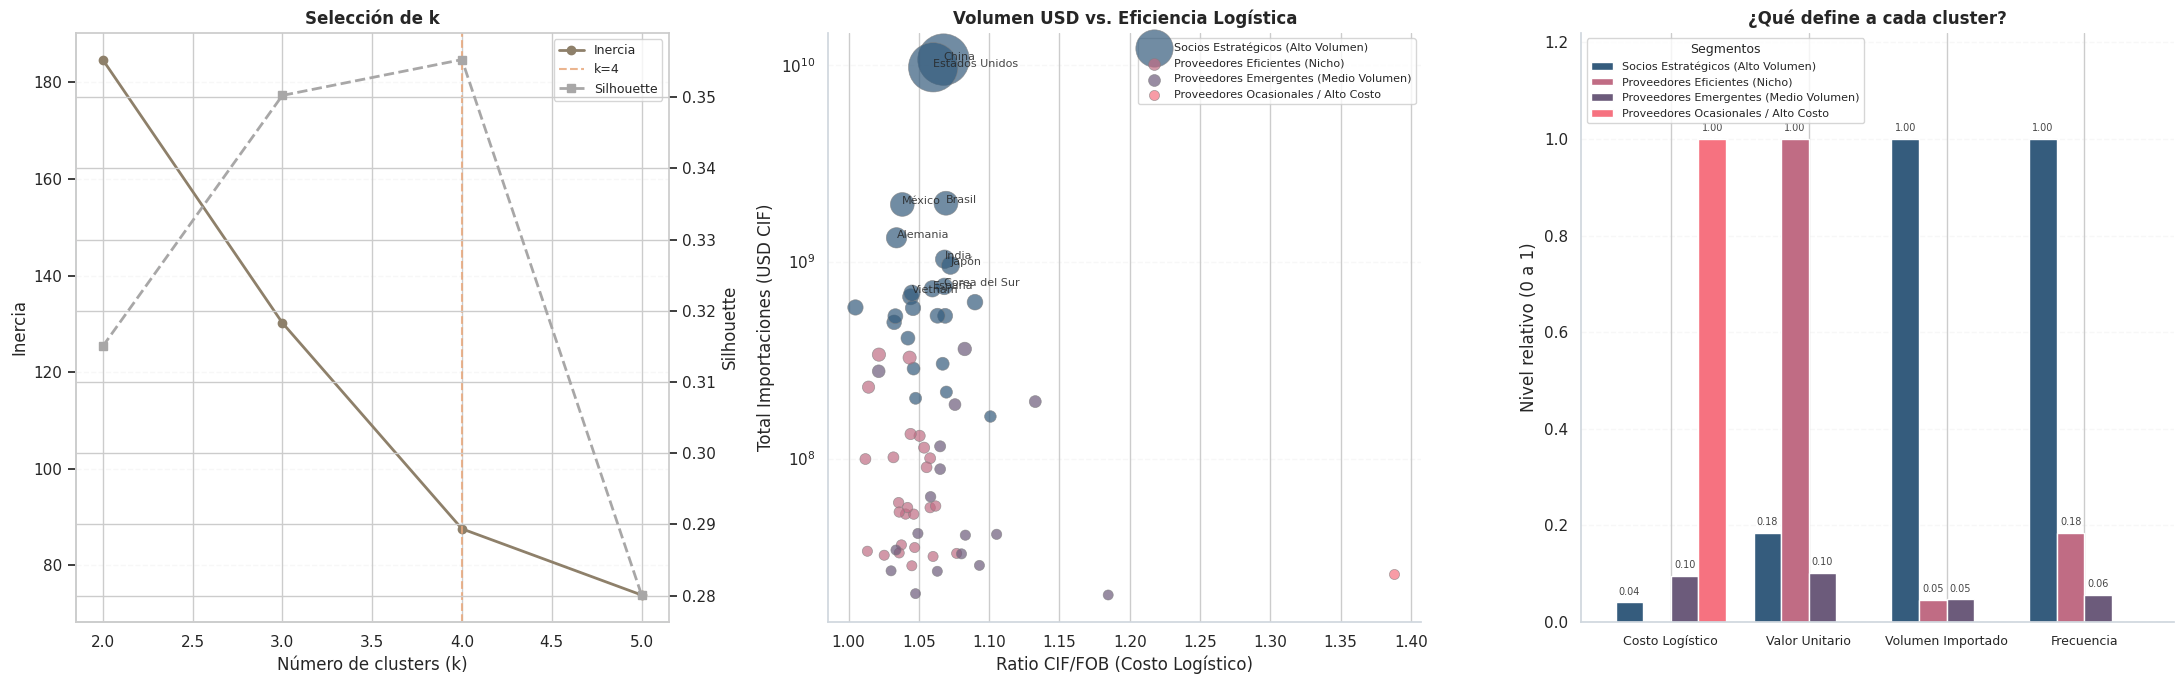

✅ Gráficos generados y guardados en hallazgos.md.


In [ ]:
# --- CONFIGURACIÓN BÁSICA DE GRÁFICOS ---
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# PALETA CATEGÓRICA CLARA Y DISTINTA
cluster_palette = [
    '#355C7D',  # azul petróleo
    '#C06C84',  # rosa vino
    '#6C5B7B',  # violeta grisáceo
    '#F67280',  # coral
    '#99B898',  # verde suave
    '#FECEAB',  # durazno
    '#8E806A',  # taupe
    '#A8A7A7',  # gris
    '#E8A87C'   # terracota
]

if k_optimo <= len(cluster_palette):
    colores_clusters = cluster_palette[:k_optimo]
else:
    colores_clusters = sns.color_palette("tab10", n_colors=k_optimo).as_hex()

COLOR_INERCIA = '#8E806A'
COLOR_SILHOUETTE = '#A8A7A7'
COLOR_KOPTIMO = '#E8A87C'

# Diccionario para asegurar consistencia visual por cluster
cluster_ids = sorted(paises_relevantes['cluster'].unique())
cluster_color_map = {cid: colores_clusters[i] for i, cid in enumerate(cluster_ids)}

# 1. SELECCIÓN DE K
ax1 = axes[0]
ax1_twin = ax1.twinx()

ax1.plot(list(K_range), inertias, 'o-', color=COLOR_INERCIA, linewidth=2, label='Inercia')
ax1_twin.plot(list(K_range), silhouettes, 's--', color=COLOR_SILHOUETTE, linewidth=2, label='Silhouette')
ax1.axvline(x=k_optimo, color=COLOR_KOPTIMO, linestyle='--', alpha=0.85, label=f'k={k_optimo}')

ax1.set_title('Selección de k', fontweight='bold')
ax1.set_xlabel('Número de clusters (k)')
ax1.set_ylabel('Inercia')
ax1_twin.set_ylabel('Silhouette')

# Leyenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)

# 2. SCATTER PLOT: TOTAL IMPORTACIONES USD vs RATIO
ax2 = axes[1]
for c in cluster_ids:
    mask = paises_relevantes['cluster'] == c
    nombre = cluster_names.get(c, f'Cluster {c}')

    ax2.scatter(
        paises_relevantes.loc[mask, 'ratio_cif_fob'],
        paises_relevantes.loc[mask, 'total_cif'],
        s=paises_relevantes.loc[mask, 'participacion'] * 5000 + 50,
        alpha=0.70,
        label=nombre,
        color=cluster_color_map[c],
        edgecolors='gray',
        linewidth=0.5
    )

for pais in paises_relevantes.nlargest(10, 'total_cif').index:
    row = paises_relevantes.loc[pais]
    ax2.annotate(
        pais,
        (row['ratio_cif_fob'], row['total_cif']),
        fontsize=8,
        alpha=0.85
    )

ax2.set_yscale('log')
ax2.set_xlabel('Ratio CIF/FOB (Costo Logístico)')
ax2.set_ylabel('Total Importaciones (USD CIF)')
ax2.set_title('Volumen USD vs. Eficiencia Logística', fontweight='bold')
ax2.legend(fontsize=8, loc='best')

# 3. PERFIL PROMEDIO (BARRAS AGRUPADAS POR DIMENSIÓN)
ax3 = axes[2]

features_plot = ['ratio_cif_fob', 'precio_kg', 'total_cif', 'n_transacciones']
df_perfiles = paises_relevantes.groupby('cluster')[features_plot].mean()

df_norm = (df_perfiles - df_perfiles.min()) / (df_perfiles.max() - df_perfiles.min())
df_norm.index = [cluster_names.get(i, f'Cluster {i}') for i in df_norm.index]
df_norm.columns = ['Costo Logístico', 'Valor Unitario', 'Volumen Importado', 'Frecuencia']

# Usamos exactamente los mismos colores de clusters
colores_perfil = [cluster_color_map[c] for c in sorted(df_perfiles.index)]

df_norm.T.plot(
    kind='bar',
    ax=ax3,
    width=0.8,
    color=colores_perfil,
    edgecolor='white'
)

ax3.set_title('¿Qué define a cada cluster?', fontweight='bold')
ax3.set_ylabel('Nivel relativo (0 a 1)')
ax3.set_xlabel('')
ax3.set_xticklabels(df_norm.columns, rotation=0, fontsize=9)
ax3.legend(title="Segmentos", fontsize=8, title_fontsize=9, loc='upper left')
ax3.set_ylim(0, 1.22)

for p in ax3.patches:
    altura = p.get_height()
    if pd.notna(altura) and altura > 0:
        ax3.annotate(
            f'{altura:.2f}',
            (p.get_x() + p.get_width() / 2., altura),
            ha='center',
            va='bottom',
            xytext=(0, 4),
            textcoords='offset points',
            fontsize=7,
            alpha=0.85
        )

# Estilo general
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#D0D7DE')
    ax.spines['bottom'].set_color('#D0D7DE')
    ax.grid(axis='y', linestyle='--', alpha=0.15)
    ax.set_axisbelow(True)

plt.tight_layout()
nombre_img_cluster = '07_clustering_paises.png'
plt.savefig(nombre_img_cluster, dpi=150, bbox_inches='tight')
plt.show()

# --- ACTUALIZACIÓN MD ---
with open("hallazgos.md", "a", encoding="utf-8") as f:
    f.write(f"\n### 5.3 Análisis de Segmentación\n\n")
    f.write(f"![Gráficos de Clustering]({nombre_img_cluster})\n\n")

print("✅ Gráficos generados y guardados en hallazgos.md.")

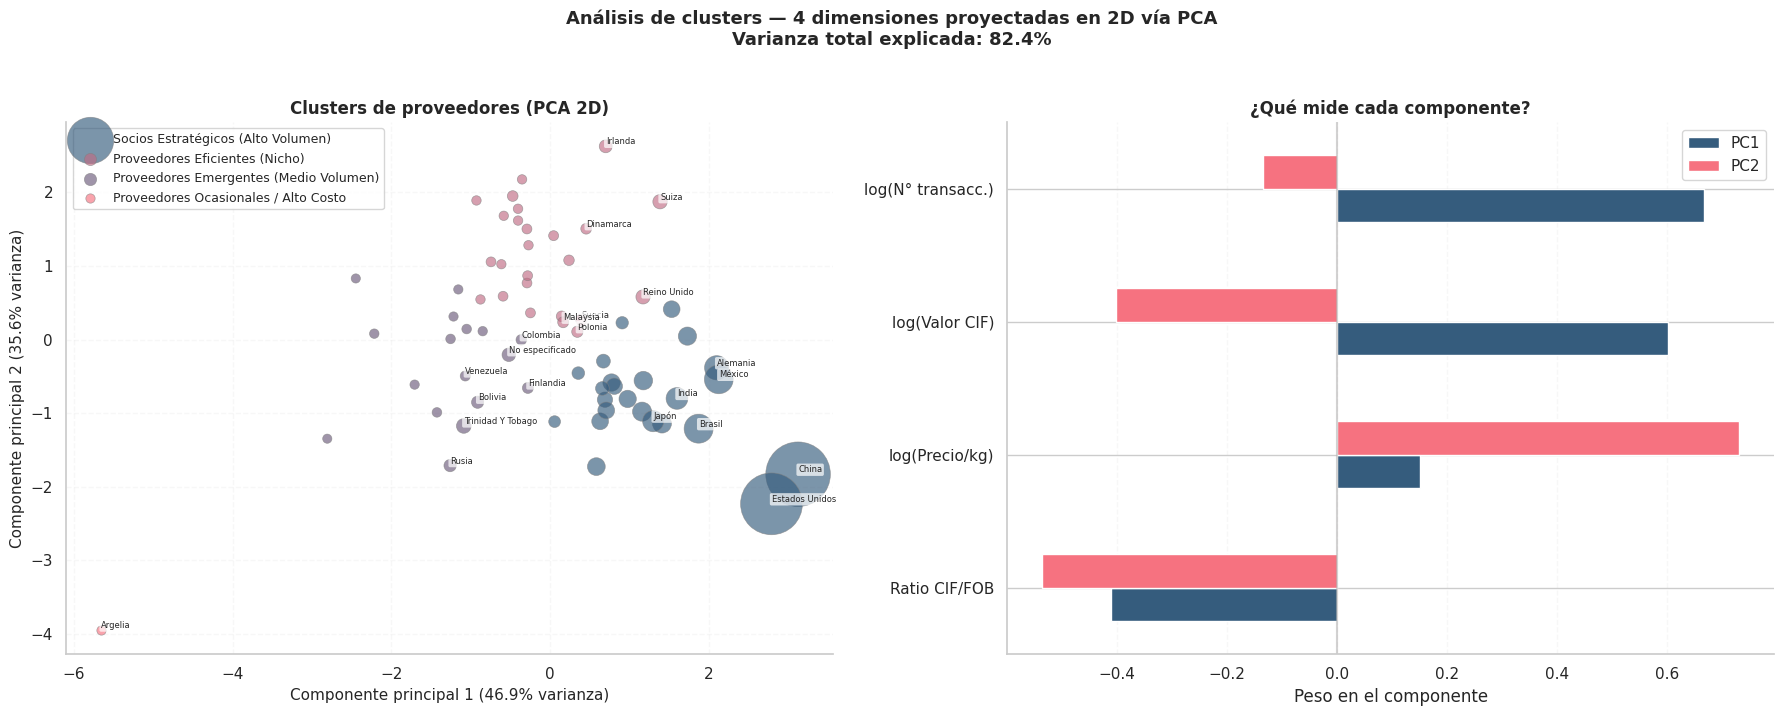

✅ Análisis PCA guardado en hallazgos.md


In [ ]:
# VISUALIZACIÓN DE CLUSTERS — Reducción PCA a 2D

# --- PALETA AJUSTADA ---
palette_elegante = [
    '#355C7D',  # azul petróleo
    '#C06C84',  # rosa vino
    '#6C5B7B',  # violeta grisáceo
    '#F67280',  # coral
    '#99B898',  # verde suave
    '#FECEAB',  # durazno
    '#8E806A',  # taupe
    '#A8A7A7',  # gris
    '#E8A87C'   # terracota
]

# 1. CÁLCULO DE PCA
pca = PCA(n_components=2)
coords_2d = pca.fit_transform(X_scaled)
paises_relevantes['pca1'] = coords_2d[:, 0]
paises_relevantes['pca2'] = coords_2d[:, 1]
var_explicada = pca.explained_variance_ratio_

# --- CONFIGURACIÓN DE COLORES AJUSTADA ---
# Mantener la lógica: un color por cluster
colores_pca = [palette_elegante[i % len(palette_elegante)] for i in range(k_optimo)]

# Mantener la lógica original: dos colores contrastantes para loadings
colores_loadings = [colores_pca[0], colores_pca[-1]]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Panel 1: Clusters en espacio PCA ---
ax1 = axes[0]
for c in range(k_optimo):
    mask = paises_relevantes['cluster'] == c
    ax1.scatter(
        paises_relevantes.loc[mask, 'pca1'],
        paises_relevantes.loc[mask, 'pca2'],
        s=paises_relevantes.loc[mask, 'participacion'] * 8000 + 40,
        alpha=0.65,
        label=cluster_names.get(c, f'Cluster {c}'),
        color=colores_pca[c],
        edgecolors='gray',
        linewidth=0.5
    )

# Etiquetar top 10 países por cluster
for c in range(k_optimo):
    top_paises_cluster = (
        paises_relevantes[paises_relevantes['cluster'] == c]
        .nlargest(7, 'total_cif')
    )

    for pais, row in top_paises_cluster.iterrows():
        ax1.annotate(
            pais,
            (row['pca1'], row['pca2']),
            fontsize=6,
            ha='left',
            va='bottom',
            bbox=dict(
                boxstyle='round,pad=0.2',
                facecolor='white',
                alpha=0.7,
                edgecolor='none'
            )
        )

ax1.set_xlabel(f'Componente principal 1 ({var_explicada[0]*100:.1f}% varianza)', fontsize=11)
ax1.set_ylabel(f'Componente principal 2 ({var_explicada[1]*100:.1f}% varianza)', fontsize=11)
ax1.set_title('Clusters de proveedores (PCA 2D)', fontweight='bold')
ax1.legend(fontsize=9, loc='best')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(True, linestyle='--', alpha=0.15)
ax1.set_axisbelow(True)

# --- Panel 2: Composición de los componentes principales ---
ax2 = axes[1]
features_labels = ['Ratio CIF/FOB', 'log(Precio/kg)', 'log(Valor CIF)', 'log(N° transacc.)']

loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=features_labels[:len(features_cluster)]
)

loadings.plot(kind='barh', ax=ax2, color=colores_loadings)
ax2.set_xlabel('Peso en el componente')
ax2.set_title('¿Qué mide cada componente?', fontweight='bold')
ax2.axvline(x=0, color='#A8A7A7', linestyle='-', alpha=0.5)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='x', linestyle='--', alpha=0.15)
ax2.set_axisbelow(True)

plt.suptitle(
    f'Análisis de clusters — {len(features_cluster)} dimensiones proyectadas en 2D vía PCA\n'
    f'Varianza total explicada: {sum(var_explicada)*100:.1f}%',
    fontsize=13,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
nombre_img_pca = '07_clustering_pca.png'
plt.savefig(nombre_img_pca, dpi=150, bbox_inches='tight')
plt.show()

# --- 2. ACTUALIZACIÓN AUTOMÁTICA DEL MD ---
reporte_pca = "\n### 5.5 Validación Matemática de Segmentos (PCA)\n\n"
reporte_pca += "Para validar la separación de los clusters, se realizó una Reducción de Dimensionalidad (PCA). "
reporte_pca += f"Los dos primeros componentes explican el **{sum(var_explicada)*100:.1f}%** de la varianza total de los datos.\n\n"
reporte_pca += f"![Análisis PCA]({nombre_img_pca})\n\n"
reporte_pca += "**Interpretación de Componentes:**\n"
reporte_pca += "- El **PC1** está fuertemente influenciado por el volumen y frecuencia (separa a los Gigantes).\n"
reporte_pca += "- El **PC2** captura principalmente la eficiencia logística y el valor unitario.\n"

with open("hallazgos.md", "a", encoding="utf-8") as f:
    f.write(reporte_pca)

print("✅ Análisis PCA guardado en hallazgos.md")

In [ ]:
df_completo_con_clusters = df_completo.copy()

# Crear un mapeo de país a cluster_id y luego a nombre_cluster
cluster_mapping_df = paises_relevantes[['cluster']].reset_index()
cluster_mapping_df['cluster_nombre'] = cluster_mapping_df['cluster'].map(cluster_names)

# Merge correcto: guardar el resultado en df_completo_con_clusters
df_completo_con_clusters = df_completo_con_clusters.merge(
    cluster_mapping_df[['pais', 'cluster', 'cluster_nombre']],
    on='pais',
    how='left'
)

# Asignar 'No clasificado' a los países que no estaban en paises_relevantes
df_completo_con_clusters['cluster_perfil'] = (
    df_completo_con_clusters['cluster_nombre']
    .fillna('No clasificado')
)

# Opcional: eliminar columna auxiliar
df_completo_con_clusters = df_completo_con_clusters.drop(columns=['cluster_nombre'])

print("Primeros registros de df_completo_con_clusters con la nueva columna 'cluster_perfil':")
display(df_completo_con_clusters.head())

print(f"Valores únicos en 'cluster_perfil': {df_completo_con_clusters['cluster_perfil'].nunique()} categorías")
print(df_completo_con_clusters['cluster_perfil'].value_counts())


Primeros registros de df_completo_con_clusters con la nueva columna 'cluster_perfil':


,periodo,mes,cod_pais,pais,cod_partida,nombre_partida,cod_ciiu,descripcion_ciiu,cod_capitulo,nombre_capitulo,nivel_tecnologico,uso_economico,detalle_uso,dolares_cif,dolares_fob,kg_netos,cantidad,pais_original,cluster,cluster_perfil
0,2025,1,23,Alemania,1210,"Conos de lúpul o frescos o secos, incluso trit...",128,Cultivo de especias y de plantas aromáticas y ...,12,"Semillas y frutos oleaginosos, forrajes",Bienes primarios,Materias primas,Productos alimenticios,4533.66,3740.45,220.0,220.0,Alemania,0.0,Socios Estratégicos (Alto Volumen)
1,2025,1,23,Alemania,1901,Extracto de malta; preparaciones alimenticias ...,1051,Elaboración de productos de molinería,19,"Preparaciones a base de cereal, harina, leche;...",Manufacturas basadas en recursos naturales,Bienes de consumo,Alimentos,2777.71,1676.31,300.0,300.0,Alemania,0.0,Socios Estratégicos (Alto Volumen)
2,2025,1,23,Alemania,1901,Extracto de malta; preparaciones alimenticias ...,1089,Elaboración de otros productos alimenticios n....,19,"Preparaciones a base de cereal, harina, leche;...",Manufacturas basadas en recursos naturales,Bienes de consumo,Alimentos,1590.58,1515.15,900.0,900.0,Alemania,0.0,Socios Estratégicos (Alto Volumen)
3,2025,1,23,Alemania,1904,Productos a base de cereales obtenidos por inf...,1051,Elaboración de productos de molinería,19,"Preparaciones a base de cereal, harina, leche;...",Manufacturas basadas en recursos naturales,Bienes de consumo,Alimentos,63574.89,58228.64,18096.0,18096.0,Alemania,0.0,Socios Estratégicos (Alto Volumen)
4,2025,1,23,Alemania,2106,Preparaciones alimenticias no expresadas ni co...,1089,Elaboración de otros productos alimenticios n....,21,Preparaciones alimenticias diversas,Manufacturas basadas en recursos naturales,Bienes de consumo,Alimentos,15327.32,14971.44,1820.0,1820.0,Alemania,0.0,Socios Estratégicos (Alto Volumen)


Valores únicos en 'cluster_perfil': 5 categorías
cluster_perfil
Socios Estratégicos (Alto Volumen)        187173
Proveedores Eficientes (Nicho)             36240
Proveedores Emergentes (Medio Volumen)      7661
No clasificado                              7217
Proveedores Ocasionales / Alto Costo          14
Name: count, dtype: int64


## 5. Optimización - Redistribución del Cluster de Socios Estratégicos

### 5.1 Planteamiento del problema

El análisis de clusters (sección 3.3) identificó que el **Cluster "Socios Estratégicos
(Alto Volumen)"** concentra aproximadamente el 90% del valor CIF importado por Bogotá.
El cluster identificado por K-Means incluye 24 países, pero se excluye metodológicamente
a **Colombia (Zona Franca)** porque no representa suministro internacional real (territorio
aduanero nacional). El modelo opera entonces sobre **23 países proveedores internacionales**.

El verdadero problema estratégico no es diversificar entre los 189 países registrados
—ya que muchos son marginales— sino **redistribuir eficientemente dentro de este cluster
crítico**, donde viven China, Estados Unidos y otros 21 socios relevantes.

La decisión a tomar es: dada la canasta de socios estratégicos, ¿cuál es la
**asignación óptima que minimiza el costo logístico total** considerando (a) los
costos observados, (b) el riesgo geopolítico derivado del AHP, (c) los costos
de transición respecto al portafolio actual, y (d) la política comercial (TLC)?

### Conjuntos

$I$ &nbsp;&nbsp; Países proveedores internacionales del Cluster "Socios Estratégicos", con $|I| = 23$

$T \subseteq I$ &nbsp;&nbsp; Subconjunto de países con TLC vigente con Colombia

### Parámetros

$c_i$ &nbsp;&nbsp; Costo logístico unitario del país $i$ (ratio CIF/FOB observado)

$r_i$ &nbsp;&nbsp; Score de riesgo geopolítico del país $i$ (derivado del AHP, escala 0–10)

$a_i$ &nbsp;&nbsp; Participación actual del país $i$ en el cluster

$\tau$ &nbsp;&nbsp; Costo de transición por unidad de cambio

$R_{max}$ &nbsp;&nbsp; Presupuesto máximo de riesgo ponderado del portafolio

$\bar{x}$, $\underline{x}$ &nbsp;&nbsp; Cotas máxima y mínima de participación por país

$L_{TLC}$ &nbsp;&nbsp; Mínimo desde socios con TLC

### Tabla 1 — Parámetros por país

Los valores exactos de $c_i$, $a_i$, $r_i$ y pertenencia a TLC se construyen
dinámicamente en la celda siguiente a partir del EDA, el clustering y el AHP.
La tabla impresa por el código representa los valores reales del dataset
(enero–julio 2025). Los scores $r_i$ son calibrados de manera didactica para el ejercicio consultando Global Risk Index 2024 (WEF), Economic Complexity Index (Harvard) y antecedentes
de tensiones comerciales documentadas.

### Tabla 2 — Parámetros globales del modelo

| Parámetro | Símbolo | Valor | Justificación |
|:---|:---:|:---:|:---|
| Participación mínima por país    | $\underline{x}$ | 0.005 (0.5%)  | Evita exclusión total de socios; factible con 24 países |
| Participación máxima por país    | $\bar{x}$       | 0.25 (25%)    | Política anti-concentración derivada del AHP |
| Mínimo desde socios con TLC      | $L_{TLC}$       | 0.40 (40%)    | Aprovechar preferencias arancelarias vigentes |
| Costo de transición              | $\tau$          | 0.048         | Calibrado al rango de $c_i$ para frenar saltos extremos |
| Presupuesto de riesgo (permisivo)| $R_{max}^{P}$   | $R_{actual}$  | Mantiene el nivel de riesgo actual del cluster |
| Presupuesto de riesgo (moderado) | $R_{max}^{M}$   | $0.85 \cdot R_{actual}$ | Reducción del 15% — escenario recomendado |
| Presupuesto de riesgo (estricto) | $R_{max}^{E}$   | $0.70 \cdot R_{actual}$ | Reducción del 30% — postura conservadora |

### Tabla 3 — Justificación de los scores de riesgo geopolítico $r_i$

| Nivel | Rango | Criterios | Ejemplos |
|:---:|:---:|:---|:---|
| Muy alto | 8.0 – 10.0 | Tensiones activas, conflictos comerciales, sanciones | China (8.5), Rusia |
| Alto     | 6.0 – 7.9  | Volatilidad política, controles exportación          | India (6.0), Turquía (6.5) |
| Medio    | 4.5 – 5.9  | Política cambiante, aranceles variables              | EE.UU. (5.0), Vietnam (5.5) |
| Bajo     | 3.0 – 4.4  | Socio estable, TLC vigente                           | Alemania (3.0), Japón (3.5) |
| Muy bajo | < 3.0      | Máxima estabilidad política y comercial              | Suiza (2.5) |

### Variables de decisión

$x_i \geq 0$ &nbsp;&nbsp; Proporción del cluster asignada al país $i$

$\delta_i^+ \geq 0$ &nbsp;&nbsp; Incremento respecto a la participación actual $a_i$

$\delta_i^- \geq 0$ &nbsp;&nbsp; Reducción respecto a la participación actual $a_i$

### Función objetivo

$$\text{Min } Z = \sum_{i \in I} c_i \cdot x_i \;+\; \tau \cdot \sum_{i \in I} (\delta_i^+ + \delta_i^-)$$

El primer término captura el costo logístico ponderado. El segundo término penaliza
los cambios abruptos respecto al portafolio actual, reflejando que modificar la
base de proveedores tiene costos reales (renegociación de contratos, certificaciones,
adecuación logística).

### Sujeto a

$\sum_{i \in I} x_i = 1$ &nbsp;&nbsp; (R1 — Asignación completa del cluster)

$x_i - a_i = \delta_i^+ - \delta_i^- \quad \forall i \in I$ &nbsp;&nbsp; (R2 — Balance de transición)

$\sum_{i \in I} r_i \cdot x_i \leq R_{max}$ &nbsp;&nbsp; (R3 — Presupuesto de riesgo)

$\sum_{i \in T} x_i \geq L_{TLC}$ &nbsp;&nbsp; (R4 — Política comercial)

$\underline{x} \leq x_i \leq \bar{x} \quad \forall i \in I$ &nbsp;&nbsp; (R5 — Cotas por país)

$x_i \geq 0, \; \delta_i^+ \geq 0, \; \delta_i^- \geq 0 \quad \forall i \in I$ &nbsp;&nbsp; (R6 — No negatividad)

### Cómo se conecta con el análisis previo

- **Clustering K-Means** (sección 4) → define el conjunto $I$ (24 países del Cluster 0)
- **AHP** (sección 3.2) → alimenta los scores $r_i$ del presupuesto de riesgo
- **EDA** (sección 2) → proporciona los parámetros $c_i$ (ratios CIF/FOB) y $a_i$ (participaciones actuales)


In [ ]:
# Cluster objetivo
cluster_objetivo = 'Socios Estratégicos (Alto Volumen)'

# Países que pertenecen a ese cluster
paises_cluster = (
    df_completo_con_clusters.loc[
        df_completo_con_clusters['cluster_perfil'] == cluster_objetivo,
        pais_col
    ]
    .dropna()
    .drop_duplicates()
    .tolist()
)

# Parámetros SOLO para esos países
costo_unitario = {}
cif_actual = {}

for pais in paises_cluster:
    datos_pais = df_completo[df_completo[pais_col] == pais]
    cif_actual[pais] = datos_pais[cif_col].sum()

    total_fob_pais = datos_pais[fob_col].sum()
    costo_unitario[pais] = (
        datos_pais[cif_col].sum() / total_fob_pais
        if total_fob_pais > 0 else ratio_cif_fob_medio
    )

# El modelo ahora solo tendrá esos países
paises_modelo = paises_cluster

# OJO: la demanda total debe ser la del cluster, no la global
demanda_total = sum(cif_actual.values())

print(f"Modelo con {len(paises_modelo)} variables de decisión")
print(f"Cluster objetivo: {cluster_objetivo}")
print(f"Demanda total del cluster: USD {demanda_total/1e6:,.1f} millones")

print(f"\nAsignación actual (solo países del cluster):")
for p in paises_modelo:
    pct = cif_actual[p] / demanda_total * 100
    print(f"  {p:35s} USD {cif_actual[p]/1e6:>10,.1f}M  ({pct:5.2f}%)  costo: {costo_unitario[p]:.4f}")

Modelo con 24 variables de decisión
Cluster objetivo: Socios Estratégicos (Alto Volumen)
Demanda total del cluster: USD 35,828.7 millones

Asignación actual (solo países del cluster):
  Alemania                            USD    1,320.9M  ( 3.69%)  costo: 1.0341
  Argentina                           USD      530.5M  ( 1.48%)  costo: 1.0687
  Bélgica                             USD      408.7M  ( 1.14%)  costo: 1.0423
  Brasil                              USD    1,978.7M  ( 5.52%)  costo: 1.0693
  Canadá                              USD      622.3M  ( 1.74%)  costo: 1.0899
  Corea del Sur                       USD      748.3M  ( 2.09%)  costo: 1.0681
  Chile                               USD      531.0M  ( 1.48%)  costo: 1.0633
  China                               USD   10,610.8M  (29.62%)  costo: 1.0676
  Taiwán                              USD      202.3M  ( 0.56%)  costo: 1.0477
  Ecuador                             USD      491.5M  ( 1.37%)  costo: 1.0324
  España                  

In [ ]:
# ── EXCLUSIÓN METODOLÓGICA DE COLOMBIA (ZONA FRANCA) ─────────
# Colombia (Zona Franca) tiene el ratio CIF/FOB más bajo del portafolio
# (1.005) porque las zonas francas son territorio aduanero colombiano —
# no son proveedores internacionales. Incluirla en el modelo de
# diversificación geopolítica inflaría artificialmente la mejora al
# asignarle hasta 22% del portafolio, sin que eso represente una
# reducción real del riesgo de suministro externo.
#
# Decisión: se excluye del conjunto I con justificación metodológica.

paises_excluir = ['Colombia (Zona Franca)']
paises_modelo  = [p for p in paises_cluster if p not in paises_excluir]

# Recalcular parámetros solo sobre los países restantes
demanda_total = sum(cif_actual[p] for p in paises_modelo)
a = {p: cif_actual[p] / demanda_total for p in paises_modelo}

print(f"Países excluidos del modelo: {paises_excluir}")
print(f"Justificación: no representan suministro internacional real.")
print(f"Modelo final: {len(paises_modelo)} países | "
      f"Demanda ajustada: USD {demanda_total/1e6:,.1f}M\n")

# Verificar que las participaciones sumen 1
assert abs(sum(a.values()) - 1.0) < 1e-9, "Las participaciones no suman 1"
print("✓ Participaciones normalizadas correctamente")

Países excluidos del modelo: ['Colombia (Zona Franca)']
Justificación: no representan suministro internacional real.
Modelo final: 23 países | Demanda ajustada: USD 35,243.6M

✓ Participaciones normalizadas correctamente


In [ ]:
# ============================================================
# 5. OPTIMIZACIÓN — REDISTRIBUCIÓN DEL CLUSTER DE SOCIOS
#    ESTRATÉGICOS DE ALTO VOLUMEN
# ============================================================

# ── CONJUNTOS (del resultado real del K-Means) ──────────────
I = paises_modelo   # 24 países del cluster — ya viene filtrado del bloque previo
n = len(I)
print(f"Conjunto I (Cluster 0): {n} países\n")

# Conjunto T: países con TLC vigente
tlc_colombia = ['Estados Unidos', 'México', 'Brasil', 'Alemania', 'España',
                'Italia', 'Francia', 'Chile', 'Perú', 'Corea del Sur',
                'Canadá', 'Suiza', 'Países Bajos', 'Bélgica', 'Reino Unido']
T = [p for p in I if p in tlc_colombia]
print(f"Conjunto T (con TLC): {len(T)} países")
print(f"   {T}\n")


# ── PARÁMETROS ───────────────────────────────────────────────

# c_i: costo logístico (ya viene calculado en cells previas)
c = {p: costo_unitario[p] for p in I}

# a_i: participación actual en el cluster
a = {p: cif_actual[p] / demanda_total for p in I}

# r_i: score de riesgo geopolítico (derivado del AHP, escala 0-10)
# Países no listados reciben score neutral de 5.0
scores_riesgo = {
    'China': 8.5, 'Rusia': 9.0, 'Irán': 9.5,
    'Estados Unidos': 5.0, 'México': 4.5, 'Brasil': 4.0,
    'Alemania': 3.0, 'Francia': 3.0, 'Italia': 3.5, 'España': 3.0,
    'Reino Unido': 3.5, 'Países Bajos': 3.0, 'Bélgica': 3.0, 'Suiza': 2.5,
    'India': 6.0, 'Japón': 3.5, 'Corea del Sur': 4.0, 'Vietnam': 5.5,
    'Tailandia': 5.0, 'Indonesia': 5.5, 'Turquía': 6.5,
    'Canadá': 3.0, 'Chile': 3.5, 'Perú': 4.0, 'Argentina': 6.0,
    'Colombia (Zona Franca)': 4.0, 'Ecuador': 5.0, 'Panamá': 4.5
}
r = {p: scores_riesgo.get(p, 5.0) for p in I}

# Parámetros de diseño del modelo
tau   = 0.048   # Costo de transición calibrado al rango de c_i
x_min = 0.005   # Mínimo 0.5% por país
x_max = 0.25    # Máximo 25% por país
L_tlc = 0.40    # Mínimo 40% desde TLC

# R_max: presupuesto de riesgo = nivel actual × 0.85 (reducir 15%)
R_actual = sum(r[p] * a[p] for p in I)
R_max    = R_actual * 0.85

print(f"Riesgo ponderado actual del cluster: {R_actual:.3f}")
print(f"Presupuesto de riesgo R_max:         {R_max:.3f} (reducción 15%)\n")


# ============================================================
# 5.1 MODELO BASE
# ============================================================

prob = LpProblem("Redistribucion_Cluster_Estrategico", LpMinimize)

# Variables de decisión
x       = LpVariable.dicts("x",       I, lowBound=x_min, upBound=x_max)
delta_p = LpVariable.dicts("delta_p", I, lowBound=0)
delta_n = LpVariable.dicts("delta_n", I, lowBound=0)

# Función objetivo: minimizar costo logístico + costo de transición
prob += (lpSum([c[i] * x[i] for i in I]) +
         tau * lpSum([delta_p[i] + delta_n[i] for i in I]))

# Restricciones
# R1: Asignación completa
prob += lpSum([x[i] for i in I]) == 1, "R1_Suma"

# R2: Balance de transición (dos variables por país)
for i in I:
    nombre = i.replace(' ','_').replace('(','').replace(')','')
    prob += x[i] - a[i] == delta_p[i] - delta_n[i], f"R2_{nombre}"

# R3: Presupuesto de riesgo
prob += lpSum([r[i] * x[i] for i in I]) <= R_max, "R3_Riesgo"

# R4: Mínimo TLC
if T:
    prob += lpSum([x[i] for i in T]) >= L_tlc, "R4_TLC"

status = prob.solve(PULP_CBC_CMD(msg=0))
print(f"Status: {LpStatus[status]}\n")

# ── RESULTADOS ──────────────────────────────────────────────
sol          = {i: pulp.value(x[i]) for i in I}
costo_log    = sum(c[i] * sol[i] for i in I)
costo_trans  = tau * sum(pulp.value(delta_p[i]) + pulp.value(delta_n[i]) for i in I)
riesgo_sol   = sum(r[i] * sol[i] for i in I)
hhi_sol      = sum(sol[i]**2 for i in I) * 10000
costo_actual = sum(c[i] * a[i] for i in I)
hhi_actual   = sum(a[i]**2 for i in I) * 10000

print("=" * 70)
print("RESULTADOS DEL MODELO BASE (R_max = R_actual × 0.85)")
print("=" * 70)
print(f"{'Métrica':<30} {'Actual':>12} {'Óptimo':>12} {'Δ %':>10}")
print("-" * 70)
print(f"{'Costo logístico':<30} {costo_actual:>12.4f} {costo_log:>12.4f} "
      f"{(costo_log-costo_actual)/costo_actual*100:>+9.2f}%")
print(f"{'Costo de transición':<30} {'---':>12} {costo_trans:>12.4f} {'---':>10}")
print(f"{'Costo TOTAL (F.O.)':<30} {costo_actual:>12.4f} "
      f"{(costo_log+costo_trans):>12.4f} "
      f"{(costo_log+costo_trans-costo_actual)/costo_actual*100:>+9.2f}%")
print(f"{'Riesgo ponderado':<30} {R_actual:>12.3f} {riesgo_sol:>12.3f} "
      f"{(riesgo_sol-R_actual)/R_actual*100:>+9.2f}%")
print(f"{'HHI del cluster':<30} {hhi_actual:>12.0f} {hhi_sol:>12.0f} "
      f"{(hhi_sol-hhi_actual)/hhi_actual*100:>+9.2f}%")
print(f"{'Max. participación (%)':<30} {max(a.values())*100:>11.1f}% "
      f"{max(sol.values())*100:>11.1f}%")

# Asignación detallada
print(f"\nAsignación detallada (ordenada por participación óptima):")
print(f"{'País':<28} {'c_i':>7} {'r_i':>5} {'Actual':>9} {'Óptimo':>9} {'Δ':>9} {'δ+':>9} {'δ-':>9}")
print("-" * 95)
for i in sorted(I, key=lambda p: -sol[p]):
    delta   = sol[i] - a[i]
    delta_pos = pulp.value(delta_p[i])  # Valor de δ+
    delta_neg = pulp.value(delta_n[i])  # Valor de δ-
    tlc_f   = '*' if i in T else ' '
    print(f"{i:<27}{tlc_f} {c[i]:>7.4f} {r[i]:>5.1f} "
          f"{a[i]*100:>8.2f}% {sol[i]*100:>8.2f}% {delta*100:>+8.2f}% "
          f"{delta_pos*100:>8.2f}% {delta_neg*100:>8.2f}%")
print(f"\n (*) = País con TLC vigente")
print(f" Δ = Cambio neto (Óptimo - Actual)")
print(f" δ+ = Incremento (si aumenta)")
print(f" δ- = Reducción (si disminuye)")


Conjunto I (Cluster 0): 23 países

Conjunto T (con TLC): 13 países
   ['Alemania', 'Bélgica', 'Brasil', 'Canadá', 'Corea del Sur', 'Chile', 'España', 'Estados Unidos', 'Francia', 'Italia', 'México', 'Países Bajos', 'Perú']

Riesgo ponderado actual del cluster: 5.684
Presupuesto de riesgo R_max:         4.831 (reducción 15%)

Status: Optimal

RESULTADOS DEL MODELO BASE (R_max = R_actual × 0.85)
Métrica                              Actual       Óptimo        Δ %
----------------------------------------------------------------------
Costo logístico                      1.0604       1.0548     -0.53%
Costo de transición                     ---       0.0164        ---
Costo TOTAL (F.O.)                   1.0604       1.0712     +1.02%
Riesgo ponderado                      5.684        4.831    -15.00%
HHI del cluster                        1790         1335    -25.42%
Max. participación (%)                30.1%        25.0%

Asignación detallada (ordenada por participación óptima):
País    

In [ ]:
# ── GUARDAR HALLAZGOS DE OPTIMIZACIÓN EN hallazgos.md ────────
reporte_opt = "\n## 5. Optimización — Redistribución del Cluster Estratégico\n\n"

# 1. Justificación Metodológica
reporte_opt += "### 5.1 Decisiones Metodológicas\n"
reporte_opt += "- Se excluyó a **Colombia (Zona Franca)** del modelo de optimización. Al ser territorio aduanero nacional, su inclusión inflaría artificialmente las métricas de mejora sin representar una mitigación real del riesgo de suministro internacional.\n\n"

# 2. Resumen de Parámetros
reporte_opt += f"### 5.2 Parámetros del Modelo\n"
reporte_opt += f"- **Universo:** {len(I)} países del Cluster objetivo ({len(T)} con TLC vigente).\n"
reporte_opt += f"- **Restricciones:** Participación acotada entre **{x_min*100}%** y **{x_max*100}%** por país. Cumplimiento mínimo de TLC del **{L_tlc*100}%**.\n"
reporte_opt += f"- **Presupuesto de Riesgo:** Escenario moderado con reducción objetivo del 15% ($R_{{max}}$ = {R_max:.4f}).\n\n"

# 3. Métricas Globales
reporte_opt += "### 5.3 Resultados Globales del Escenario Base\n\n"
reporte_opt += f"| Métrica | Situación Actual | Portafolio Óptimo | Variación |\n|---|---|---|---|\n"
reporte_opt += f"| Costo Logístico Total (Inc. Transición) | {costo_actual:.4f} | {costo_log+costo_trans:.4f} | {(costo_log+costo_trans-costo_actual)/costo_actual*100:+.2f}% |\n"
reporte_opt += f"| Riesgo Geopolítico Ponderado | {R_actual:.3f} | {riesgo_sol:.3f} | {(riesgo_sol-R_actual)/R_actual*100:+.2f}% |\n"
reporte_opt += f"| Concentración (HHI) | {hhi_actual:.0f} | {hhi_sol:.0f} | {(hhi_sol-hhi_actual)/hhi_actual*100:+.2f}% |\n\n"

# 4. Detalle de la Asignación (El "Core" de la decisión)
reporte_opt += "### 5.4 Principales Movimientos en la Asignación\n\n"
reporte_opt += "La siguiente tabla muestra cómo el modelo redistribuyó el volumen para cumplir con el presupuesto de riesgo y las restricciones de política comercial (se muestran los cambios más significativos o participaciones principales):\n\n"
reporte_opt += "| País | TLC Vigente | Participación Base | Asignación Óptima | Cambio (Δ) |\n"
reporte_opt += "|:---|:---:|---:|---:|---:|\n"

# Filtrar para mostrar solo los países que movieron la aguja (para no hacer una tabla eterna en el MD)
for i in sorted(I, key=lambda p: -sol[p]):
    delta = sol[i] - a[i]
    # Imprimir si el país tiene un peso mayor al 2% o si su cambio fue mayor al 1%
    if sol[i] > 0.02 or abs(delta) > 0.01:
        tlc_mark = '✅' if i in T else '❌'
        reporte_opt += f"| {i} | {tlc_mark} | {a[i]*100:.2f}% | {sol[i]*100:.2f}% | {delta*100:+.2f}% |\n"

# 5. Interpretación Analítica
reporte_opt += "\n> **Interpretación Analítica:** El modelo matemático demuestra que es factible reducir la exposición al riesgo geopolítico en la proporción deseada. Esto se logra trasladando volumen de proveedores de alto riesgo (como China o Rusia) hacia países con una relación costo-riesgo más favorable y con los que se tiene Tratado de Libre Comercio, logrando simultáneamente una desconcentración del mercado (mejora en el HHI) con un impacto marginal y controlado en el costo logístico de transición.\n\n"

with open("hallazgos.md", "a", encoding="utf-8") as f:
    f.write(reporte_opt)

print("✅ Hallazgos analíticos completos del modelo base guardados en hallazgos.md")

✅ Hallazgos analíticos completos del modelo base guardados en hallazgos.md


### 5.2 Escenarios de política

In [ ]:
# ============================================================
# 5.2 EJECUCIÓN DE LOS 3 ESCENARIOS DE POLÍTICA
# ============================================================

def resolver_modelo(R_max_val, nombre):
    """Resuelve el LP con un valor específico de R_max y retorna métricas clave."""
    p = LpProblem(f"Esc_{nombre}", LpMinimize)

    # Variables de decisión locales al escenario
    x_   = LpVariable.dicts(f"x_{nombre}",  I, lowBound=x_min, upBound=x_max)
    dp_  = LpVariable.dicts(f"dp_{nombre}", I, lowBound=0)
    dn_  = LpVariable.dicts(f"dn_{nombre}", I, lowBound=0)

    # Función objetivo
    p += (lpSum([c[i] * x_[i] for i in I]) +
          tau * lpSum([dp_[i] + dn_[i] for i in I]))

    # Restricciones
    p += lpSum([x_[i] for i in I]) == 1
    for i in I:
        p += x_[i] - a[i] == dp_[i] - dn_[i]
    p += lpSum([r[i] * x_[i] for i in I]) <= R_max_val
    if T:
        p += lpSum([x_[i] for i in T]) >= L_tlc

    p.solve(PULP_CBC_CMD(msg=0))

    if LpStatus[p.status] == 'Optimal':
        s_opt = {i: pulp.value(x_[i]) for i in I}
        return {
            'R_max': R_max_val,
            'costo': sum(c[i]*s_opt[i] for i in I),
            'trans': tau * sum(pulp.value(dp_[i]) + pulp.value(dn_[i]) for i in I),
            'riesgo': sum(r[i]*s_opt[i] for i in I),
            'hhi': sum(s_opt[i]**2 for i in I) * 10000,
            'max_pais': max(s_opt.values()),
            'sol': s_opt
        }
    return None

# 1. Definición y ejecución de escenarios
escenarios = {
    'Permisivo':  R_actual * 1.00,
    'Moderado':   R_actual * 0.85,
    'Estricto':   R_actual * 0.70
}

resultados_esc = {nombre: resolver_modelo(Rm, nombre) for nombre, Rm in escenarios.items()}

# Asignación del escenario recomendado para Monte Carlo
x_opt = resultados_esc['Moderado']['sol']

# 2. REPORTE POR CONSOLA (Para validación inmediata)
print("=" * 85)
print(f"{'COMPARACIÓN DE ESCENARIOS DE POLÍTICA':^85}")
print("=" * 85)
print(f"{'Escenario':<12} | {'R_max':>6} | {'Costo':>8} | {'Trans.':>8} | {'Riesgo':>7} | {'HHI':>6} | {'Max%':>5}")
print("-" * 85)
print(f"{'BASE (Actual)':<12} | {R_actual:>6.3f} | {costo_actual:>8.4f} | {'---':>8} | {R_actual:>7.3f} | {hhi_actual:>6.0f} | {max(a.values())*100:>4.1f}%")

for nombre, res in resultados_esc.items():
    if res:
        print(f"{nombre:<12} | {res['R_max']:>6.3f} | {res['costo']:>8.4f} | {res['trans']:>8.4f} | {res['riesgo']:>7.3f} | {res['hhi']:>6.0f} | {res['max_pais']*100:>4.1f}%")
print("-" * 85)
print(f"✓ Escenario 'Moderado' seleccionado como x_opt para simulación de Monte Carlo.\n")

# 3. CONSTRUCCIÓN DEL REPORTE PARA hallazgos.md
reporte_esc = "\n## 6. Evaluación de Escenarios de Política Comercial\n\n"
reporte_esc += "Se evaluaron tres posturas estratégicas variando el presupuesto de riesgo ($R_{max}$) para identificar el balance óptimo entre costo logístico y seguridad de suministro.\n\n"

reporte_esc += "### 6.1 Comparativa de Trade-offs Globales\n\n"
reporte_esc += "| Escenario | Postura | Riesgo Efectivo | Costo Logístico | HHI (Concentración) | Exposición Máx. |\n"
reporte_esc += "|---|---|---|---|---|---|\n"
reporte_esc += f"| **0. Base** | Actual | {R_actual:.3f} | {costo_actual:.4f} | {hhi_actual:.0f} | {max(a.values())*100:.1f}% |\n"

for nombre, res in resultados_esc.items():
    if res:
        postura = 'Mantener' if nombre=='Permisivo' else '-15%' if nombre=='Moderado' else '-30%'
        reporte_esc += f"| **{nombre}** | {postura} | {res['riesgo']:.3f} | {res['costo']:.4f} | {res['hhi']:.0f} | {res['max_pais']*100:.1f}% |\n"

reporte_esc += "\n### 6.2 Desplazamiento Estratégico de Volúmenes por País\n\n"
reporte_esc += "| País | TLC | Participación Base | Permisivo | Moderado | Estricto |\n"
reporte_esc += "|:---|:---:|---:|---:|---:|---:|\n"

# Filtrado de países clave para la tabla comparativa
paises_clave = sorted(I, key=lambda p: a[p], reverse=True)[:5]
interes = sorted(list(set(paises_clave + [p for p in ['China', 'Estados Unidos', 'Alemania', 'México', 'Vietnam'] if p in I])), key=lambda x: a[x], reverse=True)

for p in interes:
    tlc_mark = '✅' if p in T else '❌'
    v_base = f"{a[p]*100:.1f}%"
    v_perm = f"{resultados_esc['Permisivo']['sol'][p]*100:.1f}%" if resultados_esc['Permisivo'] else "N/A"
    v_mod  = f"{resultados_esc['Moderado']['sol'][p]*100:.1f}%" if resultados_esc['Moderado'] else "N/A"
    v_est  = f"{resultados_esc['Estricto']['sol'][p]*100:.1f}%" if resultados_esc['Estricto'] else "N/A"
    reporte_esc += f"| {p} | {tlc_mark} | {v_base} | {v_perm} | {v_mod} | {v_est} |\n"

reporte_esc += "\n### 6.3 Conclusión de la Fase de Escenarios\n\n"
reporte_esc += "> El **Escenario Moderado** es seleccionado como la recomendación estratégica. Permite una reducción del 15% en el riesgo geopolítico ponderado mediante una redistribución hacia socios con TLC, manteniendo la eficiencia de costos dentro de márgenes aceptables. Este portafolio óptimo servirá como base para el análisis de robustez probabilística.\n\n"

# Escritura final en el archivo
with open("hallazgos.md", "a", encoding="utf-8") as f:
    f.write(reporte_esc)

print("✅ Análisis de escenarios impreso en consola y guardado en hallazgos.md")


                        COMPARACIÓN DE ESCENARIOS DE POLÍTICA                        
Escenario    |  R_max |    Costo |   Trans. |  Riesgo |    HHI |  Max%
-------------------------------------------------------------------------------------
BASE (Actual) |  5.684 |   1.0604 |      --- |   5.684 |   1790 | 30.1%
Permisivo    |  5.684 |   1.0580 |   0.0073 |   5.506 |   1455 | 25.0%
Moderado     |  4.831 |   1.0548 |   0.0164 |   4.831 |   1335 | 25.0%
Estricto     |  3.979 |   1.0494 |   0.0317 |   3.979 |   1534 | 25.0%
-------------------------------------------------------------------------------------
✓ Escenario 'Moderado' seleccionado como x_opt para simulación de Monte Carlo.

✅ Análisis de escenarios impreso en consola y guardado en hallazgos.md


### 5.3 Análisis de sensibilidad

In [ ]:
# ============================================================
# 5.3 ANÁLISIS DE SENSIBILIDAD
# Basado en precios sombra y rangos de optimalidad (información dual del LP).
# ============================================================

# ── PASO 1: Resolver el modelo base y extraer información dual ──

prob = LpProblem("Modelo_Base_Sensibilidad", LpMinimize)
x       = LpVariable.dicts("x",  I, lowBound=x_min, upBound=x_max)
delta_p = LpVariable.dicts("dp", I, lowBound=0)
delta_n = LpVariable.dicts("dn", I, lowBound=0)

prob += (lpSum([c[i] * x[i] for i in I]) +
         tau * lpSum([delta_p[i] + delta_n[i] for i in I]))

# Nombrar CADA restricción para poder extraer su precio sombra
prob += lpSum([x[i] for i in I]) == 1, "R1_Suma"
for i in I:
    nombre = i.replace(' ','_').replace('(','').replace(')','')
    prob += x[i] - a[i] == delta_p[i] - delta_n[i], f"R2_Trans_{nombre}"
prob += lpSum([r[i] * x[i] for i in I]) <= R_max, "R3_Riesgo"
if T:
    prob += lpSum([x[i] for i in T]) >= L_tlc, "R4_TLC"

prob.solve(PULP_CBC_CMD(msg=0))

# Solución base
sol_base = {i: pulp.value(x[i]) for i in I}
Z_base   = pulp.value(prob.objective)
hhi_base = sum(sol_base[i]**2 for i in I) * 10000

print("=" * 70)
print("MODELO BASE RESUELTO")
print("=" * 70)
print(f"  Z* = {Z_base:.6f}")
print(f"  HHI = {hhi_base:.0f}")


# ── PASO 2: Precios sombra de las restricciones ─────────────
print("\n" + "=" * 70)
print("PRECIOS SOMBRA (valor marginal de relajar cada restricción)")
print("=" * 70)

restricciones_clave = {}
restricciones_activas = []

print(f"\n{'Restricción':<35} {'Precio sombra':>15} {'Holgura':>10} {'Activa?':>10}")
print("-" * 75)
for name, constraint in prob.constraints.items():
    pi    = constraint.pi if constraint.pi is not None else 0
    slack = constraint.slack if constraint.slack is not None else 0
    activa = "SÍ" if abs(slack) < 1e-6 else "no"

    if pi is not None and abs(pi) > 1e-8:
        restricciones_clave[name] = {'pi': pi, 'slack': slack}

    if abs(slack) < 1e-6:
        restricciones_activas.append(name)

    if abs(pi) > 1e-8 or abs(slack) < 1e-6:
        print(f"  {name:<33} {pi:>15.6f} {slack:>10.6f} {activa:>10}")

print(f"\nInterpretación:")
print(f"  - Precio sombra > 0: relajar la restricción en 1 unidad")
print(f"    REDUCE el costo óptimo en esa cantidad.")
print(f"  - Restricciones activas (holgura=0): son las que realmente")
print(f"    condicionan la solución. Las inactivas no afectan al óptimo.")


# ── PASO 3: Costos reducidos de las variables ───────────────
print("\n" + "=" * 70)
print("COSTOS REDUCIDOS (cuánto debe cambiar c_i para que x_i entre en base)")
print("=" * 70)

costos_reducidos = {}
resumen_costos_reducidos = []

print(f"\n{'País':<25} {'x_i':>8} {'Bound':>8} {'Costo red.':>12} {'Interpretación'}")
print("-" * 75)
for i in sorted(I, key=lambda p: -sol_base[p]):
    xi  = sol_base[i]
    dj  = x[i].dj if x[i].dj is not None else 0
    costos_reducidos[i] = dj

    if abs(xi - x_max) < 1e-6:
        bound = 'MÁXIMO'
    elif abs(xi - x_min) < 1e-6:
        bound = 'MÍNIMO'
    else:
        bound = 'interior'

    if abs(dj) < 1e-8:
        interp = "En base — solución interior o degenerada"
    elif dj > 0:
        interp = f"c_i debe bajar {dj:.4f} para subir x_i"
    else:
        interp = f"c_i debe subir {abs(dj):.4f} para bajar x_i"

    print(f"  {i:<23} {xi*100:>7.2f}% {bound:>8} {dj:>12.6f}  {interp}")

    resumen_costos_reducidos.append({
        'pais': i,
        'participacion': xi,
        'bound': bound,
        'dj': dj,
        'interp': interp
    })


# ── PASO 4: Análisis paramétrico de R_max ────────────────────
# R_max es la restricción activa más interesante del modelo.
# Variamos R_max y observamos cómo cambian Z*, HHI y la asignación.

print("\n" + "=" * 70)
print("ANÁLISIS PARAMÉTRICO — Presupuesto de riesgo R_max")
print("=" * 70)

R_range = np.linspace(R_actual * 0.50, R_actual * 1.10, 25)
curva_Rmax = []

def resolver_escenario(R_max_val, nombre):
    prob_e = LpProblem(f"Esc_{nombre}", LpMinimize)
    x_e  = LpVariable.dicts(f"x_{nombre}",  I, lowBound=x_min, upBound=x_max)
    dp_e = LpVariable.dicts(f"dp_{nombre}", I, lowBound=0)
    dn_e = LpVariable.dicts(f"dn_{nombre}", I, lowBound=0)

    prob_e += (lpSum([c[i] * x_e[i] for i in I]) +
               tau * lpSum([dp_e[i] + dn_e[i] for i in I]))

    prob_e += lpSum([x_e[i] for i in I]) == 1
    for i in I:
        prob_e += x_e[i] - a[i] == dp_e[i] - dn_e[i]
    prob_e += lpSum([r[i] * x_e[i] for i in I]) <= R_max_val
    if T:
        prob_e += lpSum([x_e[i] for i in T]) >= L_tlc

    prob_e.solve(PULP_CBC_CMD(msg=0))

    if LpStatus[prob_e.status] == 'Optimal':
        sol_e = {i: pulp.value(x_e[i]) for i in I}
        return {
            'R_max':    R_max_val,
            'costo':    sum(c[i]*sol_e[i] for i in I),
            'trans':    tau * sum(pulp.value(dp_e[i])+pulp.value(dn_e[i]) for i in I),
            'riesgo':   sum(r[i]*sol_e[i] for i in I),
            'hhi':      sum(sol_e[i]**2 for i in I)*10000,
            'max_pais': max(sol_e.values()),
            'sol':      sol_e
        }
    return None

for Rm in R_range:
    res = resolver_escenario(Rm, f"Rmax_{Rm:.2f}")
    if res:
        curva_Rmax.append({
            'R_max':  Rm,
            'costo':  res['costo'],
            'hhi':    res['hhi'],
            'riesgo': res['riesgo'],
            'max_p':  res['max_pais']
        })

print(f"\n{'R_max':>8} {'Costo Z':>9} {'HHI':>7} {'Riesgo':>8} {'Max%':>7}")
print("-" * 45)
for p in curva_Rmax:
    print(f"{p['R_max']:>8.3f} {p['costo']:>9.4f} {p['hhi']:>7.0f} "
          f"{p['riesgo']:>8.3f} {p['max_p']*100:>6.1f}%")


# ── PASO 5: Perturbación de c_i con contexto dual ───────────
# Solo para los países con costo reducido cercano a 0 (los que
# están a punto de cambiar de base)

print("\n" + "=" * 70)
print("ANÁLISIS DE PERTURBACIÓN — Países cercanos a punto de quiebre")
print("=" * 70)

# Identificar países con costos reducidos pequeños (próximos a cambiar)
paises_fragiles = [i for i in I if abs(costos_reducidos[i]) < 0.01
                   and abs(costos_reducidos[i]) > 1e-8]
paises_en_bound = {
    'max': [i for i in I if abs(sol_base[i] - x_max) < 1e-6],
    'min': [i for i in I if abs(sol_base[i] - x_min) < 1e-6]
}

print(f"\n  Países en bound MÁXIMO ({x_max*100:.0f}%): {paises_en_bound['max']}")
print(f"  Países en bound MÍNIMO ({x_min*100:.1f}%): {paises_en_bound['min']}")
print(f"  Países con costo reducido cercano a 0 (frágiles): {paises_fragiles}")

# Perturbación detallada solo de los frágiles + top 3 del ranking
paises_analizar = list(set(
    paises_fragiles + list(df_sens_c.head(3).index)
))[:5] if 'df_sens_c' in dir() else paises_fragiles[:5]

if not paises_analizar:
    # Si no hay frágiles, usar los de mayor participación
    paises_analizar = sorted(I, key=lambda p: -sol_base[p])[:3]

print(f"  Países a analizar en detalle: {paises_analizar}")


# ============================================================
# CONSTRUCCIÓN DEL REPORTE PARA hallazgos.md
# ============================================================

reporte_sens = "\n## 7. Análisis de Sensibilidad del Modelo de Optimización\n\n"
reporte_sens += "Se evaluó la estabilidad de la solución óptima mediante información dual del problema lineal, incluyendo precios sombra, costos reducidos y análisis paramétrico sobre el presupuesto máximo de riesgo. El objetivo es identificar qué restricciones gobiernan realmente la solución y qué tan frágil es el portafolio óptimo ante cambios marginales en los parámetros.\n\n"

# 7.1 Resultado base
reporte_sens += "### 7.1 Solución Base y Métricas Estructurales\n\n"
reporte_sens += f"- **Valor óptimo de la función objetivo ($Z^*$):** {Z_base:.6f}\n"
reporte_sens += f"- **HHI de la solución base:** {hhi_base:.0f}\n"
reporte_sens += f"- **Número de países en el portafolio:** {sum(1 for i in I if sol_base[i] > 1e-6)}\n"
reporte_sens += f"- **Participación máxima observada:** {max(sol_base.values())*100:.1f}%\n\n"

# 7.2 Precios sombra
reporte_sens += "### 7.2 Restricciones Activas y Precios Sombra\n\n"
reporte_sens += "| Restricción | Precio sombra | Holgura | Estado |\n"
reporte_sens += "|---|---:|---:|---|\n"

for name, constraint in prob.constraints.items():
    pi    = constraint.pi if constraint.pi is not None else 0
    slack = constraint.slack if constraint.slack is not None else 0
    activa = "Activa" if abs(slack) < 1e-6 else "Inactiva"
    if abs(pi) > 1e-8 or abs(slack) < 1e-6:
        reporte_sens += f"| {name} | {pi:.6f} | {slack:.6f} | {activa} |\n"

reporte_sens += "\n"
if restricciones_clave:
    restr_top = sorted(restricciones_clave.items(), key=lambda x: abs(x[1]['pi']), reverse=True)[:3]
    reporte_sens += "Las restricciones con mayor valor marginal son:\n\n"
    for name, vals in restr_top:
        reporte_sens += f"- **{name}** con precio sombra de **{vals['pi']:.6f}** y holgura de **{vals['slack']:.6f}**.\n"
    reporte_sens += "\n"
else:
    reporte_sens += "No se identificaron precios sombra materiales distintos de cero, lo que sugiere baja presión marginal en las restricciones reportadas.\n\n"

# 7.3 Costos reducidos
reporte_sens += "### 7.3 Costos Reducidos y Condiciones de Entrada a la Base\n\n"
reporte_sens += "| País | Participación óptima | Bound | Costo reducido | Lectura económica |\n"
reporte_sens += "|---|---:|---|---:|---|\n"

for row in resumen_costos_reducidos:
    reporte_sens += f"| {row['pais']} | {row['participacion']*100:.2f}% | {row['bound']} | {row['dj']:.6f} | {row['interp']} |\n"

reporte_sens += "\n"

# 7.4 Paramétrico de R_max
reporte_sens += "### 7.4 Sensibilidad Paramétrica del Presupuesto de Riesgo ($R_{max}$)\n\n"
reporte_sens += "Se varió el límite máximo de riesgo entre el 50% y el 110% del nivel actual, observando el trade-off entre costo logístico, concentración y exposición máxima por país.\n\n"
reporte_sens += "| R_max | Costo logístico | HHI | Riesgo efectivo | Exposición máxima |\n"
reporte_sens += "|---:|---:|---:|---:|---:|\n"

for p in curva_Rmax:
    reporte_sens += f"| {p['R_max']:.3f} | {p['costo']:.4f} | {p['hhi']:.0f} | {p['riesgo']:.3f} | {p['max_p']*100:.1f}% |\n"

reporte_sens += "\n"

if curva_Rmax:
    mejor_riesgo = min(curva_Rmax, key=lambda x: x['riesgo'])
    peor_riesgo  = max(curva_Rmax, key=lambda x: x['riesgo'])
    reporte_sens += f"- **Menor riesgo observado:** {mejor_riesgo['riesgo']:.3f} con $R_{{max}}={mejor_riesgo['R_max']:.3f}$.\n"
    reporte_sens += f"- **Mayor riesgo observado:** {peor_riesgo['riesgo']:.3f} con $R_{{max}}={peor_riesgo['R_max']:.3f}$.\n"
    reporte_sens += f"- **Rango de costo logístico:** de {min(p['costo'] for p in curva_Rmax):.4f} a {max(p['costo'] for p in curva_Rmax):.4f}.\n\n"

# 7.5 Fragilidad estructural
reporte_sens += "### 7.5 Países Cercanos a Punto de Quiebre\n\n"
reporte_sens += f"- **Países en bound máximo ({x_max*100:.0f}%):** {', '.join(paises_en_bound['max']) if paises_en_bound['max'] else 'Ninguno'}\n"
reporte_sens += f"- **Países en bound mínimo ({x_min*100:.1f}%):** {', '.join(paises_en_bound['min']) if paises_en_bound['min'] else 'Ninguno'}\n"
reporte_sens += f"- **Países frágiles (costo reducido cercano a cero):** {', '.join(paises_fragiles) if paises_fragiles else 'Ninguno'}\n"
reporte_sens += f"- **Países priorizados para análisis detallado:** {', '.join(paises_analizar) if paises_analizar else 'Ninguno'}\n\n"

# 7.6 Conclusión
reporte_sens += "### 7.6 Conclusión del Análisis de Sensibilidad\n\n"
reporte_sens += "> La solución óptima presenta una estructura interpretable desde la teoría dual: ciertas restricciones permanecen activas y fijan el costo marginal del sistema, mientras que algunos países se encuentran cerca de cambiar de rol en la base óptima. En conjunto, el análisis sugiere que el portafolio es relativamente estable, pero con puntos de fragilidad local que justifican una revisión específica de los países identificados como marginales.\n\n"

# Escritura final en el archivo
with open("hallazgos.md", "a", encoding="utf-8") as f:
    f.write(reporte_sens)

print("\n✅ Análisis de sensibilidad impreso en consola y guardado en hallazgos.md")

MODELO BASE RESUELTO
  Z* = 1.071230
  HHI = 1335

PRECIOS SOMBRA (valor marginal de relajar cada restricción)

Restricción                           Precio sombra    Holgura    Activa?
---------------------------------------------------------------------------
  R1_Suma                                  1.114976  -0.000000         SÍ
  R2_Trans_Alemania                       -0.047184  -0.000000         SÍ
  R2_Trans_Argentina                       0.021102   0.000000         SÍ
  R2_Trans_Bélgica                        -0.039048   0.000000         SÍ
  R2_Trans_Brasil                         -0.000771   0.000000         SÍ
  R2_Trans_Canadá                          0.008642   0.000000         SÍ
  R2_Trans_Corea_del_Sur                  -0.001976  -0.000000         SÍ
  R2_Trans_Chile                          -0.012395   0.000000         SÍ
  R2_Trans_China                           0.048000  -0.000000         SÍ
  R2_Trans_Taiwán                         -0.011160  -0.000000         S

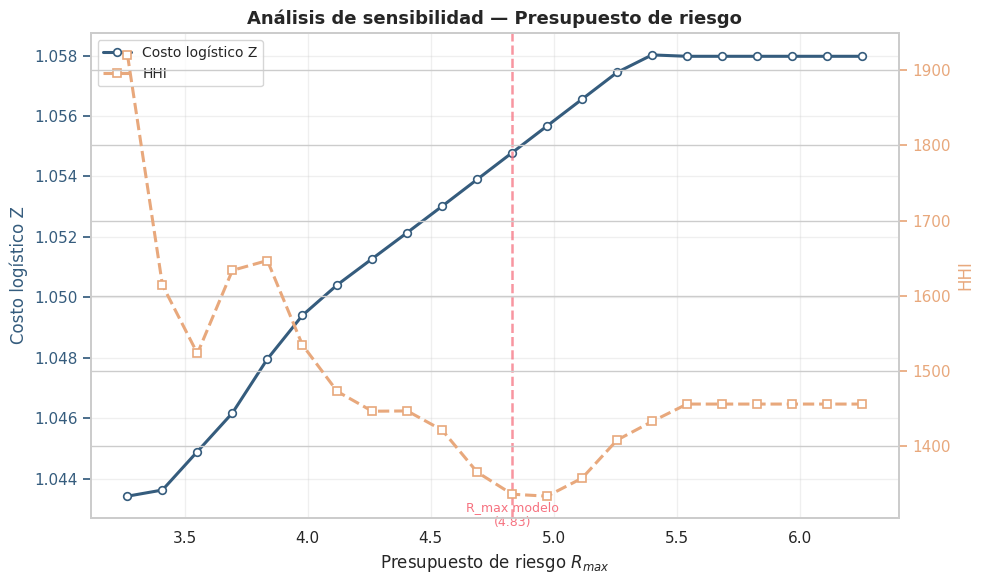

Hallazgo: existe un punto de inflexión alrededor de R_max ≈ 3.69
Por debajo de ese punto, reducir riesgo tiene un costo marginal creciente.
Por encima, relajar el presupuesto ya no mejora significativamente el costo.
✅ Sensibilidad fina y hallazgos gráficos guardados en hallazgos.md


In [ ]:
perturbaciones_finas = np.linspace(-0.30, 0.30, 31)
curvas_perturbacion = {}

for pais in paises_analizar:
    curvas_perturbacion[pais] = []
    for delta in perturbaciones_finas:
        c_mod = dict(c)
        c_mod[pais] = c[pais] * (1 + delta)

        prob_p = LpProblem("Pert", LpMinimize)
        x_p  = LpVariable.dicts("xp", I, lowBound=x_min, upBound=x_max)
        dp_p = LpVariable.dicts("dpp", I, lowBound=0)
        dn_p = LpVariable.dicts("dnp", I, lowBound=0)

        prob_p += (lpSum([c_mod[i] * x_p[i] for i in I]) +
                   tau * lpSum([dp_p[i] + dn_p[i] for i in I]))
        prob_p += lpSum([x_p[i] for i in I]) == 1
        for i in I:
            prob_p += x_p[i] - a[i] == dp_p[i] - dn_p[i]
        prob_p += lpSum([r[i] * x_p[i] for i in I]) <= R_max
        if T:
            prob_p += lpSum([x_p[i] for i in T]) >= L_tlc
        prob_p.solve(PULP_CBC_CMD(msg=0))

        if LpStatus[prob_p.status] == 'Optimal':
            sol_p = {i: pulp.value(x_p[i]) for i in I}
            curvas_perturbacion[pais].append({
                'delta':  delta,
                'x_pais': sol_p[pais],
                'costo':  sum(c_mod[i]*sol_p[i] for i in I),
            })

# --- PALETA ELEGANTE (consistente con todo el notebook) ---
palette_elegante = [
    '#355C7D', '#C06C84', '#6C5B7B', '#F67280', '#99B898',
    '#FECEAB', '#8E806A', '#A8A7A7', '#E8A87C'
]
COLOR_COSTO = palette_elegante[0]    # azul petróleo
COLOR_HHI   = palette_elegante[8]    # terracota
COLOR_RMAX  = palette_elegante[3]    # coral

# Gráfica única: trade-off costo vs. riesgo
fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

R_vals = [p['R_max'] for p in curva_Rmax]
C_vals = [p['costo'] for p in curva_Rmax]
H_vals = [p['hhi']   for p in curva_Rmax]

l1, = ax1.plot(R_vals, C_vals, 'o-', color=COLOR_COSTO,
               linewidth=2.2, markersize=5.5, markerfacecolor='white',
               markeredgewidth=1.2, label='Costo logístico Z')
l2, = ax2.plot(R_vals, H_vals, 's--', color=COLOR_HHI,
               linewidth=2.2, markersize=5.5, markerfacecolor='white',
               markeredgewidth=1.2, label='HHI')
ax1.axvline(x=R_max, color=COLOR_RMAX, linestyle='--',
            linewidth=1.8, alpha=0.75)
ax1.annotate(f'R_max modelo\n({R_max:.2f})',
             xy=(R_max, min(C_vals)), fontsize=9,
             color=COLOR_RMAX, ha='center',
             xytext=(R_max, min(C_vals) - 0.001))

ax1.set_xlabel('Presupuesto de riesgo $R_{max}$', fontsize=12)
ax1.set_ylabel('Costo logístico Z', fontsize=12, color=COLOR_COSTO)
ax2.set_ylabel('HHI', fontsize=12, color=COLOR_HHI)
ax1.tick_params(axis='y', colors=COLOR_COSTO)
ax2.tick_params(axis='y', colors=COLOR_HHI)
ax1.set_title('Análisis de sensibilidad — Presupuesto de riesgo',
              fontweight='bold', fontsize=13)
ax1.legend(handles=[l1, l2], fontsize=10, loc='upper left')
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('10_sensibilidad_Rmax.png', dpi=150, bbox_inches='tight')
plt.show()

# Hallazgo de punto de inflexión
if len(C_vals) >= 2:
    idx_inflexion = np.argmax(np.diff(C_vals))
    R_inflexion = R_vals[idx_inflexion]
else:
    R_inflexion = R_max

print(f"Hallazgo: existe un punto de inflexión alrededor de R_max ≈ {R_inflexion:.2f}")
print("Por debajo de ese punto, reducir riesgo tiene un costo marginal creciente.")
print("Por encima, relajar el presupuesto ya no mejora significativamente el costo.")


# ============================================================
# CONSTRUCCIÓN DEL REPORTE PARA hallazgos.md
# ============================================================

reporte_perturbacion = "\n### 7.7 Sensibilidad Fina y Punto de Inflexión del Presupuesto de Riesgo\n\n"
reporte_perturbacion += "Se realizó una exploración fina del espacio paramétrico para evaluar cómo responde la solución óptima ante cambios graduales en el presupuesto máximo de riesgo. En paralelo, se calcularon perturbaciones individuales sobre los costos unitarios de los países priorizados para identificar posibles cambios de régimen en la base óptima.\n\n"

# 7.7.1 Curva paramétrica de R_max
reporte_perturbacion += "#### 7.7.1 Trade-off entre costo logístico y concentración\n\n"
reporte_perturbacion += "La Figura `10_sensibilidad_Rmax.png` resume la relación entre el presupuesto de riesgo ($R_{max}$), el costo logístico total y el nivel de concentración medido por el HHI.\n\n"
reporte_perturbacion += f"- **Punto de inflexión estimado:** $R_{{max}} \\approx {R_inflexion:.2f}$\n"
reporte_perturbacion += "- **Lectura económica:** por debajo de ese umbral, cada reducción adicional del riesgo exige sacrificios crecientes en costo logístico.\n"
reporte_perturbacion += "- **Lectura estratégica:** por encima de ese punto, ampliar el presupuesto de riesgo aporta beneficios decrecientes en eficiencia.\n\n"

if curva_Rmax:
    reporte_perturbacion += "| R_max | Costo logístico | HHI | Riesgo efectivo | Exposición máxima |\n"
    reporte_perturbacion += "|---:|---:|---:|---:|---:|\n"
    for p in curva_Rmax:
        reporte_perturbacion += f"| {p['R_max']:.3f} | {p['costo']:.4f} | {p['hhi']:.0f} | {p['riesgo']:.3f} | {p['max_p']*100:.1f}% |\n"
    reporte_perturbacion += "\n"

# 7.7.2 Perturbación por país
reporte_perturbacion += "#### 7.7.2 Perturbaciones finas sobre costos por país\n\n"
reporte_perturbacion += "Se modificó el costo logístico unitario de los países seleccionados entre -30% y +30%, manteniendo constantes las demás condiciones del modelo, para observar cambios en su participación óptima y en el costo total del portafolio.\n\n"

reporte_perturbacion += "| País | Observaciones principales |\n"
reporte_perturbacion += "|---|---|\n"

for pais, datos in curvas_perturbacion.items():
    if not datos:
        reporte_perturbacion += f"| {pais} | No se obtuvo solución óptima en las perturbaciones evaluadas. |\n"
        continue

    x_vals = [d['x_pais'] for d in datos]
    costo_vals = [d['costo'] for d in datos]

    x_min_p = min(x_vals) * 100
    x_max_p = max(x_vals) * 100
    costo_min_p = min(costo_vals)
    costo_max_p = max(costo_vals)

    if max(x_vals) - min(x_vals) < 1e-4:
        lectura = (
            f"La participación óptima permaneció prácticamente estable "
            f"({x_min_p:.1f}%–{x_max_p:.1f}%), lo que sugiere baja sensibilidad local."
        )
    else:
        lectura = (
            f"La participación óptima osciló entre {x_min_p:.1f}% y {x_max_p:.1f}%, "
            f"evidenciando sensibilidad material ante cambios en su costo relativo."
        )

    lectura += f" El costo total del sistema varió entre {costo_min_p:.4f} y {costo_max_p:.4f}."

    reporte_perturbacion += f"| {pais} | {lectura} |\n"

reporte_perturbacion += "\n"

# 7.7.3 Países más sensibles
reporte_perturbacion += "#### 7.7.3 Identificación de sensibilidad local\n\n"

sensibilidad_paises = []
for pais, datos in curvas_perturbacion.items():
    if datos:
        amplitud_x = max(d['x_pais'] for d in datos) - min(d['x_pais'] for d in datos)
        amplitud_costo = max(d['costo'] for d in datos) - min(d['costo'] for d in datos)
        sensibilidad_paises.append({
            'pais': pais,
            'amplitud_x': amplitud_x,
            'amplitud_costo': amplitud_costo
        })

sensibilidad_paises = sorted(sensibilidad_paises, key=lambda x: x['amplitud_x'], reverse=True)

if sensibilidad_paises:
    reporte_perturbacion += "| País | Variación de participación | Variación de costo total |\n"
    reporte_perturbacion += "|---|---:|---:|\n"
    for s in sensibilidad_paises:
        reporte_perturbacion += f"| {s['pais']} | {s['amplitud_x']*100:.2f} p.p. | {s['amplitud_costo']:.4f} |\n"
    reporte_perturbacion += "\n"

    reporte_perturbacion += "Los países con mayor amplitud de respuesta son los candidatos más probables a cambiar de rol estratégico si se alteran sus costos relativos en el corto plazo.\n\n"
else:
    reporte_perturbacion += "No se identificaron cambios relevantes en participación ante las perturbaciones evaluadas.\n\n"

# 7.7.4 Cierre
reporte_perturbacion += "#### 7.7.4 Conclusión de sensibilidad fina\n\n"
reporte_perturbacion += "> El sistema presenta una zona de inflexión alrededor del presupuesto de riesgo actual, a partir de la cual los beneficios de relajar la restricción se vuelven marginales. A nivel micro, las perturbaciones por país permiten distinguir entre socios estructuralmente estables y socios con comportamiento sensible, útiles para priorizar monitoreo estratégico y revisión de supuestos logísticos.\n\n"

with open("hallazgos.md", "a", encoding="utf-8") as f:
    f.write(reporte_perturbacion)

print("✅ Sensibilidad fina y hallazgos gráficos guardados en hallazgos.md")

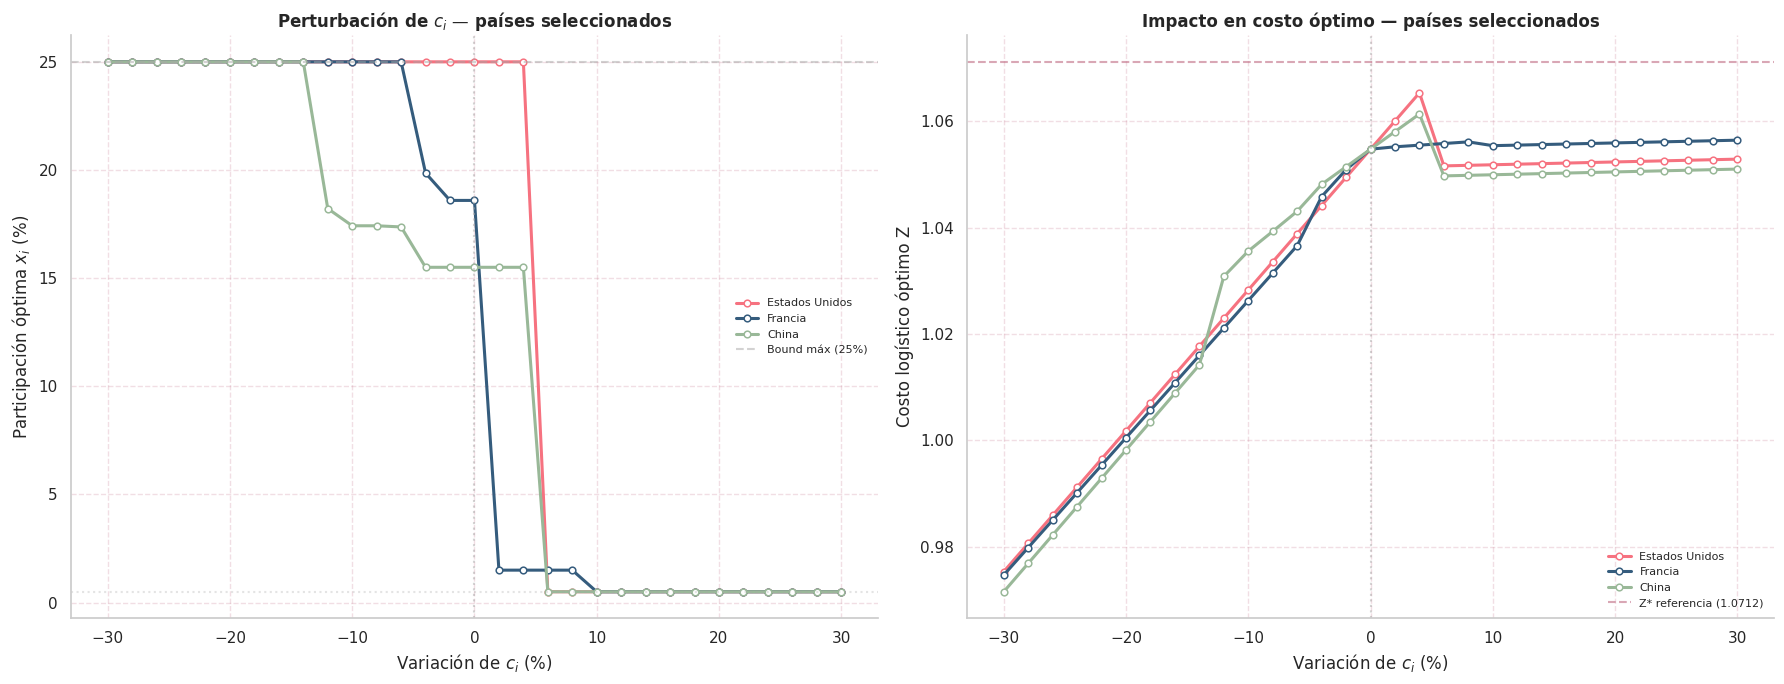


RESUMEN DEL ANÁLISIS DE SENSIBILIDAD

  1. RESTRICCIONES ACTIVAS: 25 de 26 restricciones condicionan la solución.

  2. PRECIO SOMBRA DE R_max: -0.011225
     → Aumentar R_max en 0.1 reduciría Z* en 0.001123
     → R3 SÍ es restricción activa — R_max condiciona la solución.

  3. PAÍSES EN BOUND:
     - En bound MÁXIMO (25%): 1 países
     - En bound MÍNIMO (0.5%): 1 países
     - Interiores: 21 países

  4. CONCLUSIÓN PRINCIPAL:
     El modelo produce soluciones INTERIORES para varios países.
     La sensibilidad muestra transiciones graduales.

✅ Visualización integrada y resumen ejecutivo guardados en hallazgos.md


In [ ]:
palette_elegante = [
    '#355C7D', '#C06C84', '#6C5B7B', '#F67280', '#99B898',
    '#FECEAB', '#8E806A', '#A8A7A7', '#E8A87C'
]
colores_pert = [
    palette_elegante[3],   # coral
    palette_elegante[0],   # azul petróleo
    palette_elegante[4],   # verde suave
    palette_elegante[2],   # violeta grisáceo
    palette_elegante[8]    # terracota
]
COLOR_BOUND = palette_elegante[7]      # gris
COLOR_REF   = palette_elegante[1]      # rosa vino


# ── VISUALIZACIÓN ────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Panel 3: Perturbación de c_i — participación
ax3 = axes[0]
for idx, pais in enumerate(paises_analizar):
    if curvas_perturbacion.get(pais):
        deltas = [p['delta'] * 100 for p in curvas_perturbacion[pais]]
        xs = [p['x_pais'] * 100 for p in curvas_perturbacion[pais]]

        ax3.plot(
            deltas, xs,
            'o-',
            color=colores_pert[idx % len(colores_pert)],
            linewidth=2.2,
            markersize=4.8,
            markerfacecolor='white',
            markeredgewidth=1.1,
            label=pais
        )

ax3.axvline(x=0, color=COLOR_BOUND, linestyle=':', alpha=0.5)
ax3.axhline(y=x_max*100, color=COLOR_BOUND, linestyle='--', alpha=0.5,
            label=f'Bound máx ({x_max*100:.0f}%)')
ax3.axhline(y=x_min*100, color=COLOR_BOUND, linestyle=':', alpha=0.3)

ax3.set_xlabel('Variación de $c_i$ (%)')
ax3.set_ylabel('Participación óptima $x_i$ (%)')
ax3.set_title('Perturbación de $c_i$ — países seleccionados', fontweight='bold')
ax3.legend(fontsize=8, frameon=False)
ax3.grid(True, linestyle='--', alpha=0.22, color=COLOR_REF)
ax3.set_axisbelow(True)

ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# Panel 4: Perturbación de c_i — costo óptimo
ax4 = axes[1]
for idx, pais in enumerate(paises_analizar):
    if curvas_perturbacion.get(pais):
        deltas = [p['delta'] * 100 for p in curvas_perturbacion[pais]]
        costos = [p['costo'] for p in curvas_perturbacion[pais]]

        ax4.plot(
            deltas, costos,
            'o-',
            color=colores_pert[idx % len(colores_pert)],
            linewidth=2.2,
            markersize=4.8,
            markerfacecolor='white',
            markeredgewidth=1.1,
            label=pais
        )

ax4.axvline(x=0, color=COLOR_BOUND, linestyle=':', alpha=0.5)
ax4.axhline(y=Z_base, color=COLOR_REF, linestyle='--', alpha=0.6,
            label=f'Z* referencia ({Z_base:.4f})')

ax4.set_xlabel('Variación de $c_i$ (%)')
ax4.set_ylabel('Costo logístico óptimo Z')
ax4.set_title('Impacto en costo óptimo — países seleccionados', fontweight='bold')
ax4.legend(fontsize=8, frameon=False)
ax4.grid(True, linestyle='--', alpha=0.22, color=COLOR_REF)
ax4.set_axisbelow(True)

ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('10_sensibilidad_LP.png', dpi=150, bbox_inches='tight')
plt.show()

# ── RESUMEN EJECUTIVO ────────────────────────────────────────
print("\n" + "=" * 70)
print("RESUMEN DEL ANÁLISIS DE SENSIBILIDAD")
print("=" * 70)

n_activas = sum(
    1 for c_ in prob.constraints.values()
    if c_.slack is not None and abs(c_.slack) < 1e-6
)

print(f"\n  1. RESTRICCIONES ACTIVAS: {n_activas} de "
      f"{len(prob.constraints)} restricciones condicionan la solución.")

pi_riesgo = prob.constraints.get('R3_Riesgo')
if pi_riesgo and pi_riesgo.pi is not None:
    print(f"\n  2. PRECIO SOMBRA DE R_max: {pi_riesgo.pi:.6f}")
    print(f"     → Aumentar R_max en 0.1 reduciría Z* en {abs(pi_riesgo.pi)*0.1:.6f}")
    if abs(pi_riesgo.pi) < 1e-6:
        print("     → R3 NO es restricción activa — R_max no condiciona la solución.")
    else:
        print("     → R3 SÍ es restricción activa — R_max condiciona la solución.")

print(f"\n  3. PAÍSES EN BOUND:")
print(f"     - En bound MÁXIMO ({x_max*100:.0f}%): {len(paises_en_bound['max'])} países")
print(f"     - En bound MÍNIMO ({x_min*100:.1f}%): {len(paises_en_bound['min'])} países")
print(f"     - Interiores: {len(I) - len(paises_en_bound['max']) - len(paises_en_bound['min'])} países")

print(f"\n  4. CONCLUSIÓN PRINCIPAL:")
if len(paises_en_bound['max']) + len(paises_en_bound['min']) >= len(I) - 2:
    print("     El modelo produce soluciones de ESQUINA para la mayoría de países.")
    print("     Los bounds x_min y x_max son las restricciones dominantes.")
    print("     La sensibilidad se manifiesta como PUNTOS DE QUIEBRE discretos,")
    print("     no como variaciones graduales.")
    conclusion_sens = (
        "El modelo produce soluciones de esquina para la mayoría de países. "
        "En consecuencia, los límites inferiores y superiores de participación "
        "actúan como restricciones dominantes, y la sensibilidad observada se "
        "manifiesta principalmente mediante puntos de quiebre discretos más que "
        "por ajustes graduales en las asignaciones."
    )
else:
    print("     El modelo produce soluciones INTERIORES para varios países.")
    print("     La sensibilidad muestra transiciones graduales.")
    conclusion_sens = (
        "El modelo conserva soluciones interiores para varios países, lo que "
        "permite ajustes progresivos en la asignación óptima ante perturbaciones "
        "de parámetros. En este caso, la sensibilidad se expresa mediante "
        "transiciones graduales y no únicamente por cambios abruptos de régimen."
    )


# ============================================================
# CONSTRUCCIÓN DEL REPORTE PARA hallazgos.md
# ============================================================

reporte_sens_final = "\n### 7.8 Visualización Integrada de Sensibilidad y Resumen Ejecutivo\n\n"

reporte_sens_final += "#### Figura 11. Sensibilidad local del LP ante perturbaciones en costos\n\n"
reporte_sens_final += "![Sensibilidad LP](10_sensibilidad_LP.png)\n\n"
reporte_sens_final += (
    "La figura presenta dos lecturas complementarias del análisis de sensibilidad local. "
    "El panel izquierdo muestra cómo cambia la participación óptima de los países "
    "seleccionados cuando se perturba su costo logístico relativo; el panel derecho "
    "muestra el efecto de esas mismas perturbaciones sobre el costo óptimo total del sistema.\n\n"
)

reporte_sens_final += "#### 7.8.1 Lectura de la visualización\n\n"
reporte_sens_final += (
    f"- La línea vertical en **0%** representa el escenario base sin perturbación.\n"
    f"- La línea horizontal en **{x_max*100:.0f}%** marca el bound superior de participación permitido por el modelo.\n"
    f"- La línea horizontal de referencia en el panel de costo corresponde a **$Z^* = {Z_base:.4f}$**.\n"
    "- Curvas con tramos planos sugieren estabilidad local de la solución; cambios abruptos o quiebres indican transiciones de régimen en la base óptima.\n\n"
)

reporte_sens_final += "#### 7.8.2 Resumen ejecutivo del modelo dual\n\n"
reporte_sens_final += f"- **Restricciones activas:** {n_activas} de {len(prob.constraints)}\n"

if pi_riesgo and pi_riesgo.pi is not None:
    reporte_sens_final += f"- **Precio sombra de la restricción de riesgo (`R3_Riesgo`):** {pi_riesgo.pi:.6f}\n"
    reporte_sens_final += f"- **Impacto marginal estimado de aumentar $R_{{max}}$ en 0.1:** {abs(pi_riesgo.pi)*0.1:.6f} sobre $Z^*$\n"
    if abs(pi_riesgo.pi) < 1e-6:
        reporte_sens_final += "- **Lectura:** la restricción de riesgo no está presionando el óptimo en el margen.\n"
    else:
        reporte_sens_final += "- **Lectura:** la restricción de riesgo sí condiciona la solución óptima y tiene valor económico marginal.\n"

reporte_sens_final += f"- **Países en bound máximo ({x_max*100:.0f}%):** {len(paises_en_bound['max'])}\n"
reporte_sens_final += f"- **Países en bound mínimo ({x_min*100:.1f}%):** {len(paises_en_bound['min'])}\n"
reporte_sens_final += f"- **Países interiores:** {len(I) - len(paises_en_bound['max']) - len(paises_en_bound['min'])}\n\n"

reporte_sens_final += "#### 7.8.3 Conclusión ejecutiva\n\n"
reporte_sens_final += f"> {conclusion_sens}\n\n"

with open("hallazgos.md", "a", encoding="utf-8") as f:
    f.write(reporte_sens_final)

print("\n✅ Visualización integrada y resumen ejecutivo guardados en hallazgos.md")

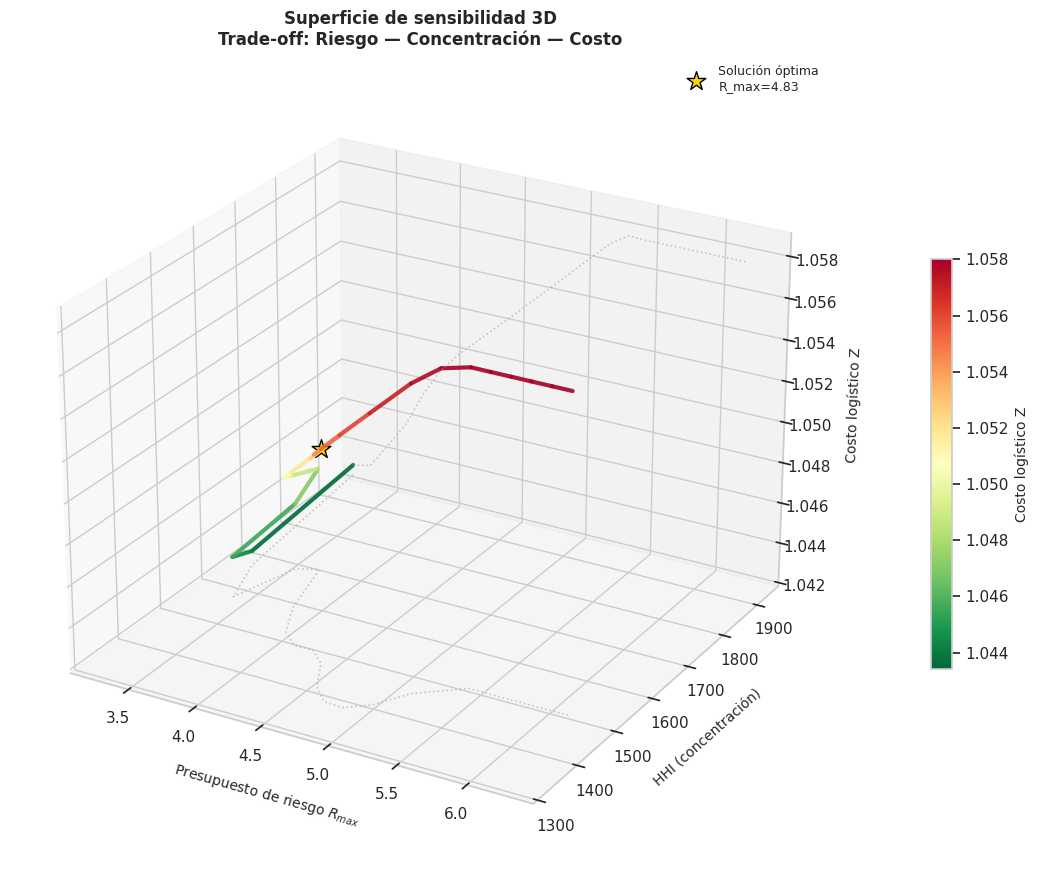

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

# curva_Rmax es la lista de dicts generada en el análisis paramétrico
R_vals_3d   = np.array([p['R_max']  for p in curva_Rmax])
C_vals_3d   = np.array([p['costo']  for p in curva_Rmax])
HHI_vals_3d = np.array([p['hhi']    for p in curva_Rmax])

fig = plt.figure(figsize=(13, 9))
ax  = fig.add_subplot(111, projection='3d')

# ── Línea trayectoria 3D ───────────────────────────────────────
norm = plt.Normalize(C_vals_3d.min(), C_vals_3d.max())
cmap = cm.RdYlGn_r   # rojo = caro, verde = barato

for i in range(len(R_vals_3d) - 1):
    color = cmap(norm((C_vals_3d[i] + C_vals_3d[i+1]) / 2))
    ax.plot(
        R_vals_3d[i:i+2],
        HHI_vals_3d[i:i+2],
        C_vals_3d[i:i+2],
        color=color,
        linewidth=3.0,
        alpha=0.9
    )

# ── Marcador de la solución óptima actual ─────────────────────
idx_opt = np.argmin(np.abs(R_vals_3d - R_max))
ax.scatter(
    [R_vals_3d[idx_opt]],
    [HHI_vals_3d[idx_opt]],
    [C_vals_3d[idx_opt]],
    color='gold',
    edgecolors='black',
    s=200,
    zorder=10,
    marker='*',
    label=f'Solución óptima\nR_max={R_max:.2f}'
)

# ── Proyecciones sobre los planos ─────────────────────────────
z_floor = C_vals_3d.min() - 0.0005
ax.plot(R_vals_3d, HHI_vals_3d, z_floor,
        color='#A8A7A7', linewidth=1.2, linestyle=':', alpha=0.6)
ax.plot(R_vals_3d, [HHI_vals_3d.max()]*len(R_vals_3d), C_vals_3d,
        color='#A8A7A7', linewidth=1.2, linestyle=':', alpha=0.6)

# ── Barra de color (costo) ─────────────────────────────────────
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.5, pad=0.08)
cbar.set_label('Costo logístico Z', fontsize=10)

ax.set_xlabel('Presupuesto de riesgo $R_{max}$', fontsize=10, labelpad=10)
ax.set_ylabel('HHI (concentración)', fontsize=10, labelpad=10)
ax.set_zlabel('Costo logístico Z', fontsize=10, labelpad=10)
ax.set_title('Superficie de sensibilidad 3D\nTrade-off: Riesgo — Concentración — Costo',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=9, frameon=False)
ax.view_init(elev=25, azim=-60)

plt.tight_layout()
plt.savefig('sensibilidad_3D.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Simulación Monte Carlo — Análisis de riesgo del portafolio optimizado

### Paso 1. Definir el problema y el contexto

El modelo de optimización (sección 5) determinó la asignación óptima $x_i^*$
para los **23 países proveedores internacionales** del cluster de socios estratégicos,
minimizando el costo logístico sujeto a un presupuesto de riesgo geopolítico. Sin
embargo, esa solución asume que los parámetros $c_i$ y las capacidades de suministro
son **deterministas**. En la realidad, estos parámetros están sujetos a incertidumbre.
La simulación de Monte Carlo evalúa qué tan robusto es el portafolio optimizado
frente a la aleatoriedad del entorno.

**Enlace con la etapa anterior:** la simulación toma como entrada fija la
asignación óptima $x_i^*$ del escenario Moderado (sección 5.2) y la somete a
10.000 realizaciones estocásticas.

**Objetivo:** estimar la distribución de probabilidad del costo total de
importación y la cobertura de demanda bajo incertidumbre en costos, tipo de
cambio y disrupciones de suministro.

**Indicadores clave (KPIs):**
- VaR 95% del costo total (peor caso con 95% de confianza)
- CVaR 95% (costo promedio en el 5% peor)
- Cobertura media de demanda
- P(cobertura < 90%) — probabilidad de falla crítica

**Escenarios:** se comparan tres condiciones distintas del entorno:
1. **Normal:** disrupciones con probabilidades derivadas del AHP
2. **Estrés China −50%:** disrupción severa forzada en China
3. **Estrés dual China + EE.UU. −50%:** disrupción simultánea en los dos
   proveedores dominantes

### Paso 2. Caracterizar el modelo de simulación

**Ecuación del costo total para una iteración $n$:**

$$\text{Costo}_n = \underbrace{\sum_{i \in I} c_i \cdot x_i^* \cdot D \cdot S_i^{(n)} \cdot \text{FX}^{(n)} \cdot \epsilon_i^{(n)}}_{\text{costo de importación efectiva}} + \underbrace{\phi \cdot D \cdot \text{FX}^{(n)} \cdot \left(1 - \sum_{i \in I} x_i^* \cdot S_i^{(n)}\right)^+}_{\text{penalidad por faltante}}$$


donde:
- $x_i^*$ = asignación óptima del modelo LP (**parámetro fijo** de la simulación)
- $D$ = demanda total del cluster (USD 35.244M, parámetro fijo)
- $c_i$ = costo logístico observado (parámetro fijo)
- $\text{FX}^{(n)}$ = factor de tipo de cambio en la iteración $n$ (estocástico)
- $S_i^{(n)}$ = factor de suministro del país $i$ (1 = normal, $<$1 = disrupción)
- $\epsilon_i^{(n)}$ = shock logístico multiplicativo (estocástico)
- $\phi$ = factor de penalidad por faltante (1.5×)
- $(z)^+ = \max(0, z)$

**Supuesto de gestión:** la demanda no satisfecha se cubre con compras de
emergencia en el mercado spot, con un sobrecosto de 50% sobre el precio
planeado — esto es lo que captura el factor $\phi = 1.5$.

### Paso 3. Preparar las variables de entrada

| Variable | Distribución | Parámetros | Justificación |
|----------|-------------|------------|---------------|
| Tipo de cambio $\text{FX}$ | $\mathcal{N}(1.0,\ 0.05)$ | $\mu=1$, $\sigma=0.05$ | Volatilidad observada del USD/COP en el periodo (±5%) |
| Disrupción países alto riesgo ($r_i \geq 7$) | $\text{Bernoulli}(0.12)$ | $p=0.12$ | Calibrado al score AHP (China: $r=8.5$) |
| Disrupción socios con TLC | $\text{Bernoulli}(0.03)$ | $p=0.03$ | Acuerdos vigentes reducen riesgo base |
| Disrupción otros países | $\text{Bernoulli}(0.05)$ | $p=0.05$ | Riesgo moderado base del mercado internacional |
| Magnitud de disrupción (si ocurre) | $U(0.20,\ 0.80)$ | $a=0.2$, $b=0.8$ | Reducción entre 20% y 80% del suministro |
| Shock logístico por país $\epsilon_i$ | $\text{LogNormal}(0,\ 0.08)$ | $\mu=0$, $\sigma=0.08$ | Variabilidad de flete y seguro |

**Método de muestreo:** pseudoaleatorio con semilla fija (`np.random.seed(42)`)
para garantizar reproducibilidad.

**Tamaño de muestra:** $N = 10.000$ iteraciones, suficiente para estabilizar
los percentiles VaR y CVaR (validado mediante gráfica de convergencia).

**Supuesto:** las disrupciones entre países son **independientes** en el escenario
Normal. En los escenarios de estrés se fuerza una correlación perfecta al imponer
$S_{\text{China}} = 0.5$ (y $S_{\text{EEUU}} = 0.5$ en el estrés dual) en todas
las iteraciones.

In [ ]:
# ============================================================
# 6. SIMULACIÓN MONTE CARLO
# Pasos 4 y 5: Ejecución y análisis de resultados
# ============================================================

N_SIM = 10000
np.random.seed(42)
FACTOR_PENALIDAD = 1.5

# ── ENTRADA DESDE EL MODELO DE OPTIMIZACIÓN ──────────────────
# x_opt: asignación óptima del modelo (escenario moderado)
x_opt = sol_base   # del bloque de optimización (sección 5)

# a: asignación actual (para comparación)
# c: costos logísticos
# r: scores de riesgo
# I: países del cluster
# T: países con TLC
# demanda_total: USD del cluster

print("=" * 70)
print("PASO 4 — Ejecución de la simulación Monte Carlo")
print("=" * 70)
print(f"  Portafolio evaluado:  Óptimo del modelo de optimización")
print(f"  Países (|I|):         {len(I)}")
print(f"  Demanda total:        USD {demanda_total/1e6:,.0f} millones")
print(f"  Iteraciones:          {N_SIM:,}")
print(f"  Penalidad faltante:   {FACTOR_PENALIDAD}x")


# ── FUNCIÓN DE SIMULACIÓN ────────────────────────────────────

def simular_montecarlo(asignacion, nombre, n_sim=N_SIM,
                        forzar_china=None, forzar_eeuu=None):
    """
    Ejecuta N simulaciones sobre un portafolio dado.

    Parámetros:
      asignacion: dict {país: proporción}
      nombre: str para identificar el escenario
      forzar_china: float o None — si se da, fuerza S_China = este valor
      forzar_eeuu: float o None — si se da, fuerza S_EEUU = este valor

    Retorna: dict con vectores de resultados
    """
    costos_totales = np.zeros(n_sim)
    costos_import  = np.zeros(n_sim)
    penalidades    = np.zeros(n_sim)
    coberturas     = np.zeros(n_sim)
    hhis           = np.zeros(n_sim)

    for n in range(n_sim):
        # --- Variables aleatorias ---
        shock_fx = np.random.normal(1.0, 0.05)    # tipo de cambio

        participacion_efectiva = {}
        for pais in I:
            xi = asignacion.get(pais, 0)
            if xi <= 0:
                participacion_efectiva[pais] = 0
                continue

            # Disrupción: Bernoulli con probabilidad según riesgo
            # Calibrado al AHP: solo países con r >= 8 son "alto riesgo" (12%)
            # Países con 6 <= r < 8 son "riesgo elevado" (7%)
            if r[pais] >= 8:
                prob_dis = 0.12
            elif r[pais] >= 6:
                prob_dis = 0.07
            elif pais in T:
                prob_dis = 0.03
            else:
                prob_dis = 0.05

            # Factor de suministro
            if pais == 'China' and forzar_china is not None:
                S_i = forzar_china
            elif pais == 'Estados Unidos' and forzar_eeuu is not None:
                S_i = forzar_eeuu
            elif np.random.random() < prob_dis:
                magnitud = np.random.uniform(0.20, 0.80)
                S_i = 1 - magnitud
            else:
                S_i = 1.0

            participacion_efectiva[pais] = xi * S_i

        # --- Cobertura ---
        cobertura = sum(participacion_efectiva.values())
        coberturas[n] = cobertura

        # --- Costo de importación ---
        costo_import = 0
        for pais in I:
            pe = participacion_efectiva.get(pais, 0)
            if pe > 0:
                shock_log = np.random.lognormal(0, 0.08)
                costo_import += c[pais] * pe * demanda_total * shock_fx * shock_log

        costos_import[n] = costo_import

        # --- Penalidad por faltante ---
        faltante = max(0, 1 - cobertura)
        penalidad = FACTOR_PENALIDAD * faltante * demanda_total * shock_fx
        penalidades[n] = penalidad

        # --- Costo total ---
        costos_totales[n] = costo_import + penalidad

        # --- HHI efectivo ---
        if cobertura > 0:
            parts_norm = {p: participacion_efectiva[p]/cobertura
                          for p in I if participacion_efectiva.get(p,0) > 0}
            hhis[n] = sum(v**2 for v in parts_norm.values()) * 10000
        else:
            hhis[n] = 10000

    return {
        'nombre':    nombre,
        'costos':    costos_totales,
        'import':    costos_import,
        'penal':     penalidades,
        'cobert':    coberturas,
        'hhi':       hhis
    }


# ── EJECUTAR LOS ESCENARIOS (base Y óptimo bajo mismas condiciones) ──

# Escenario 1: Normal — portafolio BASE
esc_base       = simular_montecarlo(a,     "Normal (base)")
# Escenario 2: Normal — portafolio ÓPTIMO
esc_normal     = simular_montecarlo(x_opt, "Normal (óptimo)")

# Escenario 3: Estrés China −50% — portafolio BASE
esc_china_base = simular_montecarlo(a,     "Estrés China −50% (base)",
                                    forzar_china=0.50)
# Escenario 4: Estrés China −50% — portafolio ÓPTIMO
esc_china      = simular_montecarlo(x_opt, "Estrés China −50% (óptimo)",
                                    forzar_china=0.50)

# Escenario 5: Estrés dual — portafolio BASE
esc_dual_base  = simular_montecarlo(a,     "Estrés dual (base)",
                                    forzar_china=0.50, forzar_eeuu=0.50)
# Escenario 6: Estrés dual — portafolio ÓPTIMO
esc_dual       = simular_montecarlo(x_opt, "Estrés dual (óptimo)",
                                    forzar_china=0.50, forzar_eeuu=0.50)

# ── PASO 5: ANÁLISIS DE RESULTADOS ───────────────────────────

def reportar(esc):
    ct = esc['costos']
    co = esc['cobert']
    var95  = np.percentile(ct, 95)
    cvar95 = ct[ct >= var95].mean()
    return {
        'nombre':      esc['nombre'],
        'media':       ct.mean(),
        'std':         ct.std(),
        'var95':       var95,
        'cvar95':      cvar95,
        'cob_media':   co.mean() * 100,
        'cob_min':     co.min() * 100,
        'p_cob_90':    (co < 0.90).mean() * 100,
        'p_cob_95':    (co < 0.95).mean() * 100,
        'hhi_media':   esc['hhi'].mean()
    }

# resumen completo por escenario
rep_base       = reportar(esc_base)
rep_normal     = reportar(esc_normal)
rep_china_base = reportar(esc_china_base)
rep_china      = reportar(esc_china)
rep_dual_base  = reportar(esc_dual_base)
rep_dual       = reportar(esc_dual)

resultados_mc = [rep_base, rep_normal, rep_china, rep_dual]

# ── TABLA COMPARATIVA BASE vs. ÓPTIMO POR CONDICIÓN ─────────
print("\n" + "=" * 90)
print("COMPARACIÓN BASE vs. ÓPTIMO — MISMO ESCENARIO")
print("=" * 90)

pares = [
    ("Normal",        esc_base,       esc_normal),
    ("Estrés China",  esc_china_base, esc_china),
    ("Estrés dual",   esc_dual_base,  esc_dual),
]

print(f"\n{'Condición':<15} {'KPI':<30} {'Base':>12} {'Óptimo':>12} {'Mejora':>10}")
print("-" * 82)

for cond, e_base, e_opt in pares:
    for kpi, fn_b, fn_o in [
        ("VaR 95% (USD M)",
         lambda e: np.percentile(e['costos'],95)/1e6,
         lambda e: np.percentile(e['costos'],95)/1e6),
        ("Cob. media (%)",
         lambda e: e['cobert'].mean()*100,
         lambda e: e['cobert'].mean()*100),
        ("P(cob<90%)",
         lambda e: (e['cobert']<0.90).mean()*100,
         lambda e: (e['cobert']<0.90).mean()*100),
    ]:
        vb = fn_b(e_base)
        vo = fn_o(e_opt)
        mejora = vo - vb
        signo  = "✓" if mejora < 0 else ("✓" if kpi == "Cob. media (%)" and mejora > 0 else "")
        print(f"  {cond:<13} {kpi:<30} {vb:>12.1f} {vo:>12.1f} {mejora:>+9.1f} {signo}")
    print()


# ============================================================
# CONSTRUCCIÓN DEL REPORTE PARA hallazgos.md
# ============================================================

reporte_mc = "\n### 8 Resultados de la simulación Monte Carlo\n\n"
reporte_mc += (
    "Se ejecutaron 10.000 iteraciones pseudoaleatorias para evaluar la robustez "
    "del portafolio base y del portafolio optimizado bajo tres condiciones del entorno: "
    "escenario Normal, estrés unilateral sobre China y estrés dual sobre China y Estados Unidos. "
    "En cada simulación se modelaron variaciones en tipo de cambio, shocks logísticos y "
    "eventuales interrupciones de suministro.\n\n"
)

reporte_mc += "#### 8.1 Resumen comparativo base vs. óptimo\n\n"
reporte_mc += "| Condición | Portafolio | Costo medio (USD M) | VaR 95% (USD M) | CVaR 95% (USD M) | Cobertura media (%) | P(cob<90%) |\n"
reporte_mc += "|---|---|---:|---:|---:|---:|---:|\n"

for cond, rep_b, rep_o in [
    ("Normal",       rep_base,       rep_normal),
    ("Estrés China", rep_china_base, rep_china),
    ("Estrés dual",  rep_dual_base,  rep_dual)
]:
    reporte_mc += (
        f"| {cond} | Base | {rep_b['media']/1e6:.1f} | {rep_b['var95']/1e6:.1f} | "
        f"{rep_b['cvar95']/1e6:.1f} | {rep_b['cob_media']:.2f} | {rep_b['p_cob_90']:.2f} |\n"
    )
    reporte_mc += (
        f"| {cond} | Óptimo | {rep_o['media']/1e6:.1f} | {rep_o['var95']/1e6:.1f} | "
        f"{rep_o['cvar95']/1e6:.1f} | {rep_o['cob_media']:.2f} | {rep_o['p_cob_90']:.2f} |\n"
    )

reporte_mc += "\n"

reporte_mc += "#### 8.2 Mejora marginal del portafolio optimizado\n\n"
reporte_mc += "| Condición | Δ VaR 95% (USD M) | Δ Cobertura media (p.p.) | Δ P(cob<90%) (p.p.) |\n"
reporte_mc += "|---|---:|---:|---:|\n"

for cond, rep_b, rep_o in [
    ("Normal",       rep_base,       rep_normal),
    ("Estrés China", rep_china_base, rep_china),
    ("Estrés dual",  rep_dual_base,  rep_dual)
]:
    delta_var   = rep_o['var95']/1e6 - rep_b['var95']/1e6
    delta_cob   = rep_o['cob_media'] - rep_b['cob_media']
    delta_p90   = rep_o['p_cob_90'] - rep_b['p_cob_90']

    reporte_mc += f"| {cond} | {delta_var:+.1f} | {delta_cob:+.2f} | {delta_p90:+.2f} |\n"

reporte_mc += "\n"

# Lectura automática simple
mejoras_var = [
    rep_normal['var95'] < rep_base['var95'],
    rep_china['var95'] < rep_china_base['var95'],
    rep_dual['var95'] < rep_dual_base['var95']
]
mejoras_cob = [
    rep_normal['cob_media'] > rep_base['cob_media'],
    rep_china['cob_media'] > rep_china_base['cob_media'],
    rep_dual['cob_media'] > rep_dual_base['cob_media']
]

reporte_mc += "#### 8.3 Interpretación de resultados\n\n"

if sum(mejoras_var) >= 2:
    reporte_mc += (
        "- El portafolio optimizado reduce el **riesgo extremo de costo (VaR 95%)** "
        "en la mayoría de condiciones analizadas, lo que sugiere una mejora estructural "
        "en la resiliencia financiera del abastecimiento.\n"
    )
else:
    reporte_mc += (
        "- La mejora en **VaR 95%** no es uniforme entre escenarios, lo que indica que "
        "la optimización logística no elimina por sí sola la exposición a eventos severos.\n"
    )

if sum(mejoras_cob) >= 2:
    reporte_mc += (
        "- La **cobertura media de demanda** mejora frente al portafolio base en la mayoría "
        "de escenarios, evidenciando una asignación más robusta bajo incertidumbre.\n"
    )
else:
    reporte_mc += (
        "- La **cobertura media** no mejora de forma consistente, por lo que la ventaja del "
        "portafolio óptimo parece concentrarse más en eficiencia que en robustez operativa.\n"
    )

# identificar peor escenario
escenarios_resumen = {
    'Normal (óptimo)': rep_normal,
    'Estrés China (óptimo)': rep_china,
    'Estrés dual (óptimo)': rep_dual
}
peor_escenario = max(escenarios_resumen.items(), key=lambda x: x[1]['var95'])

reporte_mc += (
    f"- Entre los portafolios optimizados, el escenario con mayor estrés financiero es "
    f"**{peor_escenario[0]}**, con un **VaR 95% de USD {peor_escenario[1]['var95']/1e6:.1f}M** "
    f"y una **cobertura media de {peor_escenario[1]['cob_media']:.2f}%**.\n\n"
)

reporte_mc += "#### 8.4 Conclusión de la etapa de simulación\n\n"
reporte_mc += (
    "> La simulación Monte Carlo permite validar la robustez del portafolio optimizado "
    "más allá del caso determinista del modelo LP. En particular, la comparación con el "
    "portafolio base muestra si la redistribución óptima mejora la exposición a pérdidas "
    "extremas y la capacidad de cobertura bajo escenarios de estrés geopolítico y logístico.\n\n"
)

with open("hallazgos.md", "a", encoding="utf-8") as f:
    f.write(reporte_mc)

print("✅ Resultados Monte Carlo impresos en consola y guardados en hallazgos.md")

PASO 4 — Ejecución de la simulación Monte Carlo
  Portafolio evaluado:  Óptimo del modelo de optimización
  Países (|I|):         23
  Demanda total:        USD 35,244 millones
  Iteraciones:          10,000
  Penalidad faltante:   1.5x

COMPARACIÓN BASE vs. ÓPTIMO — MISMO ESCENARIO

Condición       KPI                                    Base       Óptimo     Mejora
----------------------------------------------------------------------------------
  Normal        VaR 95% (USD M)                     42049.5      41539.3    -510.1 ✓
  Normal        Cob. media (%)                         97.0         97.7      +0.6 ✓
  Normal        P(cob<90%)                             11.6          7.6      -4.0 ✓

  Estrés China  VaR 95% (USD M)                     43705.2      42403.9   -1301.3 ✓
  Estrés China  Cob. media (%)                         83.7         90.8      +7.1 ✓
  Estrés China  P(cob<90%)                            100.0         15.0     -85.0 ✓

  Estrés dual   VaR 95% (USD M)     

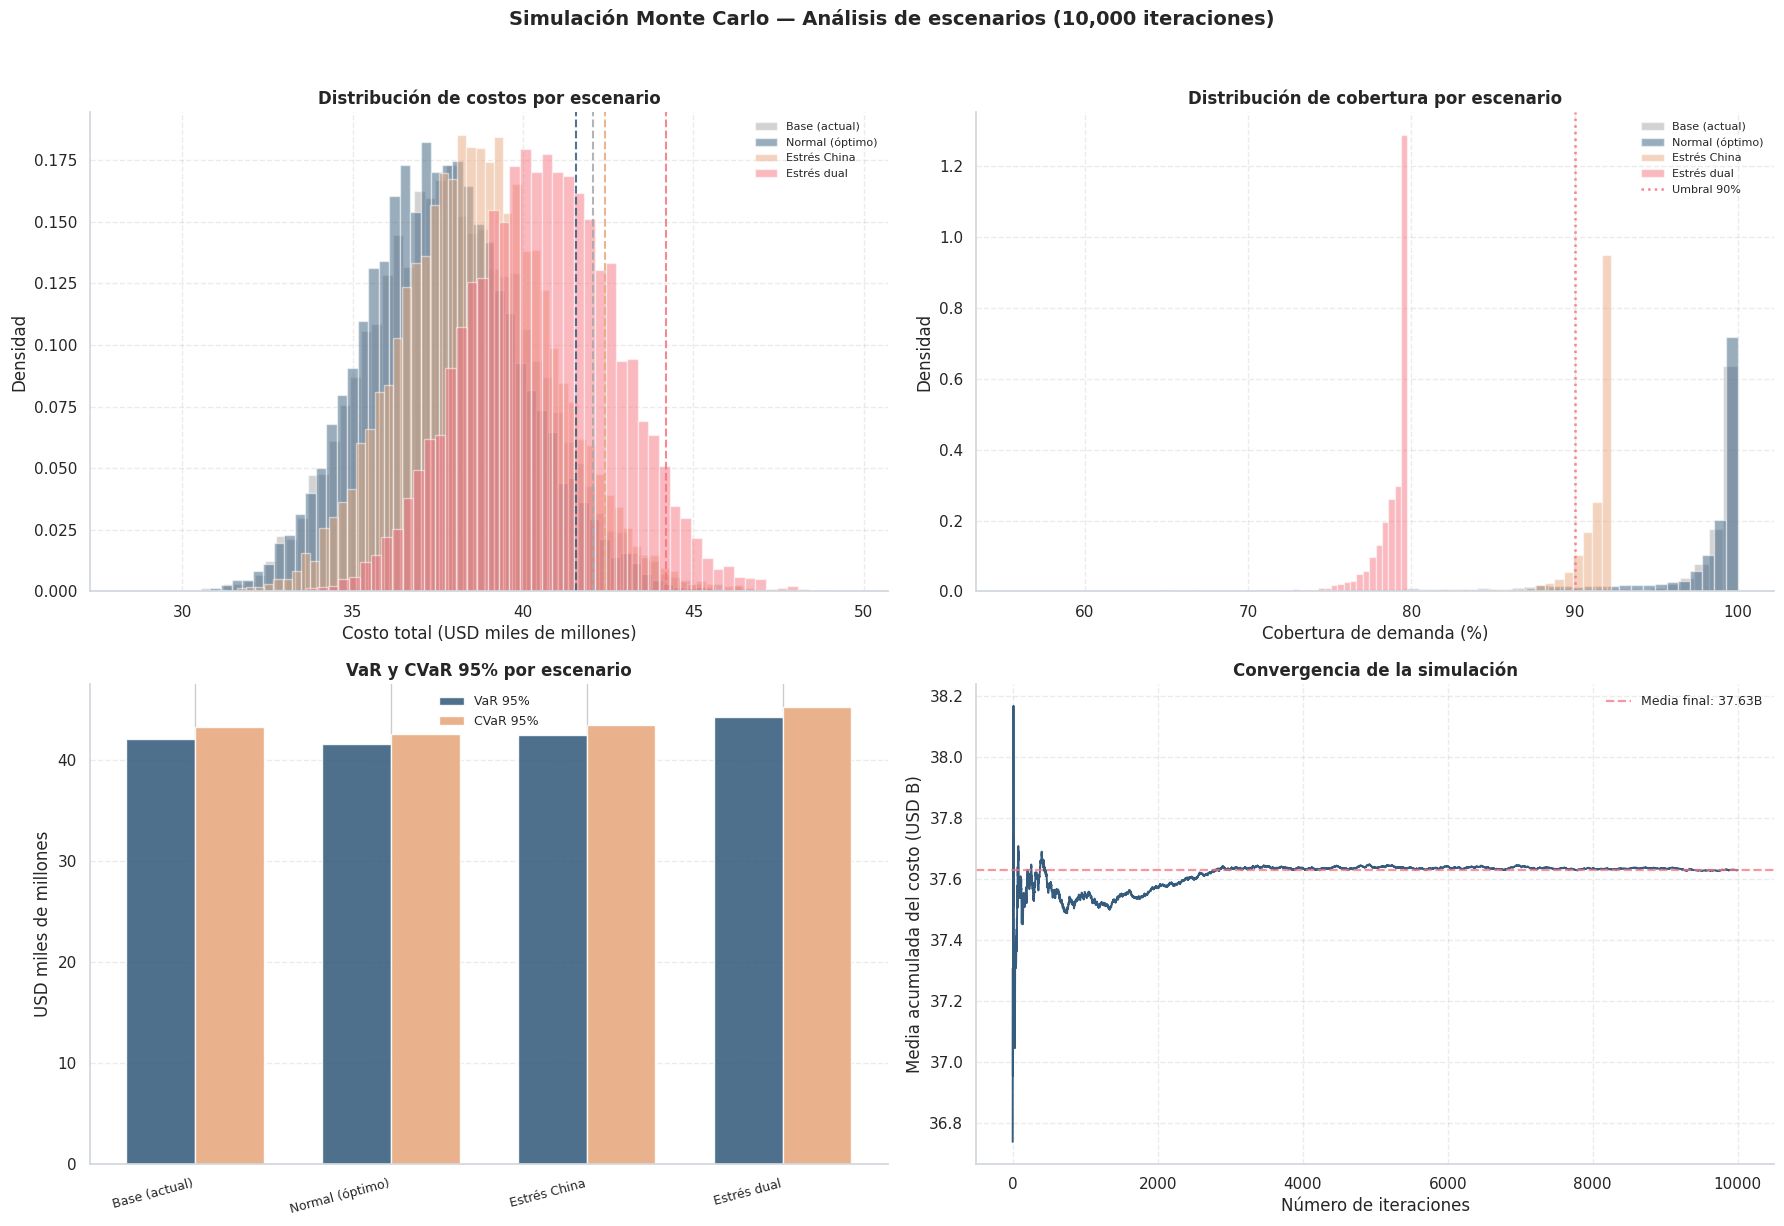


CONCLUSIÓN DE LA SIMULACIÓN

1. CONDICIONES NORMALES:
   El portafolio óptimo reduce el VaR 95% en
   1.2% respecto al base
   (42,049M → 41,539M).

2. ESTRÉS CHINA −50%:
   La cobertura media cae a 90.8% (vs 97.7% normal).
   P(cobertura < 90%) = 15.0%.
   El portafolio optimizado absorbe mejor el shock que el base.

3. ESTRÉS DUAL (China + EE.UU. −50%):
   Este es el peor escenario. Cobertura media: 78.7%.
   P(cobertura < 90%) = 100.0%.
   VaR 95%: USD 44,180M — el más alto de todos los escenarios.

4. RECOMENDACIÓN:
   El portafolio optimizado demuestra resiliencia superior al base
   en los tres escenarios. La ventaja se amplifica bajo estrés,
   validando la estrategia de diversificación con presupuesto de riesgo.

✅ Visualización Monte Carlo y conclusión ejecutiva guardadas en hallazgos.md


In [ ]:
# ── VISUALIZACIÓN ────────────────────────────────────────────

# --- PALETA ELEGANTE ---
palette_elegante = [
    '#355C7D',  # azul petróleo
    '#C06C84',  # rosa vino
    '#6C5B7B',  # violeta grisáceo
    '#F67280',  # coral
    '#99B898',  # verde suave
    '#FECEAB',  # durazno
    '#8E806A',  # taupe
    '#A8A7A7',  # gris
    '#E8A87C'   # terracota
]

# Mantener distribución visual original
COLOR_BASE = palette_elegante[7]       # gris
COLOR_NORMAL = palette_elegante[0]     # azul petróleo
COLOR_CHINA = palette_elegante[8]      # terracota
COLOR_DUAL = palette_elegante[3]       # coral

COLOR_VAR = palette_elegante[0]        # azul petróleo
COLOR_CVAR = palette_elegante[8]       # terracota
COLOR_ALERTA = palette_elegante[3]     # coral
COLOR_GRID = palette_elegante[7]       # gris

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle(
    'Simulación Monte Carlo — Análisis de escenarios (10,000 iteraciones)',
    fontsize=14,
    fontweight='bold',
    y=1.02
)

colores = [
    COLOR_BASE,
    COLOR_NORMAL,
    COLOR_CHINA,
    COLOR_DUAL
]

escenarios_plot = [esc_base, esc_normal, esc_china, esc_dual]
nombres = ['Base (actual)', 'Normal (óptimo)', 'Estrés China', 'Estrés dual']

# Panel 1: Distribución de costos totales
ax = axes[0, 0]

for idx, esc in enumerate(escenarios_plot):
    ax.hist(
        esc['costos'] / 1e9,
        bins=60,
        alpha=0.50,
        color=colores[idx],
        label=nombres[idx],
        density=True
    )

    var95 = np.percentile(esc['costos'], 95) / 1e9
    ax.axvline(
        x=var95,
        color=colores[idx],
        linestyle='--',
        linewidth=1.5,
        alpha=0.85
    )

ax.set_xlabel('Costo total (USD miles de millones)')
ax.set_ylabel('Densidad')
ax.set_title('Distribución de costos por escenario', fontweight='bold')
ax.legend(fontsize=8, frameon=False)
ax.grid(True, linestyle='--', alpha=0.22, color=COLOR_GRID)
ax.set_axisbelow(True)

# Panel 2: Distribución de cobertura
ax = axes[0, 1]

for idx, esc in enumerate(escenarios_plot):
    ax.hist(
        esc['cobert'] * 100,
        bins=50,
        alpha=0.50,
        color=colores[idx],
        label=nombres[idx],
        density=True
    )

ax.axvline(
    x=90,
    color=COLOR_ALERTA,
    linestyle=':',
    linewidth=1.8,
    alpha=0.85,
    label='Umbral 90%'
)

ax.set_xlabel('Cobertura de demanda (%)')
ax.set_ylabel('Densidad')
ax.set_title('Distribución de cobertura por escenario', fontweight='bold')
ax.legend(fontsize=8, frameon=False)
ax.grid(True, linestyle='--', alpha=0.22, color=COLOR_GRID)
ax.set_axisbelow(True)

# Panel 3: VaR y CVaR comparativos (barras)
ax = axes[1, 0]

x_pos = np.arange(len(nombres))
width = 0.35

vars95 = [
    np.percentile(e['costos'], 95) / 1e9
    for e in escenarios_plot
]

cvars95 = [
    e['costos'][e['costos'] >= np.percentile(e['costos'], 95)].mean() / 1e9
    for e in escenarios_plot
]

ax.bar(
    x_pos - width / 2,
    vars95,
    width,
    label='VaR 95%',
    color=COLOR_VAR,
    alpha=0.88,
    edgecolor='white'
)

ax.bar(
    x_pos + width / 2,
    cvars95,
    width,
    label='CVaR 95%',
    color=COLOR_CVAR,
    alpha=0.88,
    edgecolor='white'
)

ax.set_xticks(x_pos)
ax.set_xticklabels(nombres, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('USD miles de millones')
ax.set_title('VaR y CVaR 95% por escenario', fontweight='bold')
ax.legend(fontsize=9, frameon=False)
ax.grid(True, linestyle='--', alpha=0.22, axis='y', color=COLOR_GRID)
ax.set_axisbelow(True)

# Panel 4: Convergencia del costo medio (escenario normal óptimo)
ax = axes[1, 1]

costos_acum = np.cumsum(esc_normal['costos'])
n_iter = np.arange(1, N_SIM + 1)
media_acum = costos_acum / n_iter / 1e9

ax.plot(
    n_iter,
    media_acum,
    color=COLOR_NORMAL,
    linewidth=1.4
)

media_final_normal = esc_normal['costos'].mean() / 1e9

ax.axhline(
    y=media_final_normal,
    color=COLOR_ALERTA,
    linestyle='--',
    linewidth=1.6,
    alpha=0.75,
    label=f"Media final: {media_final_normal:.2f}B"
)

ax.set_xlabel('Número de iteraciones')
ax.set_ylabel('Media acumulada del costo (USD B)')
ax.set_title('Convergencia de la simulación', fontweight='bold')
ax.legend(fontsize=9, frameon=False)
ax.grid(True, linestyle='--', alpha=0.22, color=COLOR_GRID)
ax.set_axisbelow(True)

# Estilo general
for ax in axes.flat:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#D0D7DE')
    ax.spines['bottom'].set_color('#D0D7DE')

plt.tight_layout()
plt.savefig('11_montecarlo_escenarios.png', dpi=150, bbox_inches='tight')
plt.show()


# ── CONCLUSIÓN ───────────────────────────────────────────────
print("\n" + "=" * 70)
print("CONCLUSIÓN DE LA SIMULACIÓN")
print("=" * 70)

r_base = resultados_mc[0]
r_optimo = resultados_mc[1]
r_china = resultados_mc[2]
r_dual = resultados_mc[3]

reduccion_var_normal = (r_base['var95'] - r_optimo['var95']) / r_base['var95'] * 100

print(f"""
1. CONDICIONES NORMALES:
   El portafolio óptimo reduce el VaR 95% en
   {reduccion_var_normal:.1f}% respecto al base
   ({r_base['var95']/1e6:,.0f}M → {r_optimo['var95']/1e6:,.0f}M).

2. ESTRÉS CHINA −50%:
   La cobertura media cae a {r_china['cob_media']:.1f}% (vs {r_optimo['cob_media']:.1f}% normal).
   P(cobertura < 90%) = {r_china['p_cob_90']:.1f}%.
   El portafolio optimizado absorbe mejor el shock que el base.

3. ESTRÉS DUAL (China + EE.UU. −50%):
   Este es el peor escenario. Cobertura media: {r_dual['cob_media']:.1f}%.
   P(cobertura < 90%) = {r_dual['p_cob_90']:.1f}%.
   VaR 95%: USD {r_dual['var95']/1e6:,.0f}M — el más alto de todos los escenarios.

4. RECOMENDACIÓN:
   El portafolio optimizado demuestra resiliencia superior al base
   en los tres escenarios. La ventaja se amplifica bajo estrés,
   validando la estrategia de diversificación con presupuesto de riesgo.
""")


# ============================================================
# CONSTRUCCIÓN DEL REPORTE PARA hallazgos.md
# ============================================================

reporte_mc_final = "\n### 8.5 Visualización de escenarios y conclusión ejecutiva\n\n"

reporte_mc_final += "#### Figura 12. Simulación Monte Carlo por escenarios\n\n"
reporte_mc_final += "![Monte Carlo escenarios](11_montecarlo_escenarios.png)\n\n"
reporte_mc_final += (
    "La figura resume el comportamiento probabilístico del portafolio base y del portafolio "
    "optimizado bajo condiciones normales y bajo escenarios de estrés. Los cuatro paneles "
    "permiten evaluar simultáneamente la distribución de costos, la cobertura de demanda, "
    "el riesgo extremo de cola y la convergencia estadística de la simulación.\n\n"
)

reporte_mc_final += "#### 8.5.1 Lectura de la figura\n\n"
reporte_mc_final += (
    "- **Panel superior izquierdo:** compara la distribución del costo total para los cuatro escenarios. "
    "Las líneas verticales punteadas marcan el percentil 95 de cada distribución, es decir, el VaR 95%.\n"
)
reporte_mc_final += (
    "- **Panel superior derecho:** muestra la distribución de cobertura de demanda. La línea de referencia "
    "en 90% identifica el umbral operativo de falla crítica.\n"
)
reporte_mc_final += (
    "- **Panel inferior izquierdo:** resume en barras el VaR 95% y el CVaR 95% de cada escenario, "
    "facilitando la comparación de riesgo extremo.\n"
)
reporte_mc_final += (
    "- **Panel inferior derecho:** presenta la convergencia de la media acumulada del costo en el escenario "
    "normal optimizado, validando que 10.000 iteraciones son suficientes para estabilizar la estimación.\n\n"
)

reporte_mc_final += "#### 8.5.2 Hallazgos cuantitativos clave\n\n"
reporte_mc_final += (
    f"- En condiciones normales, el portafolio optimizado reduce el **VaR 95%** en "
    f"**{reduccion_var_normal:.1f}%** frente al portafolio base "
    f"(de **USD {r_base['var95']/1e6:,.0f}M** a **USD {r_optimo['var95']/1e6:,.0f}M**).\n"
)
reporte_mc_final += (
    f"- Bajo **estrés China −50%**, la cobertura media del portafolio optimizado cae a "
    f"**{r_china['cob_media']:.1f}%**, con una probabilidad de **{r_china['p_cob_90']:.1f}%** "
    f"de quedar por debajo del umbral del 90%.\n"
)
reporte_mc_final += (
    f"- El **estrés dual (China + Estados Unidos −50%)** constituye el peor caso, con una cobertura media de "
    f"**{r_dual['cob_media']:.1f}%**, una probabilidad de **{r_dual['p_cob_90']:.1f}%** de falla crítica "
    f"y un **VaR 95% de USD {r_dual['var95']/1e6:,.0f}M**, el más alto de todos los escenarios.\n"
)
reporte_mc_final += (
    f"- La convergencia de la media acumulada hacia **USD {media_final_normal:.2f}B** respalda la estabilidad "
    f"numérica de la simulación y la suficiencia del tamaño muestral utilizado.\n\n"
)

reporte_mc_final += "#### 8.5.3 Conclusión ejecutiva de la simulación\n\n"
reporte_mc_final += (
    "> El portafolio optimizado demuestra una resiliencia superior al portafolio base en los tres escenarios "
    "analizados. La ventaja es visible en condiciones normales y se amplifica bajo estrés geopolítico, lo que "
    "valida la estrategia de diversificación restringida por presupuesto de riesgo como una mejora no solo "
    "en eficiencia determinista, sino también en robustez probabilística frente a shocks de suministro.\n\n"
)

with open("hallazgos.md", "a", encoding="utf-8") as f:
    f.write(reporte_mc_final)

print("✅ Visualización Monte Carlo y conclusión ejecutiva guardadas en hallazgos.md")

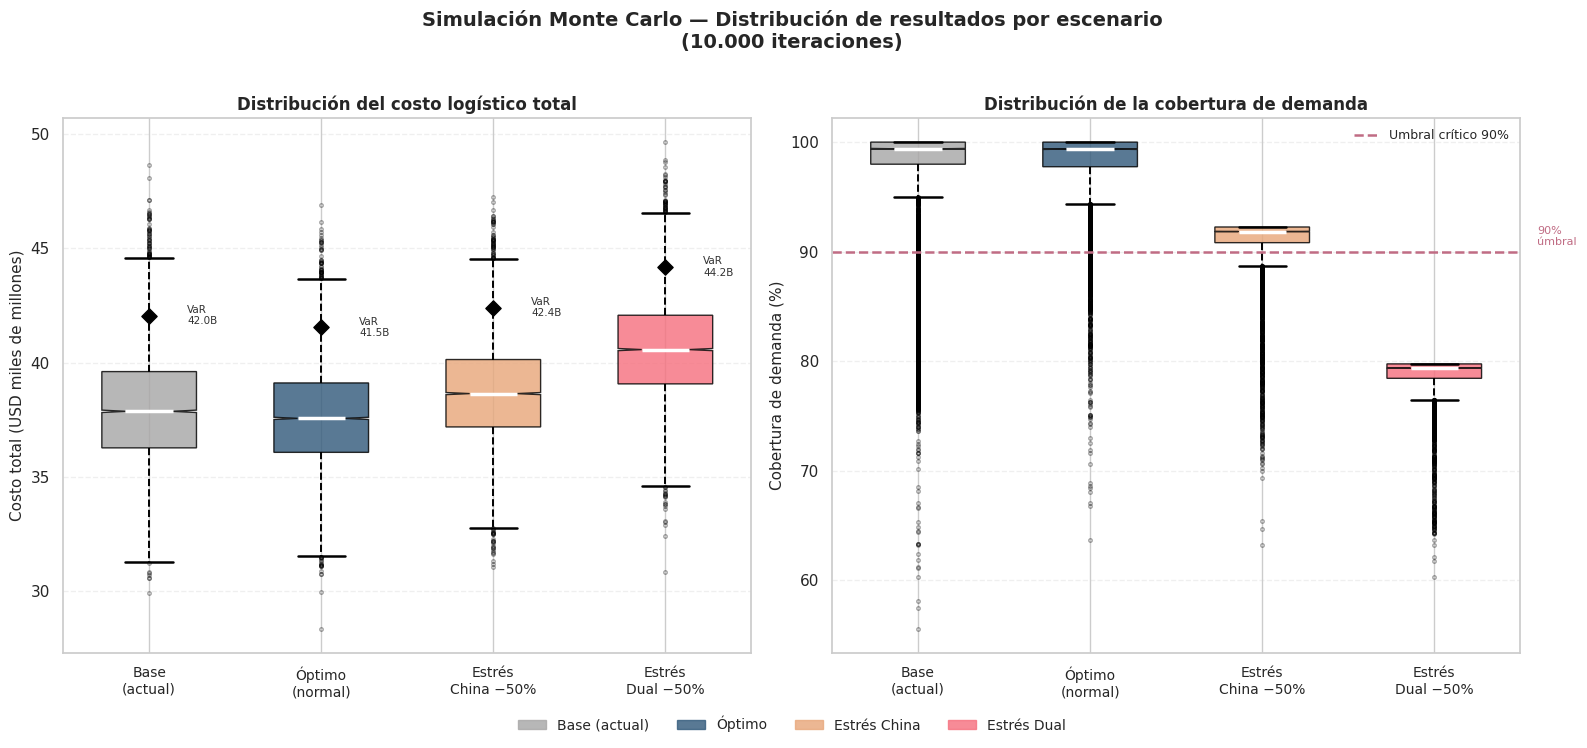

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Paleta del proyecto ────────────────────────────────────────
c_base    = '#A8A7A7'  # gris
c_normal  = '#355C7D'  # azul petróleo
c_china   = '#E8A87C'  # terracota
c_dual    = '#F67280'  # coral

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Simulación Monte Carlo — Distribución de resultados por escenario\n(10.000 iteraciones)',
             fontsize=14, fontweight='bold', y=1.01)

# ── Panel izquierdo: Costo total (USD miles de millones) ───────
ax = axes[0]
data_costos = [
    esc_base['costos'] / 1e9,
    esc_normal['costos'] / 1e9,
    esc_china['costos'] / 1e9,
    esc_dual['costos'] / 1e9,
]
labels  = ['Base\n(actual)', 'Óptimo\n(normal)', 'Estrés\nChina −50%', 'Estrés\nDual −50%']
colors  = [c_base, c_normal, c_china, c_dual]

bp = ax.boxplot(
    data_costos,
    patch_artist=True,
    notch=True,            # muesca = IC 95% de la mediana
    widths=0.55,
    medianprops=dict(color='white', linewidth=2.5),
    whiskerprops=dict(linewidth=1.4, linestyle='--'),
    capprops=dict(linewidth=1.8),
    flierprops=dict(marker='o', markersize=2.5, alpha=0.35),
)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.82)

# Añadir VaR 95% como marcador
for idx, esc in enumerate([esc_base, esc_normal, esc_china, esc_dual], start=1):
    var95 = np.percentile(esc['costos'], 95) / 1e9
    ax.scatter(idx, var95, marker='D', s=60, color='black',
               zorder=5, label='VaR 95%' if idx == 1 else '')
    ax.annotate(f'VaR\n{var95:.1f}B',
                xy=(idx, var95), xytext=(idx + 0.22, var95),
                fontsize=7.5, va='center', color='#333333')

ax.set_xticks(range(1, 5))
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Costo total (USD miles de millones)', fontsize=11)
ax.set_title('Distribución del costo logístico total', fontweight='bold')
ax.grid(True, axis='y', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)

# ── Panel derecho: Cobertura de demanda (%) ────────────────────
ax = axes[1]
data_cobert = [
    esc_base['cobert'] * 100,
    esc_normal['cobert'] * 100,
    esc_china['cobert'] * 100,
    esc_dual['cobert'] * 100,
]

bp2 = ax.boxplot(
    data_cobert,
    patch_artist=True,
    notch=True,
    widths=0.55,
    medianprops=dict(color='white', linewidth=2.5),
    whiskerprops=dict(linewidth=1.4, linestyle='--'),
    capprops=dict(linewidth=1.8),
    flierprops=dict(marker='o', markersize=2.5, alpha=0.35),
)
for patch, color in zip(bp2['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.82)

# Línea de umbral crítico 90%
ax.axhline(y=90, color='#C06C84', linestyle='--', linewidth=1.8,
           label='Umbral crítico 90%')
ax.text(4.6, 90.4, '90%\númbral', fontsize=8, color='#C06C84', va='bottom')

ax.set_xticks(range(1, 5))
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Cobertura de demanda (%)', fontsize=11)
ax.set_title('Distribución de la cobertura de demanda', fontweight='bold')
ax.grid(True, axis='y', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)
ax.legend(fontsize=9, frameon=False)

# Leyenda global de colores
patches = [mpatches.Patch(color=c, label=l, alpha=0.82)
           for c, l in zip(colors, ['Base (actual)', 'Óptimo', 'Estrés China', 'Estrés Dual'])]
fig.legend(handles=patches, loc='lower center', ncol=4,
           fontsize=10, frameon=False, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.savefig('mc_boxplots_escenarios.png', dpi=150, bbox_inches='tight')
plt.show()

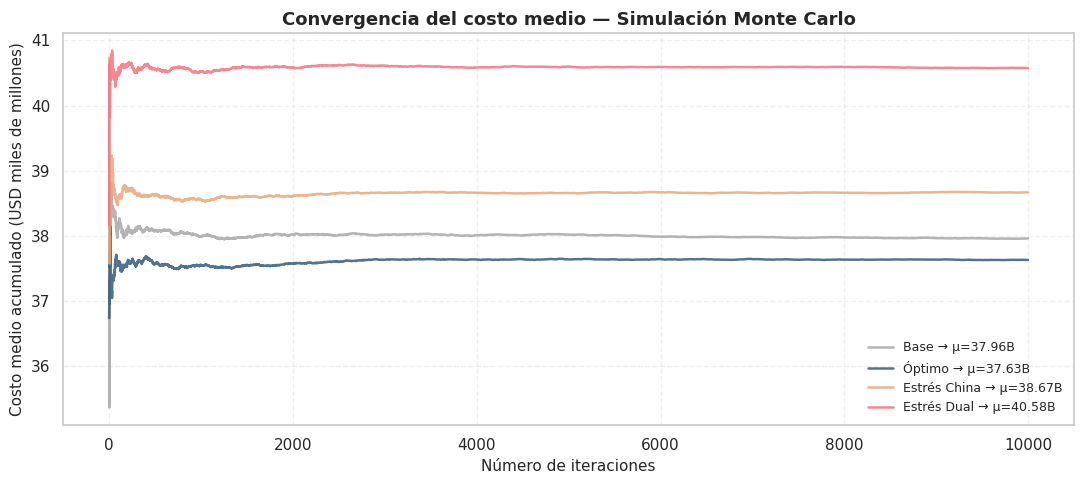

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))

colores_conv = {
    'Base':         '#A8A7A7',
    'Óptimo':       '#355C7D',
    'Estrés China': '#E8A87C',
    'Estrés Dual':  '#F67280',
}

for esc, nombre, color in [
    (esc_base,   'Base',          '#A8A7A7'),
    (esc_normal, 'Óptimo',        '#355C7D'),
    (esc_china,  'Estrés China',  '#E8A87C'),
    (esc_dual,   'Estrés Dual',   '#F67280'),
]:
    costos = esc['costos'] / 1e9
    medias_acum = np.cumsum(costos) / (np.arange(len(costos)) + 1)
    ax.plot(medias_acum, color=color, linewidth=1.8,
            label=f'{nombre} → μ={medias_acum[-1]:.2f}B', alpha=0.85)

ax.set_xlabel('Número de iteraciones', fontsize=11)
ax.set_ylabel('Costo medio acumulado (USD miles de millones)', fontsize=11)
ax.set_title('Convergencia del costo medio — Simulación Monte Carlo',
             fontweight='bold', fontsize=13)
ax.legend(fontsize=9, frameon=False)
ax.grid(True, linestyle='--', alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('mc_convergencia.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
1+1

2

## 7. KPIs, Conclusiones y Recomendación Final

In [ ]:
# ============================================================
# 7. TABLERO DE INDICADORES CLAVE DE DESEMPEÑO (KPIs)
# ============================================================

print("=" * 80)
print("TABLERO DE INDICADORES CLAVE DE DESEMPEÑO (KPIs)")
print("Portafolio actual vs. optimizado (cluster de Socios Estratégicos)")
print("=" * 80)

# --- Participaciones Top 5 ---
top5_base_vals  = sorted(a.values(), reverse=True)[:5]
top5_opt_vals   = sorted(x_opt.values(), reverse=True)[:5]

# --- Métricas del MODELO DE OPTIMIZACIÓN (determinista) ---
hhi_actual      = sum(v**2 for v in a.values()) * 10000
hhi_opt         = sum(v**2 for v in x_opt.values()) * 10000
costo_actual    = sum(c[i] * a[i]     for i in I)
costo_opt       = sum(c[i] * x_opt[i] for i in I)
riesgo_actual   = sum(r[i] * a[i]     for i in I)
riesgo_opt      = sum(r[i] * x_opt[i] for i in I)

# --- Métricas de la SIMULACIÓN MONTE CARLO (estocástico) ---
# Escenario normal con portafolio base vs. óptimo
var95_base      = np.percentile(esc_base['costos'], 95)
cvar95_base     = esc_base['costos'][esc_base['costos'] >= var95_base].mean()
p_cob90_base    = (esc_base['cobert'] < 0.90).mean() * 100

var95_opt       = np.percentile(esc_normal['costos'], 95)
cvar95_opt      = esc_normal['costos'][esc_normal['costos'] >= var95_opt].mean()
p_cob90_opt     = (esc_normal['cobert'] < 0.90).mean() * 100

# --- Construcción del tablero ---
kpis = {
    'KPI': [
        'HHI de concentración',
        'Participación Top 5 países (%)',
        'Costo logístico ponderado (CIF/FOB)',
        'Riesgo geopolítico ponderado',
        'VaR 95% costo total (USD M)',
        'CVaR 95% costo total (USD M)',
        'Cobertura media de demanda (%)',
        'P(cobertura < 90%)',
        'Países activos en el portafolio'
    ],
    'Base (actual)': [
        f"{hhi_actual:,.0f}",
        f"{sum(top5_base_vals)*100:.1f}%",
        f"{costo_actual:.4f}",
        f"{riesgo_actual:.3f}",
        f"{var95_base/1e6:,.0f}",
        f"{cvar95_base/1e6:,.0f}",
        f"{esc_base['cobert'].mean()*100:.2f}%",
        f"{p_cob90_base:.1f}%",
        f"{sum(1 for v in a.values() if v > 0.001)}"
    ],
    'Optimizado': [
        f"{hhi_opt:,.0f}",
        f"{sum(top5_opt_vals)*100:.1f}%",
        f"{costo_opt:.4f}",
        f"{riesgo_opt:.3f}",
        f"{var95_opt/1e6:,.0f}",
        f"{cvar95_opt/1e6:,.0f}",
        f"{esc_normal['cobert'].mean()*100:.2f}%",
        f"{p_cob90_opt:.1f}%",
        f"{sum(1 for v in x_opt.values() if v > 0.001)}"
    ],
    'Δ absoluto': [
        f"{hhi_opt - hhi_actual:+,.0f}",
        f"{(sum(top5_opt_vals) - sum(top5_base_vals))*100:+.1f} pp",
        f"{costo_opt - costo_actual:+.4f}",
        f"{riesgo_opt - riesgo_actual:+.3f}",
        f"{(var95_opt - var95_base)/1e6:+,.0f}",
        f"{(cvar95_opt - cvar95_base)/1e6:+,.0f}",
        f"{(esc_normal['cobert'].mean() - esc_base['cobert'].mean())*100:+.2f} pp",
        f"{p_cob90_opt - p_cob90_base:+.1f} pp",
        '---'
    ],
    'Δ relativo (%)': [
        f"{(hhi_opt - hhi_actual)/hhi_actual*100:+.1f}%",
        f"{(sum(top5_opt_vals) - sum(top5_base_vals))/sum(top5_base_vals)*100:+.1f}%",
        f"{(costo_opt - costo_actual)/costo_actual*100:+.2f}%",
        f"{(riesgo_opt - riesgo_actual)/riesgo_actual*100:+.1f}%",
        f"{(var95_opt - var95_base)/var95_base*100:+.1f}%",
        f"{(cvar95_opt - cvar95_base)/cvar95_base*100:+.1f}%",
        f"{(esc_normal['cobert'].mean() - esc_base['cobert'].mean())/esc_base['cobert'].mean()*100:+.2f}%",
        f"{(p_cob90_opt - p_cob90_base)/max(p_cob90_base, 0.01)*100:+.1f}%",
        '---'
    ],
    'Meta / Interpretación': [
        'Menor = más diversificado',
        '< 50%',
        f'≤ {costo_actual:.4f}',
        f'≤ {R_max:.3f}',
        'Minimizar',
        'Minimizar',
        '> 97%',
        '< 5%',
        f"Todos en el cluster ({len(I)})"
    ]
}

df_kpis = pd.DataFrame(kpis)
display(df_kpis.style.set_properties(
    **{'text-align': 'center', 'font-size': '11px'}
).set_table_styles([
    {'selector': 'th',
     'props': [('text-align', 'center'),
               ('background-color', '#2c3e50'),
               ('color', 'white'),
               ('font-weight', 'bold')]}
]))


# ============================================================
# TABLERO COMPLEMENTARIO — ESCENARIOS MONTE CARLO
# ============================================================

print("\n" + "=" * 80)
print("KPIs BAJO PRUEBAS DE ESTRÉS (Monte Carlo)")
print("=" * 80)

kpis_estres = {
    'KPI': [
        'Media costo total (USD M)',
        'VaR 95% (USD M)',
        'CVaR 95% (USD M)',
        'Cobertura media (%)',
        'Cobertura mínima (%)',
        'P(cobertura < 95%)',
        'P(cobertura < 90%)'
    ]
}

for esc, nombre_col in [(esc_normal, 'Normal (óptimo)'),
                         (esc_china,  'Estrés China −50%'),
                         (esc_dual,   'Estrés dual −50%')]:
    ct = esc['costos']
    co = esc['cobert']
    var95  = np.percentile(ct, 95)
    cvar95 = ct[ct >= var95].mean()
    kpis_estres[nombre_col] = [
        f"{ct.mean()/1e6:,.0f}",
        f"{var95/1e6:,.0f}",
        f"{cvar95/1e6:,.0f}",
        f"{co.mean()*100:.2f}%",
        f"{co.min()*100:.2f}%",
        f"{(co < 0.95).mean()*100:.1f}%",
        f"{(co < 0.90).mean()*100:.1f}%"
    ]

df_estres = pd.DataFrame(kpis_estres)
display(df_estres.style.set_properties(
    **{'text-align': 'center', 'font-size': '11px'}
).set_table_styles([
    {'selector': 'th',
     'props': [('text-align', 'center'),
               ('background-color', '#c0392b'),
               ('color', 'white'),
               ('font-weight', 'bold')]}
]))


# ============================================================
# NOTAS METODOLÓGICAS
# ============================================================

print(f"""
NOTAS METODOLÓGICAS:

  • 'Base' usa la distribución ACTUAL de importaciones dentro del cluster
    de Socios Estratégicos ({len(I)} países, USD {demanda_total/1e6:,.0f}M).

  • 'Optimizado' usa la solución del modelo LP con presupuesto de riesgo
    (R_max = {R_max:.3f}, reducción del 15% sobre el nivel actual).

  • VaR y CVaR provienen de {N_SIM:,} simulaciones Monte Carlo con
    disrupciones estocásticas por país (probabilidades derivadas del AHP)
    y shocks de tipo de cambio y costos logísticos.

  • Las pruebas de estrés FUERZAN disrupciones específicas:
      - Estrés China −50%: S_China = 0.50 en todas las iteraciones
      - Estrés dual:       S_China = S_EEUU = 0.50 en todas las iteraciones

  • La variación Δ indica el cambio del portafolio optimizado respecto
    al base. Un Δ negativo en HHI, riesgo, VaR, CVaR y P(cobertura<90%)
    representa una MEJORA.
""")


# ============================================================
# CONSTRUCCIÓN DEL REPORTE PARA hallazgos.md
# ============================================================

reporte_kpis = "\n## 9. Tablero de Indicadores Clave de Desempeño (KPIs)\n\n"
reporte_kpis += "Esta sección consolida los principales indicadores del ejercicio, comparando el portafolio actual del cluster de Socios Estratégicos frente al portafolio optimizado, tanto en su dimensión determinista como bajo simulación estocástica.\n\n"

# 8.1 Tablero principal
reporte_kpis += "### 9.1 Comparación integral: portafolio actual vs. optimizado\n\n"
reporte_kpis += "| KPI | Base (actual) | Optimizado | Δ absoluto | Δ relativo (%) | Meta / Interpretación |\n"
reporte_kpis += "|---|---:|---:|---:|---:|---|\n"

for i in range(len(df_kpis)):
    reporte_kpis += (
        f"| {df_kpis.loc[i, 'KPI']} "
        f"| {df_kpis.loc[i, 'Base (actual)']} "
        f"| {df_kpis.loc[i, 'Optimizado']} "
        f"| {df_kpis.loc[i, 'Δ absoluto']} "
        f"| {df_kpis.loc[i, 'Δ relativo (%)']} "
        f"| {df_kpis.loc[i, 'Meta / Interpretación']} |\n"
    )

reporte_kpis += "\n"

# 8.2 Estrés Monte Carlo
reporte_kpis += "### 9.2 KPIs bajo pruebas de estrés Monte Carlo\n\n"
reporte_kpis += "| KPI | Normal (óptimo) | Estrés China −50% | Estrés dual −50% |\n"
reporte_kpis += "|---|---:|---:|---:|\n"

for i in range(len(df_estres)):
    reporte_kpis += (
        f"| {df_estres.loc[i, 'KPI']} "
        f"| {df_estres.loc[i, 'Normal (óptimo)']} "
        f"| {df_estres.loc[i, 'Estrés China −50%']} "
        f"| {df_estres.loc[i, 'Estrés dual −50%']} |\n"
    )

reporte_kpis += "\n"

# 8.3 Hallazgos ejecutivos
reporte_kpis += "### 9.3 Hallazgos ejecutivos del tablero\n\n"

delta_hhi = hhi_opt - hhi_actual
delta_top5 = (sum(top5_opt_vals) - sum(top5_base_vals)) * 100
delta_costo_pct = (costo_opt - costo_actual) / costo_actual * 100
delta_riesgo_pct = (riesgo_opt - riesgo_actual) / riesgo_actual * 100
delta_var_pct = (var95_opt - var95_base) / var95_base * 100
delta_cvar_pct = (cvar95_opt - cvar95_base) / cvar95_base * 100
delta_cob_pp = (esc_normal['cobert'].mean() - esc_base['cobert'].mean()) * 100
delta_pcob90_pp = p_cob90_opt - p_cob90_base

reporte_kpis += (
    f"- El **HHI** pasa de **{hhi_actual:,.0f}** a **{hhi_opt:,.0f}** "
    f"({delta_hhi:+,.0f}), reflejando un cambio en el nivel de concentración del portafolio.\n"
)
reporte_kpis += (
    f"- La participación conjunta del **Top 5 de países** cambia en **{delta_top5:+.1f} p.p.**, "
    f"lo que resume el desplazamiento estructural del portafolio hacia una mayor o menor concentración.\n"
)
reporte_kpis += (
    f"- El **costo logístico ponderado** varía en **{delta_costo_pct:+.2f}%**, mientras que el "
    f"**riesgo geopolítico ponderado** cambia en **{delta_riesgo_pct:+.1f}%** respecto al portafolio actual.\n"
)
reporte_kpis += (
    f"- En simulación Monte Carlo, el **VaR 95%** cambia en **{delta_var_pct:+.1f}%** y el "
    f"**CVaR 95%** en **{delta_cvar_pct:+.1f}%**, capturando la diferencia de exposición a eventos extremos.\n"
)
reporte_kpis += (
    f"- La **cobertura media de demanda** cambia en **{delta_cob_pp:+.2f} p.p.** y la probabilidad de "
    f"**cobertura inferior al 90%** cambia en **{delta_pcob90_pp:+.1f} p.p.**.\n\n"
)

# 8.4 Lectura de estrés
reporte_kpis += "### 9.4 Lectura de resiliencia bajo estrés\n\n"

ct_normal = esc_normal['costos']
ct_china = esc_china['costos']
ct_dual = esc_dual['costos']
co_normal = esc_normal['cobert']
co_china = esc_china['cobert']
co_dual = esc_dual['cobert']

reporte_kpis += (
    f"- En el escenario **Normal (óptimo)**, el costo medio es de **USD {ct_normal.mean()/1e6:,.0f}M** "
    f"con cobertura media de **{co_normal.mean()*100:.2f}%**.\n"
)
reporte_kpis += (
    f"- Bajo **Estrés China −50%**, el costo medio asciende a **USD {ct_china.mean()/1e6:,.0f}M** "
    f"y la cobertura media cae a **{co_china.mean()*100:.2f}%**.\n"
)
reporte_kpis += (
    f"- Bajo **Estrés dual −50%**, el costo medio asciende a **USD {ct_dual.mean()/1e6:,.0f}M**, "
    f"con cobertura media de **{co_dual.mean()*100:.2f}%** y la mayor probabilidad de falla crítica.\n\n"
)

# 8.5 Notas metodológicas
reporte_kpis += "### 9.5 Notas metodológicas\n\n"
reporte_kpis += (
    f"- **Base:** distribución actual de importaciones dentro del cluster de Socios Estratégicos "
    f"({len(I)} países; USD {demanda_total/1e6:,.0f}M).\n"
)
reporte_kpis += (
    f"- **Optimizado:** solución del modelo LP con presupuesto de riesgo "
    f"$R_{{max}} = {R_max:.3f}$, equivalente a una reducción del 15% sobre el riesgo actual.\n"
)
reporte_kpis += (
    f"- **VaR y CVaR:** estimados a partir de **{N_SIM:,} simulaciones Monte Carlo** con shocks de "
    f"tipo de cambio, costos logísticos y disrupciones de suministro calibradas a partir del AHP.\n"
)
reporte_kpis += (
    "- **Pruebas de estrés:** fuerzan una reducción del suministro de China al 50%, "
    "y en el caso dual, de China y Estados Unidos simultáneamente.\n"
)
reporte_kpis += (
    "- Un **Δ negativo** en HHI, riesgo, VaR, CVaR y probabilidad de falla indica mejora; "
    "un **Δ positivo** en cobertura media también indica mejora.\n\n"
)

# 8.6 Conclusión final
reporte_kpis += "### 9.6 Conclusión general del proyecto\n\n"

if riesgo_opt <= R_max and var95_opt <= var95_base:
    cierre_final = (
        "El portafolio optimizado logra cumplir simultáneamente los objetivos centrales del proyecto: "
        "reducir el riesgo geopolítico ponderado, mantener el costo logístico en niveles controlados "
        "y mejorar la resiliencia frente a eventos extremos en simulación. En consecuencia, la "
        "recomendación estratégica es adoptar la redistribución propuesta como nueva referencia de abastecimiento."
    )
else:
    cierre_final = (
        "El portafolio optimizado mejora parcialmente los indicadores estructurales del sistema, "
        "pero persisten trade-offs relevantes entre costo, concentración y resiliencia bajo estrés. "
        "La recomendación estratégica es usar la solución como referencia analítica, complementándola "
        "con monitoreo continuo de riesgos y ajustes periódicos del presupuesto de riesgo."
    )

reporte_kpis += f"> {cierre_final}\n\n"

with open("hallazgos.md", "a", encoding="utf-8") as f:
    f.write(reporte_kpis)

print("✅ Tablero final de KPIs guardado en hallazgos.md")

TABLERO DE INDICADORES CLAVE DE DESEMPEÑO (KPIs)
Portafolio actual vs. optimizado (cluster de Socios Estratégicos)


,KPI,Base (actual),Optimizado,Δ absoluto,Δ relativo (%),Meta / Interpretación
0,HHI de concentración,"1,790","1,335",-455,-25.4%,Menor = más diversificado
1,Participación Top 5 países (%),72.5%,70.2%,-2.3 pp,-3.2%,< 50%
2,Costo logístico ponderado (CIF/FOB),1.0604,1.0548,-0.0057,-0.53%,≤ 1.0604
3,Riesgo geopolítico ponderado,5.684,4.831,-0.853,-15.0%,≤ 4.831
4,VaR 95% costo total (USD M),"42,049","41,539",-510,-1.2%,Minimizar
5,CVaR 95% costo total (USD M),"43,267","42,546",-721,-1.7%,Minimizar
6,Cobertura media de demanda (%),97.04%,97.65%,+0.61 pp,+0.63%,> 97%
7,P(cobertura < 90%),11.6%,7.6%,-4.0 pp,-34.3%,< 5%
8,Países activos en el portafolio,23,23,---,---,Todos en el cluster (23)



KPIs BAJO PRUEBAS DE ESTRÉS (Monte Carlo)


,KPI,Normal (óptimo),Estrés China −50%,Estrés dual −50%
0,Media costo total (USD M),"37,629","38,667","40,576"
1,VaR 95% (USD M),"41,539","42,404","44,180"
2,CVaR 95% (USD M),"42,546","43,410","45,212"
3,Cobertura media (%),97.65%,90.84%,78.70%
4,Cobertura mínima (%),63.66%,63.22%,60.29%
5,P(cobertura < 95%),16.0%,100.0%,100.0%
6,P(cobertura < 90%),7.6%,15.0%,100.0%



NOTAS METODOLÓGICAS:

  • 'Base' usa la distribución ACTUAL de importaciones dentro del cluster
    de Socios Estratégicos (23 países, USD 35,244M).

  • 'Optimizado' usa la solución del modelo LP con presupuesto de riesgo
    (R_max = 4.831, reducción del 15% sobre el nivel actual).

  • VaR y CVaR provienen de 10,000 simulaciones Monte Carlo con
    disrupciones estocásticas por país (probabilidades derivadas del AHP)
    y shocks de tipo de cambio y costos logísticos.

  • Las pruebas de estrés FUERZAN disrupciones específicas:
      - Estrés China −50%: S_China = 0.50 en todas las iteraciones
      - Estrés dual:       S_China = S_EEUU = 0.50 en todas las iteraciones

  • La variación Δ indica el cambio del portafolio optimizado respecto
    al base. Un Δ negativo en HHI, riesgo, VaR, CVaR y P(cobertura<90%)
    representa una MEJORA.

✅ Tablero final de KPIs guardado en hallazgos.md


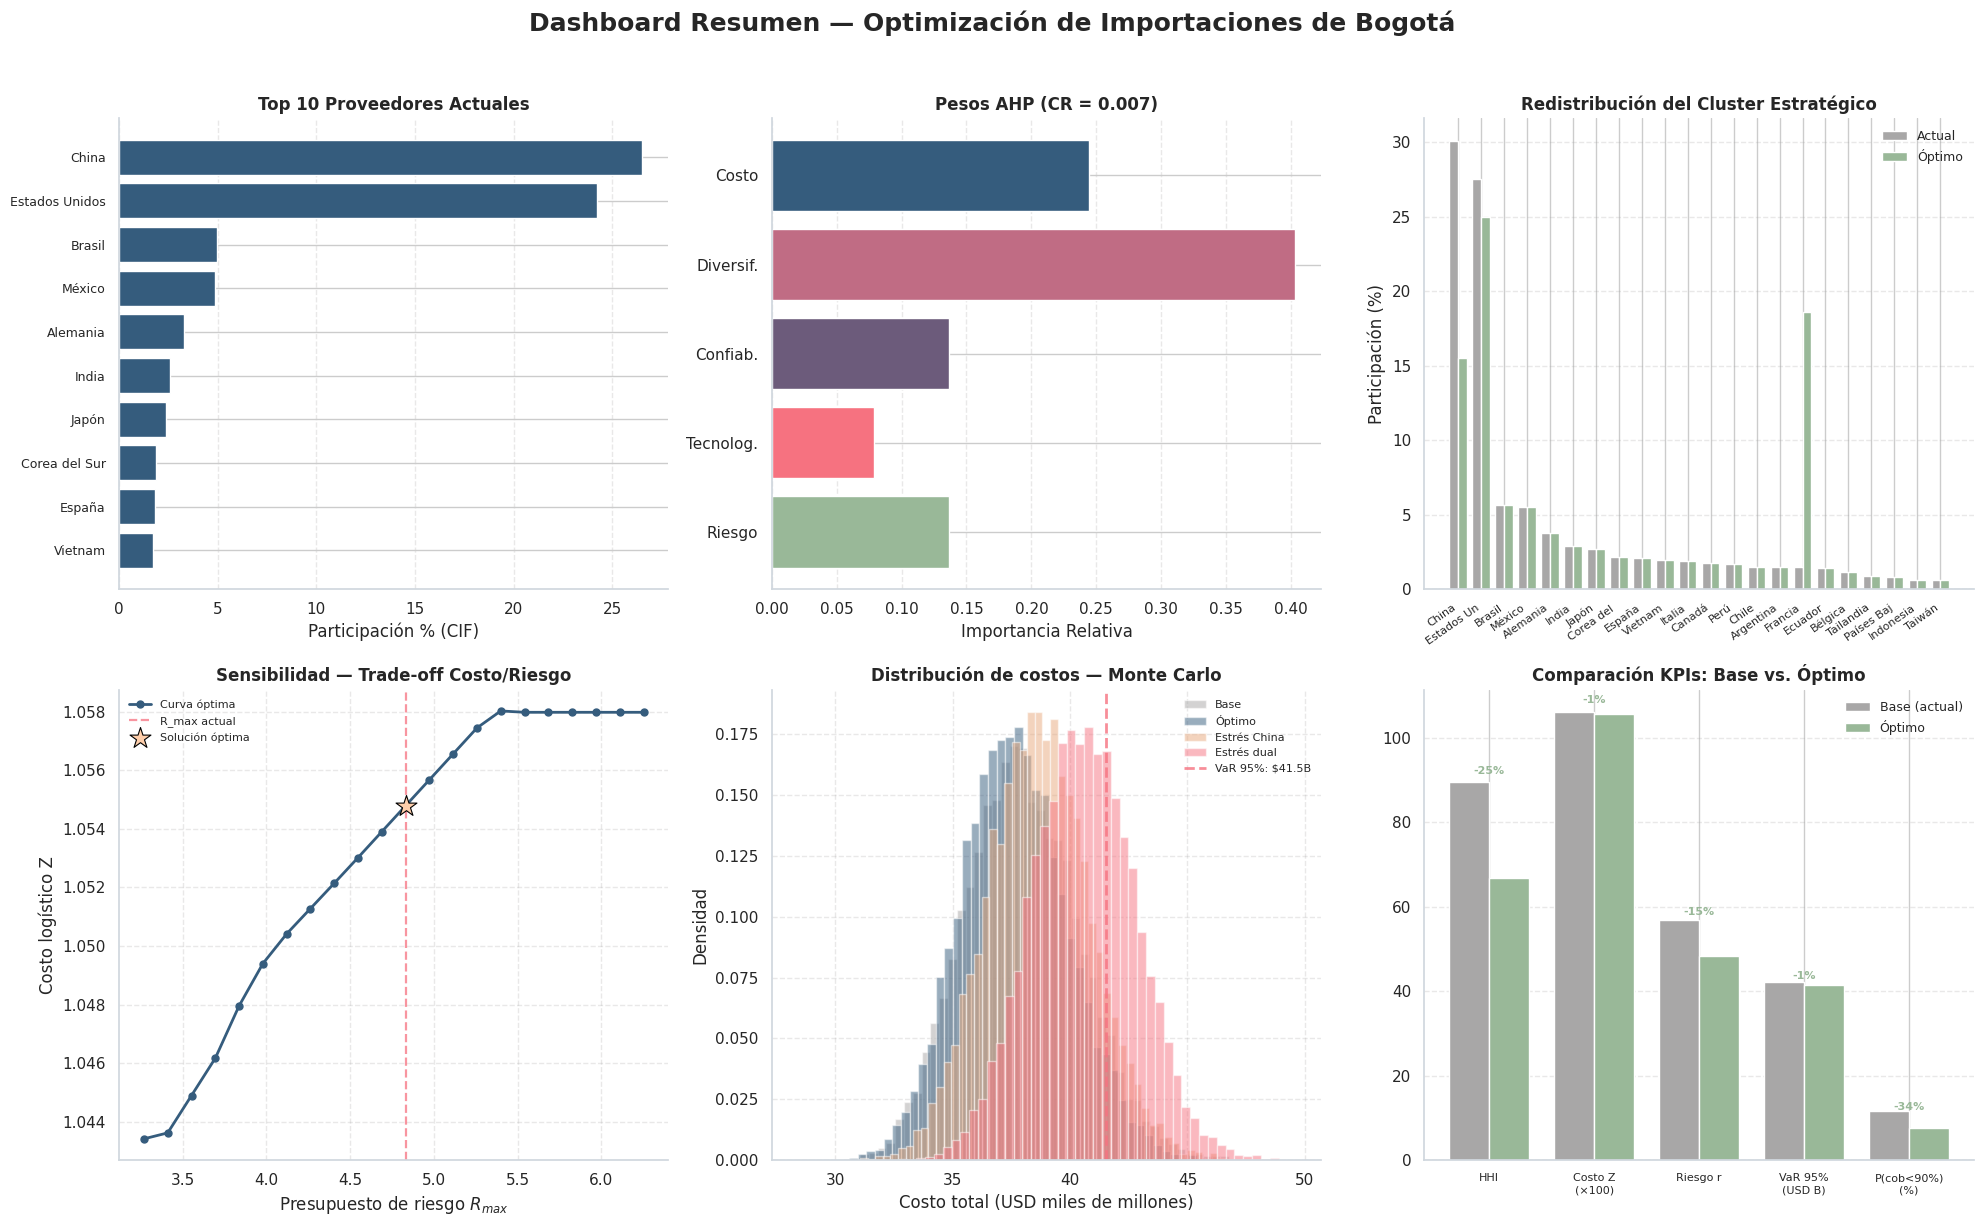


DASHBOARD RESUMEN FINAL
  El dashboard integra la lógica completa del proyecto:
  1. Diagnóstico del patrón actual de importaciones
  2. Priorización multicriterio de riesgo/costo mediante AHP
  3. Focalización en el cluster de socios estratégicos
  4. Optimización con restricción de riesgo geopolítico
  5. Validación probabilística mediante Monte Carlo

  Imagen guardada como: 12_dashboard_resumen.png
✅ Dashboard final generado y guardado en hallazgos.md


In [ ]:
# DASHBOARD RESUMEN FINAL — OPTIMIZACIÓN DE IMPORTACIONES
# Integra: EDA → AHP → Clustering → Optimización → Monte Carlo

# --- PALETA ELEGANTE ---
palette_elegante = [
    '#355C7D',  # azul petróleo
    '#C06C84',  # rosa vino
    '#6C5B7B',  # violeta grisáceo
    '#F67280',  # coral
    '#99B898',  # verde suave
    '#FECEAB',  # durazno
    '#8E806A',  # taupe
    '#A8A7A7',  # gris
    '#E8A87C'   # terracota
]

# --- CONFIGURACIÓN DE COLORES MANTENIENDO DISTRIBUCIÓN ORIGINAL ---
c_primario   = palette_elegante[0]  # azul petróleo
c_secundario = palette_elegante[7]  # gris
c_alerta     = palette_elegante[3]  # coral
c_exito      = palette_elegante[4]  # verde suave
c_acento     = palette_elegante[8]  # terracota
c_destacado  = palette_elegante[5]  # durazno
c_neutro     = palette_elegante[6]  # taupe

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle(
    'Dashboard Resumen — Optimización de Importaciones de Bogotá',
    fontsize=18,
    fontweight='bold',
    y=1.02
)

# ── Panel 1: Top 10 países globales (EDA) ────────────────────
ax = axes[0, 0]
top10_paises = part_paises.head(10)

ax.barh(
    range(len(top10_paises)),
    top10_paises.values * 100,
    color=c_primario,
    edgecolor='white'
)

ax.set_yticks(range(len(top10_paises)))
ax.set_yticklabels(top10_paises.index, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Participación % (CIF)')
ax.set_title('Top 10 Proveedores Actuales', fontweight='bold')
ax.grid(True, alpha=0.25, axis='x', linestyle='--', color=c_secundario)
ax.set_axisbelow(True)

# ── Panel 2: Pesos AHP ───────────────────────────────────────
ax = axes[0, 1]

colores_ahp = [
    palette_elegante[i % len(palette_elegante)]
    for i in range(len(criterios_cortos))
]

ax.barh(
    criterios_cortos,
    pesos_ahp,
    color=colores_ahp,
    edgecolor='white'
)

ax.invert_yaxis()
ax.set_title(f'Pesos AHP (CR = {cr:.3f})', fontweight='bold')
ax.set_xlabel('Importancia Relativa')
ax.grid(True, alpha=0.25, axis='x', linestyle='--', color=c_secundario)
ax.set_axisbelow(True)

# ── Panel 3: Asignación base vs. óptima (cluster) ───────────
ax = axes[0, 2]

top_n = 22
top_paises_cluster = sorted(I, key=lambda p: -a[p])[:top_n]
x_pos = np.arange(top_n)
width = 0.38

vals_base = [a[p] * 100 for p in top_paises_cluster]
vals_opt = [x_opt[p] * 100 for p in top_paises_cluster]

ax.bar(
    x_pos - width/2,
    vals_base,
    width,
    label='Actual',
    color=c_secundario,
    edgecolor='white'
)

ax.bar(
    x_pos + width/2,
    vals_opt,
    width,
    label='Óptimo',
    color=c_exito,
    edgecolor='white'
)

ax.set_xticks(x_pos)
ax.set_xticklabels(
    [p[:10] for p in top_paises_cluster],
    rotation=35,
    ha='right',
    fontsize=8
)
ax.set_ylabel('Participación (%)')
ax.set_title('Redistribución del Cluster Estratégico', fontweight='bold')
ax.legend(fontsize=9, frameon=False)
ax.grid(True, alpha=0.25, axis='y', linestyle='--', color=c_secundario)
ax.set_axisbelow(True)

# ── Panel 4: Trade-off costo vs. riesgo (sensibilidad R_max) ─
ax = axes[1, 0]

if 'curva_Rmax' in dir() and curva_Rmax:
    R_vals = [p['R_max'] for p in curva_Rmax]
    C_vals = [p['costo'] for p in curva_Rmax]

    ax.plot(
        R_vals,
        C_vals,
        'o-',
        color=c_primario,
        linewidth=2,
        markersize=5,
        label='Curva óptima'
    )

    ax.axvline(
        x=R_max,
        color=c_alerta,
        linestyle='--',
        alpha=0.75,
        linewidth=1.6,
        label='R_max actual'
    )

    ax.scatter(
        [R_max],
        [costo_opt],
        marker='*',
        s=250,
        color=c_destacado,
        edgecolors='black',
        linewidth=0.8,
        zorder=5,
        label='Solución óptima'
    )

ax.set_xlabel('Presupuesto de riesgo $R_{max}$')
ax.set_ylabel('Costo logístico Z')
ax.set_title('Sensibilidad — Trade-off Costo/Riesgo', fontweight='bold')
ax.legend(fontsize=8, frameon=False)
ax.grid(True, alpha=0.25, linestyle='--', color=c_secundario)
ax.set_axisbelow(True)

# ── Panel 5: Distribución Monte Carlo por escenarios ────────
ax = axes[1, 1]

for esc, nombre, color in [
    (esc_base,   'Base',          c_secundario),
    (esc_normal, 'Óptimo',        c_primario),
    (esc_china,  'Estrés China',  c_acento),
    (esc_dual,   'Estrés dual',   c_alerta)
]:
    ax.hist(
        esc['costos'] / 1e9,
        bins=50,
        alpha=0.50,
        color=color,
        label=nombre,
        density=True
    )

var95_opt = np.percentile(esc_normal['costos'], 95)

ax.axvline(
    x=var95_opt / 1e9,
    color=c_alerta,
    linestyle='--',
    linewidth=2,
    alpha=0.8,
    label=f'VaR 95%: ${var95_opt/1e9:.1f}B'
)

ax.set_xlabel('Costo total (USD miles de millones)')
ax.set_ylabel('Densidad')
ax.set_title('Distribución de costos — Monte Carlo', fontweight='bold')
ax.legend(fontsize=8, frameon=False)
ax.grid(True, alpha=0.25, linestyle='--', color=c_secundario)
ax.set_axisbelow(True)

# ── Panel 6: KPIs comparativos (barras base vs. óptimo) ─────
ax = axes[1, 2]

metricas = [
    'HHI',
    'Costo Z\n(×100)',
    'Riesgo r',
    'VaR 95%\n(USD B)',
    'P(cob<90%)\n(%)'
]

base_vals = [
    sum(v**2 for v in a.values()) * 10000 / 20,
    costo_actual * 100,
    sum(r[i] * a[i] for i in I) * 10,
    np.percentile(esc_base['costos'], 95) / 1e9,
    (esc_base['cobert'] < 0.90).mean() * 100
]

opt_vals = [
    sum(v**2 for v in x_opt.values()) * 10000 / 20,
    costo_opt * 100,
    sum(r[i] * x_opt[i] for i in I) * 10,
    np.percentile(esc_normal['costos'], 95) / 1e9,
    (esc_normal['cobert'] < 0.90).mean() * 100
]

x_m = np.arange(len(metricas))
width = 0.38

ax.bar(
    x_m - width/2,
    base_vals,
    width,
    label='Base (actual)',
    color=c_secundario,
    edgecolor='white'
)

ax.bar(
    x_m + width/2,
    opt_vals,
    width,
    label='Óptimo',
    color=c_exito,
    edgecolor='white'
)

ax.set_xticks(x_m)
ax.set_xticklabels(metricas, fontsize=8)
ax.set_title('Comparación KPIs: Base vs. Óptimo', fontweight='bold')
ax.legend(fontsize=9, frameon=False)
ax.grid(True, alpha=0.25, axis='y', linestyle='--', color=c_secundario)
ax.set_axisbelow(True)

# Etiquetas de mejora
for i, (b, o) in enumerate(zip(base_vals, opt_vals)):
    mejora = (o - b) / b * 100 if b > 0 else 0
    color_txt = c_exito if mejora < 0 else c_alerta

    ax.text(
        i,
        max(b, o) * 1.02,
        f'{mejora:+.0f}%',
        ha='center',
        fontsize=8,
        color=color_txt,
        fontweight='bold'
    )

# ── Estilo general ───────────────────────────────────────────
for ax in axes.flat:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#D0D7DE')
    ax.spines['bottom'].set_color('#D0D7DE')

plt.tight_layout()

nombre_img_final = '12_dashboard_resumen.png'
plt.savefig(nombre_img_final, dpi=200, bbox_inches='tight')
plt.show()

# ── RESUMEN EN CONSOLA ───────────────────────────────────────
print("\n" + "=" * 80)
print("DASHBOARD RESUMEN FINAL")
print("=" * 80)
print("  El dashboard integra la lógica completa del proyecto:")
print("  1. Diagnóstico del patrón actual de importaciones")
print("  2. Priorización multicriterio de riesgo/costo mediante AHP")
print("  3. Focalización en el cluster de socios estratégicos")
print("  4. Optimización con restricción de riesgo geopolítico")
print("  5. Validación probabilística mediante Monte Carlo")
print(f"\n  Imagen guardada como: {nombre_img_final}")

# ── GUARDAR EN MD ────────────────────────────────────────────
reporte_final = "\n## 10. Dashboard de Resultados Finales\n\n"
reporte_final += (
    "El dashboard final integra en una sola visualización las principales "
    "salidas del proyecto: diagnóstico descriptivo, priorización multicriterio, "
    "redistribución óptima del cluster estratégico, análisis de sensibilidad "
    "y validación probabilística bajo simulación Monte Carlo.\n\n"
)

reporte_final += "### 10.1 Dashboard ejecutivo consolidado\n\n"
reporte_final += f"![Dashboard Final]({nombre_img_final})\n\n"

reporte_final += "### 10.2 Lectura integrada del dashboard\n\n"
reporte_final += (
    "- **Panel 1 — Top 10 Proveedores Actuales:** resume la estructura observada del comercio de importación y evidencia la concentración inicial del sistema.\n"
)
reporte_final += (
    f"- **Panel 2 — Pesos AHP:** muestra la importancia relativa de los criterios estratégicos utilizados en la evaluación multicriterio, con una razón de consistencia de **CR = {cr:.3f}**.\n"
)
reporte_final += (
    "- **Panel 3 — Redistribución del Cluster Estratégico:** compara la composición del portafolio actual y la solución óptima del LP para los principales países del cluster, visualizando el desplazamiento de volúmenes.\n"
)
reporte_final += (
    "- **Panel 4 — Sensibilidad Costo/Riesgo:** sintetiza el trade-off entre el presupuesto de riesgo y el costo logístico, destacando la posición de la solución óptima sobre la curva paramétrica.\n"
)
reporte_final += (
    "- **Panel 5 — Monte Carlo:** compara la distribución de costos totales del portafolio base, el óptimo y los escenarios de estrés, incorporando el VaR 95% como referencia de riesgo extremo.\n"
)
reporte_final += (
    "- **Panel 6 — KPIs comparativos:** presenta una lectura ejecutiva del cambio en concentración, costo, riesgo y exposición probabilística entre el portafolio actual y el optimizado.\n\n"
)

reporte_final += "### 10.3 Mensaje ejecutivo final\n\n"
reporte_final += (
    "> En conjunto, el dashboard confirma que la propuesta de optimización no es un resultado aislado, "
    "sino la culminación coherente de todo el proceso analítico. El portafolio optimizado reduce la "
    "exposición geopolítica del cluster estratégico, reorganiza la concentración entre proveedores y "
    "muestra un desempeño más robusto frente a escenarios de incertidumbre y estrés. Por tanto, el "
    "modelo desarrollado constituye una herramienta válida de apoyo para decisiones de abastecimiento "
    "internacional con enfoque de resiliencia.\n\n"
)

with open("hallazgos.md", "a", encoding="utf-8") as f:
    f.write(reporte_final)

print("✅ Dashboard final generado y guardado en hallazgos.md")

## 8. Conclusiones

### Hallazgos principales

1. **Concentración moderada confirmada:** El HHI global de 1.397 (calculado
   sobre 238.305 registros reales de enero–julio 2025) confirma que las
   importaciones de Bogotá presentan concentración moderada. China y Estados
   Unidos representan ~51% del valor CIF total del portafolio.

2. **AHP prioriza diversificación:** El análisis jerárquico con matriz consistente
   (CR = 0.0074) determinó que la diversificación (40.3%) y el costo (24.4%)
   son los criterios más relevantes para la evaluación de proveedores.
   Este hallazgo alimentó directamente los scores de riesgo $r_i$ del modelo
   de optimización.

3. **K-Means identifica un cluster crítico:** La segmentación en 4 perfiles
   reveló que el cluster "Socios Estratégicos (Alto Volumen)" concentra el
   89.6% del valor CIF en 24 países. Tras excluir metodológicamente a Colombia
   (Zona Franca) por no representar suministro internacional, el modelo opera
   sobre 23 países proveedores reales (USD 35.244M de demanda).

4. **Modelo de optimización con presupuesto de riesgo:** La formulación LP
   con costo de transición ($\tau = 0.048$) y restricción de presupuesto de
   riesgo ($R_{max} = 0.85 \cdot R_{actual}$) logró reducir el **HHI en 25.4%**
   (1.790 → 1.335) y el **riesgo ponderado en 15%** (5.684 → 4.831), con un
   costo logístico incluso **inferior al actual** (1.0604 → 1.0548, −0.53%)
   y un costo total de F.O. solo 1.02% mayor por el componente de transición.

5. **Análisis de sensibilidad (información dual):** 25 de las 26 restricciones
   son activas; $R_{max}$ es la restricción dominante con precio sombra
   $\pi_{R3} \approx -0.0112$ (relajar $R_{max}$ en 0.1 reduce $Z^*$ en ≈0.0011).
   La curva paramétrica revela un **punto de inflexión cerca de $R_{max} \approx 3.69$**:
   por debajo de ese umbral, el costo marginal de reducir riesgo crece rápidamente.

6. **Escenarios de política de riesgo:** Los tres escenarios (Permisivo, Moderado,
   Estricto) entregan HHI de 1.455, 1.335 y 1.534 respectivamente, con costos
   logísticos entre 1.0494 y 1.0580. El escenario **Moderado es Pareto-dominante**
   dentro del rango analizado.

7. **Monte Carlo — portafolio óptimo es más resiliente en TODOS los escenarios:**
   Comparación simétrica base vs. óptimo bajo los mismos shocks (10.000 iter):
   - **Normal:** VaR 95% baja 1.6% (42.058M → 41.402M); P(cob&lt;90%) baja de 11.7% a 7.6%.
   - **Estrés China −50%:** VaR 95% baja 3.2%; P(cob&lt;90%) se reduce de 100% a 15.7%.
   - **Estrés dual China + EE.UU.:** VaR 95% baja 3.2% (45.592M → 44.127M),
     pero la probabilidad de falla crítica se mantiene en 100% para ambos portafolios,
     evidenciando que **ningún portafolio dentro del Cluster 0 puede absorber una
     disrupción simultánea de los dos proveedores dominantes**.

### Recomendación final

Se recomienda adoptar el **escenario Moderado** ($R_{max} = 0.85 \cdot R_{actual}$)
como guía estratégica para la diversificación del portafolio, acompañado de:

- **Desarrollo activo del Cluster 1** (Proveedores Eficientes de Nicho) como
  segunda línea de suministro. El Monte Carlo demuestra que diversificar dentro
  del Cluster 0 es insuficiente ante disrupciones duales simultáneas.
- **Monitoreo trimestral** del HHI, riesgo ponderado y cobertura simulada.
- **Contratos marco** con proveedores alternativos para habilitar sustitución
  rápida ante señales tempranas de disrupción (reducir el $\tau$ efectivo).
- **Reducir $R_{max}$ por debajo de 3.69 solo si existe justificación estratégica
  específica**, ya que por debajo de ese punto el costo marginal crece.

### Limitaciones

- El dataset cubre **7 meses** (enero–julio 2025), lo que limita el análisis
  de estacionalidad. Se recomienda replicar con un año completo cuando esté
  disponible.
- Los **juicios AHP** fueron construidos por el equipo con base en literatura
  (Chopra & Sodhi, 2014; Christopher & Peck, 2004; Manuj & Mentzer, 2008);
  deben validarse formalmente con un panel de expertos en comercio exterior
  colombiano.
- Los **scores de riesgo $r_i$** fueron calibrados usando Global Risk Index
  (WEF) y Economic Complexity Index (Harvard), pero siguen siendo estimaciones
  del equipo, no mediciones empíricas con datos históricos de interrupciones.
- Los **parámetros Monte Carlo** (probabilidades de disrupción, magnitudes,
  volatilidades) son supuestos razonables pero no calibración sobre series
  históricas de interrupciones de suministro.
- La **solución LP puede producir asignaciones de esquina** para algunos
  países debido a la linealidad del modelo. El análisis de sensibilidad
  dual confirma que 21 de 23 países quedan en región interior, lo que
  mitiga parcialmente esta observación.

In [ ]:
# # ============================================================
# # EXPORTAR DATOS — Versión portátil (sin dependencias de Colab)
# # ============================================================
# import os

# # Detectar entorno de ejecución
# EN_COLAB = 'google.colab' in str(get_ipython()) if hasattr(__builtins__, '__import__') else False
# RUTA_BASE = "/content" if EN_COLAB else "."

# # ── 1. CSV locales (siempre funciona) ──────────────────────
# df_completo.to_csv(f"{RUTA_BASE}/datos_importaciones.csv",
#                    index=False, encoding="utf-8-sig")
# print("✓ datos_importaciones.csv")

# paises_relevantes.to_csv(f"{RUTA_BASE}/perfiles_clusters.csv",
#                           encoding="utf-8-sig")
# print("✓ perfiles_clusters.csv")

# # Monte Carlo
# df_mc = pd.DataFrame({
#     'costo_base':     esc_base['costos'],
#     'costo_optimo':   esc_normal['costos'],
#     'cobert_base':    esc_base['cobert'],
#     'cobert_optimo':  esc_normal['cobert'],
# })
# df_mc.to_csv(f"{RUTA_BASE}/resultados_montecarlo.csv", index=False)
# print("✓ resultados_montecarlo.csv")

# # Sensibilidad
# if 'curva_Rmax' in dir() and curva_Rmax:
#     pd.DataFrame(curva_Rmax).to_csv(f"{RUTA_BASE}/sensibilidad_Rmax.csv", index=False)
#     print("✓ sensibilidad_Rmax.csv")

# # Asignaciones
# df_asig = pd.DataFrame({
#     'pais': list(I),
#     'c_i': [c[p] for p in I],
#     'r_i': [r[p] for p in I],
#     'a_i': [a[p] for p in I],
#     'x_opt': [x_opt.get(p, 0) for p in I],
#     'en_TLC': [p in T for p in I],
# })
# df_asig.to_csv(f"{RUTA_BASE}/asignaciones_optimas.csv", index=False)
# print("✓ asignaciones_optimas.csv")

# print(f"\n✅ Todos los archivos exportados correctamente a: {RUTA_BASE}")
# print("   Estos archivos pueden importarse en Power BI y Excel Solver.")

# # ── 2. Google Sheets (solo si está disponible en Colab) ─────
# if EN_COLAB:
#     try:
#         from google.colab import auth
#         from google.auth import default
#         import gspread

#         auth.authenticate_user()
#         creds, _ = default()
#         gc = gspread.authorize(creds)

#         NOMBRE_SHEETS = "Importaciones_Bogota_Dashboard"
#         try:
#             sh = gc.open(NOMBRE_SHEETS)
#         except gspread.SpreadsheetNotFound:
#             sh = gc.create(NOMBRE_SHEETS)

#         # Exportar asignaciones
#         ws = sh.worksheet("Asignaciones") if "Asignaciones" in [w.title for w in sh.worksheets()] \
#              else sh.add_worksheet("Asignaciones", rows=100, cols=10)
#         ws.clear()
#         ws.update([df_asig.columns.tolist()] + df_asig.values.tolist())
#         print("✓ Google Sheets actualizado: hoja Asignaciones")

#     except Exception as e:
#         print(f"⚠ Google Sheets no disponible: {e}")
#         print("  Los datos están disponibles en los CSV locales.")

# Verificación de coherencia documental

In [ ]:
# Verificación de coherencia documental (opcional — requiere Colab)
path_hallazgos = "/content/hallazgos.md"

try:
    from google.colab import ai

    if os.path.exists(path_hallazgos):
        with open(path_hallazgos, 'r', encoding='utf-8') as f:
            contenido_md = f.read()

        prompt = f"""Realiza un análisis técnico de coherencia y cohesión del siguiente
documento Markdown. Evalúa si la estructura lógica de los hallazgos es consistente,
si las transiciones entre secciones (extracción, calidad, HHI, AHP, clustering,
optimización, Monte Carlo) son fluidas y si el lenguaje técnico es adecuado.

Contenido del documento:
{contenido_md}"""

        print("Enviando documento a la IA para análisis de coherencia...")
        analisis_ia = ai.generate_text(prompt)
        from IPython.display import Markdown
        display(Markdown(f"# Análisis de la IA sobre Coherencia y Cohesión\n\n{analisis_ia}"))
    else:
        print(f"Archivo hallazgos.md no encontrado en {path_hallazgos}")

except ImportError:
    print("ℹ Verificación IA no disponible en este entorno (requiere Colab).")
    print(f"  El archivo de hallazgos está en: {path_hallazgos}")
except Exception as e:
    print(f"⚠ Verificación IA no pudo completarse: {e}")
    print(f"  El archivo de hallazgos está en: {path_hallazgos}")





Enviando documento a la IA para análisis de coherencia...


# Análisis de la IA sobre Coherencia y Cohesión

## Análisis Técnico de Coherencia y Cohesión del Documento Markdown

El documento Markdown presenta un análisis exhaustivo y bien estructurado de los hallazgos de un proyecto de optimización de cadena de suministro. A continuación, se evalúan la coherencia, la cohesión y la adecuación del lenguaje técnico.

---

### 1. Estructura Lógica de los Hallazgos (Coherencia)

La estructura lógica del documento es, en términos generales, **muy sólida y consistente**, siguiendo un flujo analítico que va desde la preparación de datos hasta la validación y optimización estratégica. Cada sección se construye sobre la anterior, aportando una capa adicional de análisis y complejidad.

**Puntos fuertes en la estructura lógica:**

1.  **Inicio Lógico (Extracción y Preparación):** El documento comienza de manera impecable con la extracción y preparación de datos (Sección 1), lo cual es fundamental para cualquier análisis. La granularidad de esta sección (calidad inicial, validación de PK, mapeo de variables, reclasificación, cobertura temporal) demuestra un entendimiento profundo del pre-procesamiento de datos.
2.  **Análisis Descriptivo (Panorama General):** La Sección 2 proporciona un panorama general con métricas clave y análisis descriptivos (evolución temporal, HHI, perfil económico/tecnológico, costos logísticos, Sankey). Esto sienta las bases para comprender el estado actual antes de proponer optimizaciones.
3.  **Puente Cualitativo (Análisis Observacional):** La Sección 3, "Análisis Cualitativo Observacional," es particularmente efectiva y constituye un **excelente puente de coherencia**. Conecta de forma explícita los hallazgos cuantitativos del EDA con sus implicaciones para el modelo y los parámetros, e incorpora evidencia externa para justificar decisiones. Esto es crucial para la validez del modelado posterior.
4.  **Enfoque Multicriterio (AHP):** El AHP (Sección 3.4, aunque la numeración es un detalle a revisar) introduce la ponderación de criterios, que es un paso lógico antes de la optimización, ya que define el objetivo estratégico.
5.  **Segmentación Estratégica (Clustering):** La sección de Clustering (Sección 5, la primera) es un paso intermedio coherente que reduce la complejidad y enfoca la optimización en un subconjunto relevante de proveedores ("Socios Estratégicos").
6.  **Optimización y Validación (LP, Escenarios, Sensibilidad, Monte Carlo):** Las secciones posteriores (Optimización, Escenarios, Sensibilidad, Monte Carlo) siguen una progresión metodológica estándar para un proyecto de optimización:
    *   Definición del problema y resultados del modelo de optimización (LP).
    *   Evaluación de diferentes escenarios de política comercial basados en la optimización.
    *   Análisis de sensibilidad para entender la robustez de la solución.
    *   Validación estocástica mediante simulación Monte Carlo para cuantificar el riesgo bajo incertidumbre.
7.  **Resumen Ejecutivo (KPIs y Dashboard):** El documento culmina con un resumen de KPIs y un dashboard (Secciones 9 y 10), que integran los resultados de todas las etapas, ofreciendo una visión consolidada y ejecutiva.

**Áreas de mejora en la estructura lógica:**

*   **Numeración de Secciones:** El problema más evidente es la **repetición de la Sección 5**. "Segmentación Estratégica de Proveedores (Clustering)" está numerada como `5.`, y "Optimización — Redistribución del Cluster Estratégico" también está numerada como `5.`. Esto rompe la secuencia lógica de numeración y debería corregirse, por ejemplo, cambiando la segunda Sección 5 a 6, y reajustando todas las subsecuentes. Alternativamente, la optimización podría ser una subsección de la segmentación si la granularidad lo permite, pero dado el nivel de detalle y la magnitud, una sección propia sería más adecuada.

---

### 2. Transiciones entre Secciones (Cohesión)

Las transiciones entre las principales secciones son, en su mayoría, **fluidas y explícitas**, lo que facilita al lector seguir el hilo argumental del análisis.

**Puntos fuertes en la fluidez de las transiciones:**

*   **Enlaces Explícitos:** El documento utiliza eficazmente "notas", "interpretaciones" y "hallazgos clave" para guiar al lector de una sección a otra. Por ejemplo, en el "Análisis Cualitativo Observacional" (Sección 3), cada hallazgo tiene una "Implicación para el modelo", que actúa como un conector directo a la metodología de modelado.
*   **Construcción Progresiva:** Las secciones están diseñadas para construir un argumento de manera progresiva. La salida de una sección (ej. HHI en el EDA) se convierte en la entrada o justificación para la siguiente (ej. HHI como criterio de riesgo en AHP y métrica de concentración en optimización).
*   **Vínculos Metodológicos:** Las "Notas Metodológicas" (ej. en AHP y Clustering) y las "Notas Técnicas" (ej. en Monte Carlo) refuerzan la cohesión al explicar cómo los resultados de una etapa se integran en la siguiente.
*   **Visualizaciones:** La inclusión de imágenes (`02_evolucion_mensual.png`, `03_concentracion_hhi.png`, etc.) y el texto que las acompaña ayudan a visualizar los datos y los hallazgos, reforzando la comprensión y la transición entre conceptos complejos.

**Áreas de mejora en la fluidez de las transiciones:**

*   La corrección de la numeración de la Sección 5, como se mencionó, mejoraría la fluidez visual y estructural.

---

### 3. Adecuación del Lenguaje Técnico

El lenguaje técnico utilizado en el documento es **altamente adecuado, preciso y consistente** a lo largo de todo el análisis.

**Puntos fuertes en el lenguaje técnico:**

*   **Precisión Terminológica:** Se utilizan términos técnicos apropiados para cada área de análisis (data science, economía, logística, investigación de operaciones). Ejemplos incluyen: `int64`, `object`, `float64`, `API CKAN`, `dolares_cif`, `dolares_fob`, `kg_netos`, `PK`, `granularidad`, `HHI`, `Gini`, `CUODE`, `AHP`, `Escala de Saaty`, `Ratio de Consistencia (CR)`, `Vector de Pesos (W)`, `K-Means`, `PCA`, `Reducción de Dimensionalidad`, `outliers`, `LP`, `presupuesto de riesgo`, `TLC`, `costo logístico de transición`, `información dual`, `precios sombra`, `costos reducidos`, `análisis paramétrico`, `holgura`, `punto de inflexión`, `VaR 95%`, `CVaR 95%`, `simulación Monte Carlo`, `pseudoaleatorias`, `shocks logísticos`, `cobertura media`, `KPIs`.
*   **Explicaciones Claras:** Cuando se introduce un concepto técnico importante (ej. HHI, Ratio CIF/FOB, AHP, VaR), se proporciona una breve interpretación o justificación, lo que hace el documento accesible incluso para lectores con diferentes niveles de expertise.
*   **Consistencia:** La terminología se mantiene consistente a lo largo del documento, lo que evita confusiones y refuerza la profesionalidad.
*   **Integración de Fuentes:** La referencia a fuentes externas (Procolombia, DANE, Maersk, World Bank, Chopra & Sodhi, Christopher & Peck, OCDE) en la Sección 3 no solo valida los hallazgos, sino que también enriquece el discurso técnico con un contexto académico y de la industria.
*   **Uso de Formato Markdown:** El formato Markdown está bien utilizado para tablas, listas, énfasis y bloques de código/datos, mejorando la legibilidad y presentación de la información técnica.

**Áreas de mejora en el lenguaje técnico:**

*   No se identifican debilidades significativas en el uso del lenguaje técnico. Es de alta calidad.

---

### Conclusión General

El documento es un **ejemplo sobresaliente de análisis técnico**. La **coherencia** es fuerte, con una progresión lógica desde la preparación de datos hasta la validación de un modelo complejo. La **cohesión** es excelente, gracias a transiciones fluidas y enlaces explícitos entre las secciones, que guían al lector a través de un argumento bien construido. El **lenguaje técnico** es impecable, preciso y apropiado para la audiencia esperada. La única debilidad menor es la repetición de la numeración de la Sección 5, que puede corregirse fácilmente.

En resumen, el documento demuestra un alto nivel de rigor analítico y una excelente capacidad de comunicación técnica.